In [2]:
import os
current_path  = os.getcwd()
if current_path == "c:\\Users\\bryan\\OneDrive - Université Libre de Bruxelles\\Master 2 Ingénieur Civile\\Master Thesis\\Master-Thesis-Bryan-ML\\MSc_Bryan_Rincon":
    os.chdir("..")
    print(os.getcwd())
print(os.getcwd())
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from fasteda import fast_eda
from openTSNE import TSNE
import random
import scipy.signal as signal
from sklearn.preprocessing import StandardScaler
import math

c:\Users\bryan\OneDrive - Université Libre de Bruxelles\Master 2 Ingénieur Civile\Master Thesis\Master-Thesis-Bryan-ML
c:\Users\bryan\OneDrive - Université Libre de Bruxelles\Master 2 Ingénieur Civile\Master Thesis\Master-Thesis-Bryan-ML


# Datasets 

In [3]:
# File path to CSV file
VRBA_eruptions_path = "MSc_Bryan_Rincon/Datasets/Rincon_de_la_Vieja_discrete_2019-01-01_2025-01-01_AcousticVRBA.csv"
Rincon_de_la_Vieja_path = "MSc_Bryan_Rincon/Datasets/Rincon_de_la_Vieja_continuous_2019-01-01_2025-01-01.csv"
#Rincon_path = "MSc_Bryan_Rincon/Datasets/Rincon 2014-2024.xlsx"
Lahares_path = "MSc_Bryan_Rincon/Datasets/Lahares_updated.csv"
RainChirps_path = "MSc_Bryan_Rincon/Datasets/RainChirps4km.csv"
Rain2019_2024_path = "MSc_Bryan_Rincon/Datasets/Rain2019_2024.csv"
Rincon_filtered_path = "MSc_Bryan_Rincon/Datasets/Rincon_2019_2024_filtered.csv"


# Load the CSV file into a DataFrame
VRBA_eruptions_df = pd.read_csv(VRBA_eruptions_path)
Rincon_de_la_Vieja_df = pd.read_csv(Rincon_de_la_Vieja_path)
#Rincon_df = pd.read_excel(Rincon_path)
Rincon_df = pd.read_csv(Rincon_filtered_path)
Lahares_df = pd.read_csv(Lahares_path, sep=';')
#RainChirps_df = pd.read_csv(RainChirps_path)
Rain2019_2024_df = pd.read_csv(Rain2019_2024_path)


# Data exploration

## Dataset Overview

We start by convert the different timestamps to a common format and exploring the dataset to understand its structure and content. Since we are focusing on one specific channel and station, we filter the dataset accordingly.

In [ ]:
## Overview of the datasets

#Convert relevant columns to datetime
VRBA_eruptions_df[['t1', 't2']] = VRBA_eruptions_df[['t1', 't2']].apply(pd.to_datetime, format='mixed')
Rincon_de_la_Vieja_df['time'] = pd.to_datetime(Rincon_de_la_Vieja_df['time'], format='mixed')
#Rincon_df['Fecha'] = pd.to_datetime(Rincon_df['Fecha'], format='mixed')
Rincon_df['time'] = pd.to_datetime(Rincon_df['time'], format='mixed')
#RainChirps_df['Unnamed: 0'] = pd.to_datetime(RainChirps_df['Unnamed: 0'], format='mixed')
Rain2019_2024_df['Time'] = pd.to_datetime(Rain2019_2024_df['Time'], format='mixed')
Lahares_df[['Eruption time', 'Lahar time']] = Lahares_df[['Eruption time', 'Lahar time']].apply(pd.to_datetime, format='mixed')

# Set the right index
Rincon_de_la_Vieja_df = Rincon_de_la_Vieja_df.set_index('time')
Rincon_df = Rincon_df.set_index('time')
Rain2019_2024_df = Rain2019_2024_df.set_index('Time')


# The basic info and descriptive statistics of the DataFrames are shown below:
print("VRBA Eruptions DataFrame:")
print(VRBA_eruptions_df.info())
print(VRBA_eruptions_df.describe())


print("\nRincon de la Vieja Continuous DataFrame:")
print(Rincon_de_la_Vieja_df.info())
print(Rincon_de_la_Vieja_df.describe())

print("\nRincon DataFrame:")
print(Rincon_df.info())
print(Rincon_df.describe())




VRBA Eruptions DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 967 entries, 0 to 966
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   event_id       967 non-null    int64         
 1   label          967 non-null    object        
 2   station        967 non-null    object        
 3   sensor_type    967 non-null    object        
 4   t1             967 non-null    datetime64[ns]
 5   t2             967 non-null    datetime64[ns]
 6   amplitude_max  967 non-null    float64       
 7   amplitude_rms  967 non-null    float64       
 8   amplitude_p2p  967 non-null    float64       
 9   energy         967 non-null    float64       
 10  duration       967 non-null    float64       
 11  magnitude      967 non-null    float64       
dtypes: datetime64[ns](2), float64(6), int64(1), object(3)
memory usage: 90.8+ KB
None
            event_id                             t1  \
count     967

c:\Users\bryan\anaconda3\envs\MASTER_THESIS\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


       channel_id          dsar          rsam       trigger  freq_bands_mean  \
count   2501485.0  2.501484e+06  2.501485e+06  2.501482e+06     2.501463e+06   
mean          4.0  8.952695e-01  1.083555e+02  2.524579e-01     3.915977e+00   
std           0.0  7.107066e-01  4.359005e+03  6.272270e-01     7.259706e-01   
min           4.0  6.506897e-03  7.330034e-10  0.000000e+00     1.298668e+00   
25%           4.0  5.365507e-01  2.834283e+01  0.000000e+00     3.429077e+00   
50%           4.0  7.610639e-01  4.177987e+01  0.000000e+00     4.043785e+00   
75%           4.0  1.002964e+00  7.173440e+01  0.000000e+00     4.449928e+00   
max           4.0  2.484838e+02  2.822957e+06  1.200000e+01     7.871830e+00   

         freq_top_k    freq_index  spectral_kurtosis      tonality  
count  2.501472e+06  2.501483e+06       2.501483e+06  2.501479e+06  
mean   2.078415e+00           inf       1.878347e+01  2.039374e+01  
std    1.073341e+00           NaN       1.751674e+01  6.872862e+00  
min

In [5]:
# Drop irrelevant columns
Rincon_de_la_Vieja_df = Rincon_de_la_Vieja_df.drop(columns=['station', 'channel'])
VRBA_eruptions_df = VRBA_eruptions_df.drop(columns=['event_id', 'label', 'sensor_type', 'station'])

### Precipitation Data

The precipitations data contains rainfall measurements over few years. We only keep the measaurements from 2019 to 2024 for our analysis. A filter is applied on the measurements to try to remove or at least to reduce the outliers

In [ ]:
## Keep only the 2019-2024 data from RainChirps and change the column name
# Rain2019_2024_df = RainChirps_df[(RainChirps_df['Unnamed: 0'] > pd.to_datetime('2018-12-31')) & (RainChirps_df['Unnamed: 0']<= pd.to_datetime('2025-01-01')) ]
# Rain2019_2024_df = Rain2019_2024_df.rename(columns={'Unnamed: 0':'Time','(mm) Precipitation (CHIRPS) at -85.3366E,10.8315N, 2013-01-01 to 2025-01-01':'Precipitations'} )
# Rain2019_2024_df.to_csv('MSc_Bryan_Rincon/Datasets/Rain2019_2024.csv', index=False)

In [9]:
Rain2019_2024_df.columns

Index(['Precipitations'], dtype='object')

C:\Users\bryan\AppData\Local\Temp\ipykernel_19544\3012765369.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


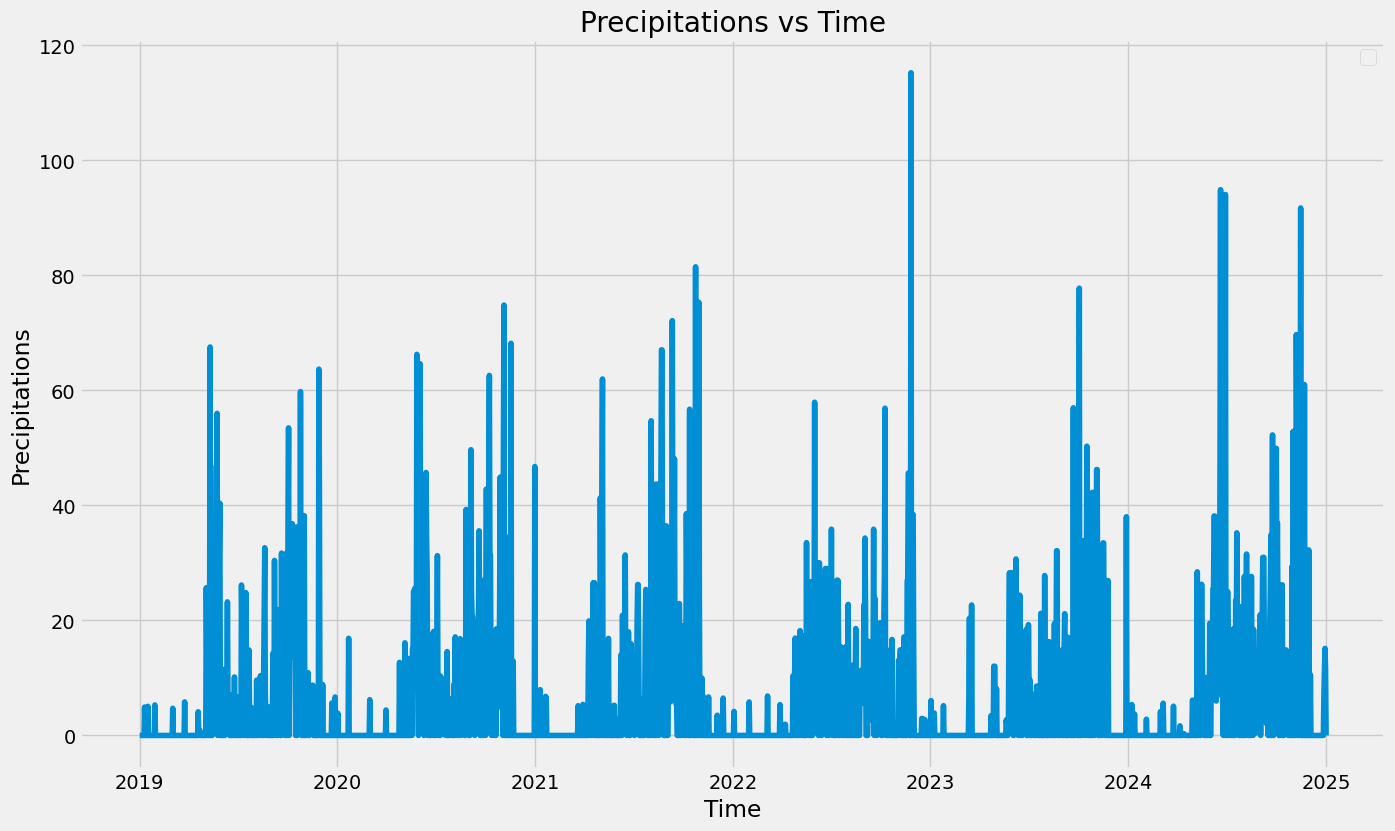

In [10]:
# Plot the precipitations around volcano
plt.figure(figsize=(15,9))
times = Rain2019_2024_df.index
precipitations = Rain2019_2024_df['Precipitations']
plt.plot(times, precipitations)
plt.title('Precipitations vs Time')
plt.xlabel('Time')
plt.ylabel('Precipitations')
plt.legend()
plt.show()

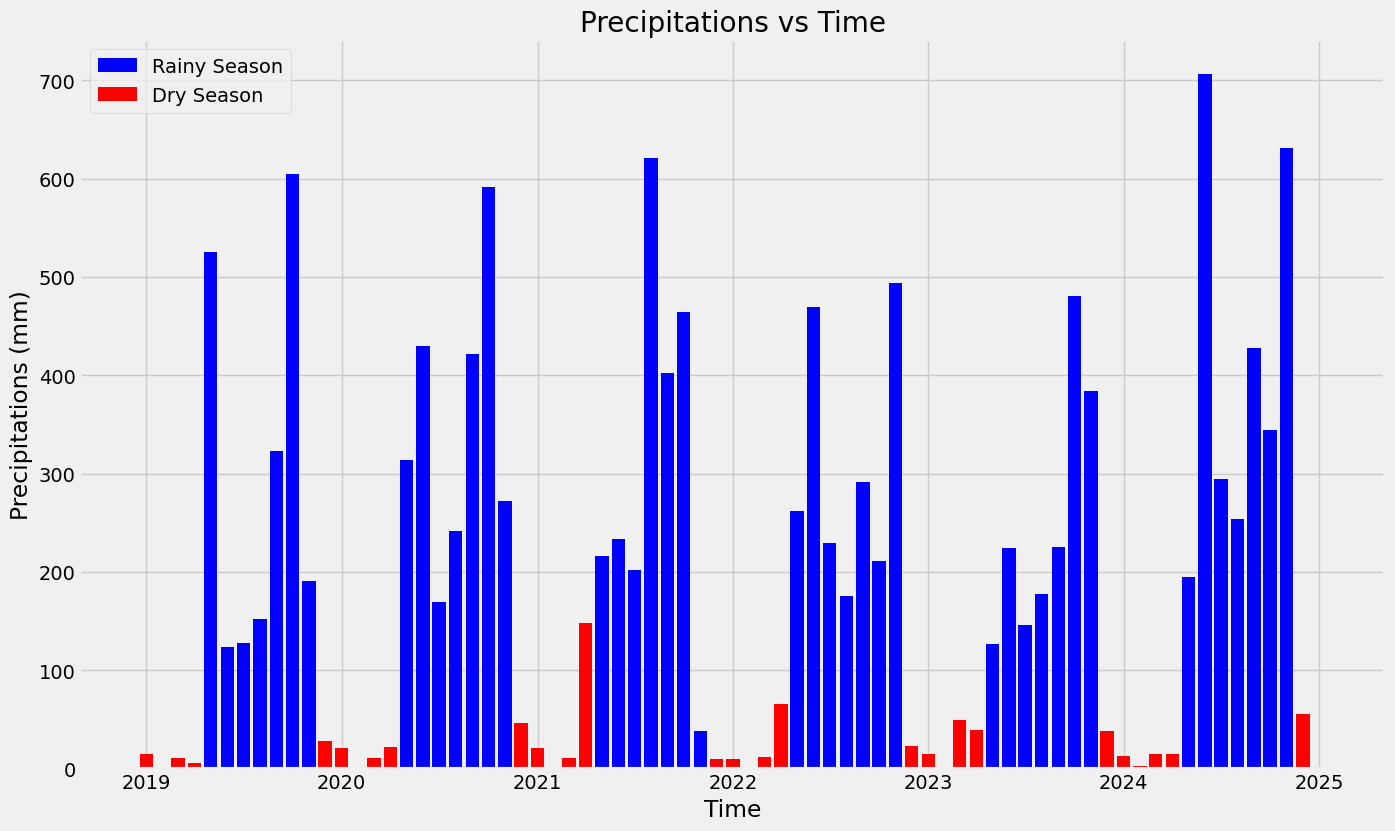

In [12]:
# Plot the precipitations distinguishing Dry and Rainy seasons
precipitations_per_month = Rain2019_2024_df.groupby(Rain2019_2024_df.index.to_period('M'))['Precipitations'].sum()
times = precipitations_per_month.index.to_timestamp()
values = precipitations_per_month.values

dry_season_months = [12, 1, 2, 3, 4]

is_dry = times.month.isin(dry_season_months)

dry_times = times[is_dry]
dry_values = values[is_dry]

rainy_times = times[~is_dry] 
rainy_values = values[~is_dry]

plt.figure(figsize=(15, 9))
plt.bar(rainy_times, rainy_values, color='blue', label='Rainy Season', width=25)
plt.bar(dry_times, dry_values, color='red', label='Dry Season', width=25)
plt.title('Precipitations vs Time')
plt.xlabel('Time')
plt.ylabel('Precipitations (mm)')
plt.legend()
plt.show()

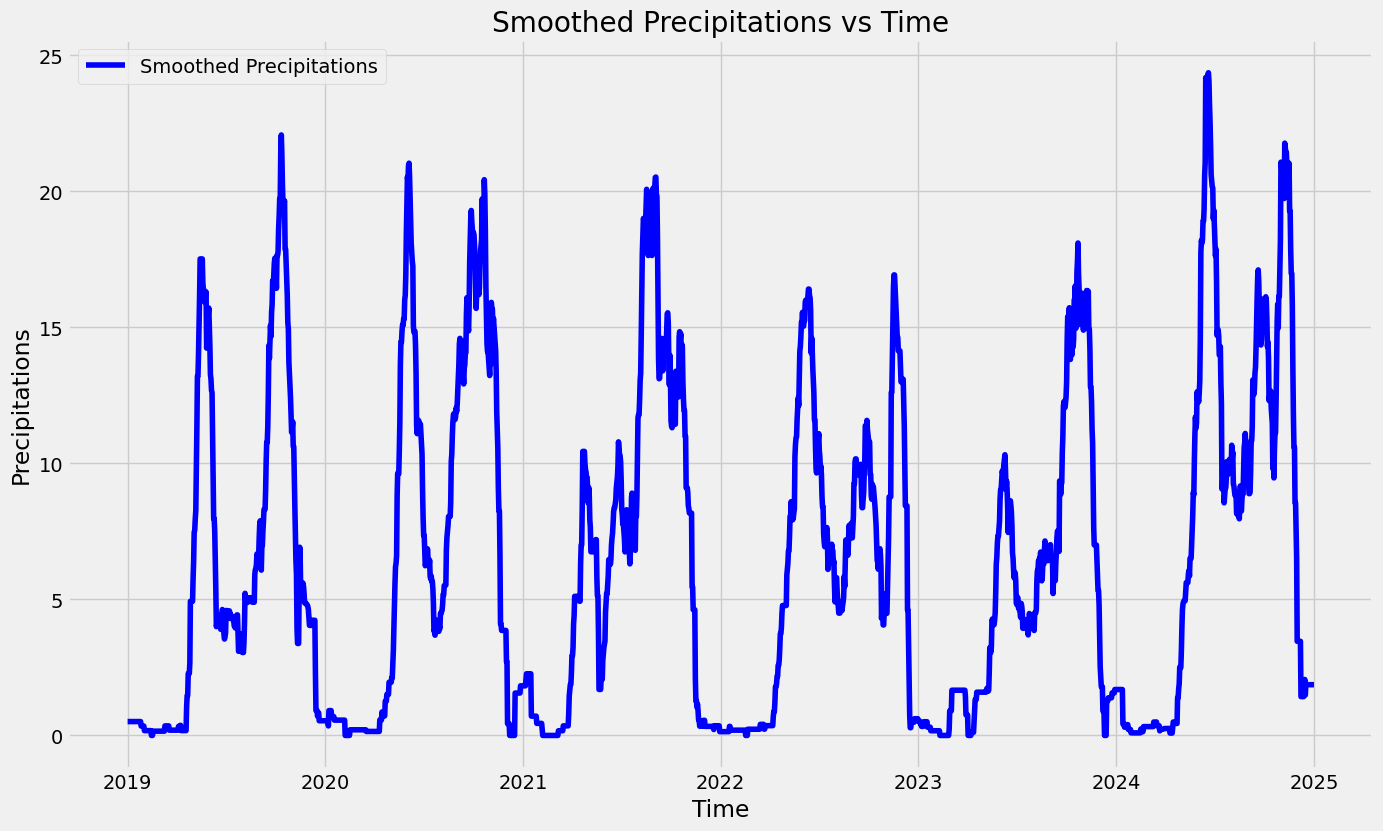

In [13]:
# Plot smoothened precipitations with a moving average

times = Rain2019_2024_df.index
precipitations_series = pd.Series(precipitations.values, index=times)
smoothed_precipitations = precipitations_series.rolling(window=30, center=True).mean()
smoothed_precipitations = smoothed_precipitations.bfill().ffill()
plt.figure(figsize=(15,9))
plt.plot(times, smoothed_precipitations, color='blue', label='Smoothed Precipitations')
plt.title('Smoothed Precipitations vs Time')
plt.xlabel('Time')
plt.ylabel('Precipitations')
plt.legend()
plt.show()


### Lahares Data

The different informations about the Lahares are added to the global dataset.
We have the following columns:
- Eruption time: Timestamp of the eruption that triggered the lahar.
- Lahar time: Timestamp of the lahar occurrence.
- Magnitude: Magnitude of the lahar event.

In [14]:
## Add Lahares to the VRBA DataFrame
print("\nLahares DataFrame:")
Lahares_df.info()

# Drop rows + Dates in the same format
Lahares_df = Lahares_df[Lahares_df['Eruption time'].dt.year >= 2019]
vrba_minutes = VRBA_eruptions_df["t1"].dt.floor('min')
lahar_minutes = Lahares_df["Eruption time"]

# Add new column to VRBA_eruptions_df to indicate if lahar occurred
VRBA_eruptions_df["Lahares"] = vrba_minutes.isin(lahar_minutes)

# Add new eruptions where Lahares occurred but not registered
lahares_dates_not_in_VRBA = lahar_minutes[~lahar_minutes.isin(vrba_minutes)]

mag_map = Lahares_df.set_index("Eruption time")["Eruption infrasound magnitude"]

new_rows = pd.DataFrame({
    "t1": lahares_dates_not_in_VRBA,
    "Lahares": True,
    "magnitude": lahares_dates_not_in_VRBA.map(mag_map).str.replace(',', '.').astype(float)
})

VRBA_eruptions_df = pd.concat(
    [VRBA_eruptions_df, new_rows],
    ignore_index=True
)

# Add the time difference before the lahar occurred

VRBA_eruptions_df = pd.merge_asof(
    VRBA_eruptions_df.sort_values('t1'),
    Lahares_df[['Eruption time', 'Time difference (min)']].sort_values('Eruption time'),
    left_on='t1',
    right_on='Eruption time',
    direction='backward',
    tolerance=pd.Timedelta('1Min')
).rename(
    columns={'Time difference (min)': 'Time before Lahar (min)'}
).drop(columns=['Eruption time'])

print(VRBA_eruptions_df[VRBA_eruptions_df["Lahares"] == True])



Lahares DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 5 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   Event                          22 non-null     int64         
 1   Eruption time                  22 non-null     datetime64[ns]
 2   Lahar time                     15 non-null     datetime64[ns]
 3   Time difference (min)          15 non-null     float64       
 4   Eruption infrasound magnitude  15 non-null     object        
dtypes: datetime64[ns](2), float64(1), int64(1), object(1)
memory usage: 1012.0+ bytes
                         t1                      t2  amplitude_max  \
0   2019-01-20 07:27:05.050 2019-01-20 07:29:11.950          5.916   
37  2020-01-30 18:13:42.427 2020-01-30 18:14:33.666          5.284   
94  2020-05-25 09:25:52.157 2020-05-25 09:26:35.065          2.599   
208 2021-06-28 11:42:04.132 2021-06-28 11:

### Eruptions Data 

Let's see how the information of the different eruption events are distributed over time.

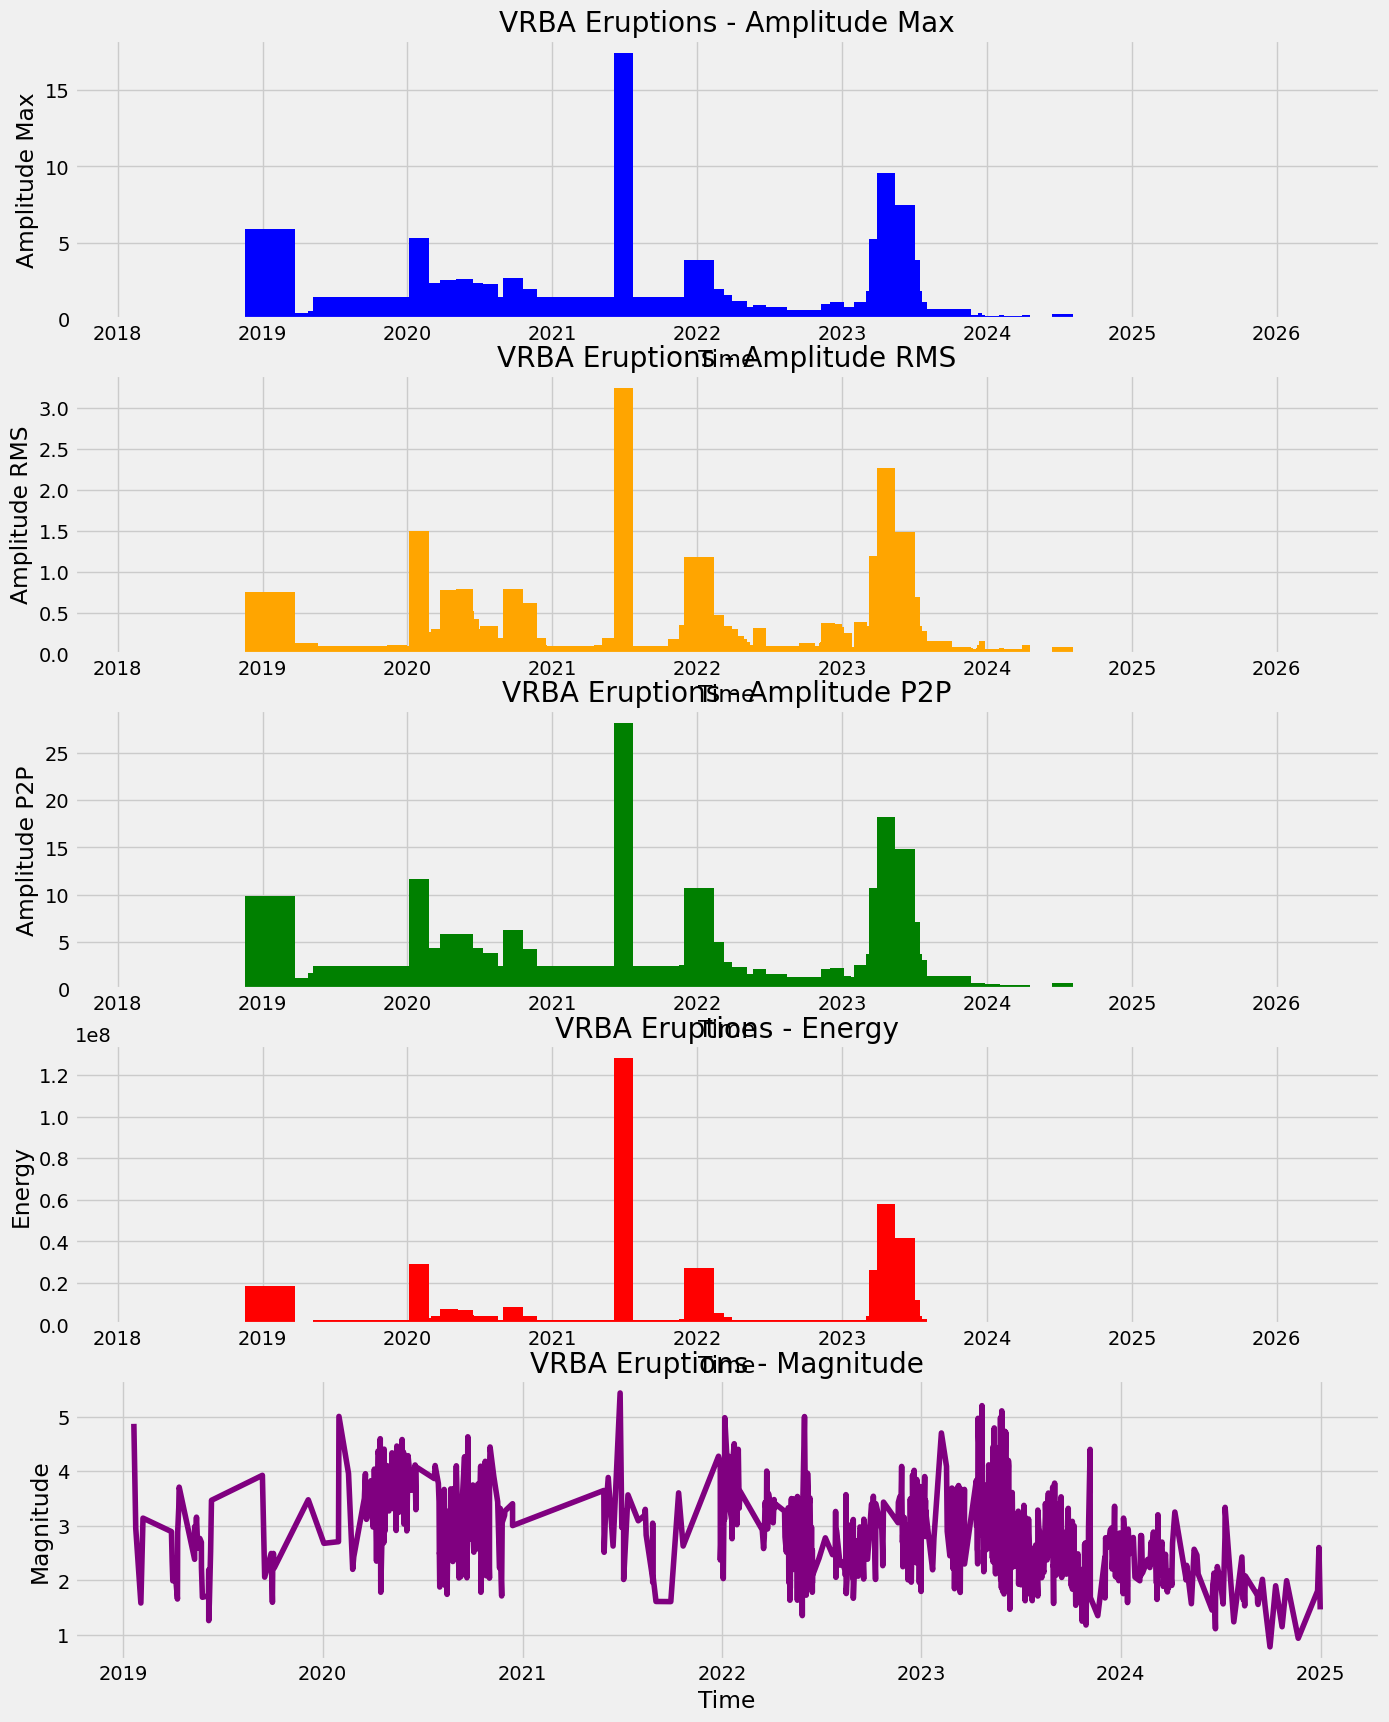

In [15]:
## Plot VRBA eruptions data

# The data is not in right order. We will sort it by t1, the start time of the eruption
VRBA_eruptions_df = VRBA_eruptions_df.sort_values(by='t1')
# Add new columns showing the duration of the eruption
VRBA_eruptions_df['duration'] = (VRBA_eruptions_df['t2'] - VRBA_eruptions_df['t1']).dt.total_seconds() # Duration in seconds


# Plot a bar graph of the VRBA eruptions
plt.figure(figsize=(15, 20))
plt.subplot(5, 1, 1)
plt.bar(VRBA_eruptions_df['t1'], VRBA_eruptions_df['amplitude_max'], width=VRBA_eruptions_df['duration'], color='blue')
plt.title('VRBA Eruptions - Amplitude Max')
plt.xlabel('Time')
plt.ylabel('Amplitude Max')
plt.subplot(5, 1, 2)
plt.bar(VRBA_eruptions_df['t1'], VRBA_eruptions_df['amplitude_rms'], width=VRBA_eruptions_df['duration'], color='orange')
plt.title('VRBA Eruptions - Amplitude RMS')
plt.xlabel('Time')
plt.ylabel('Amplitude RMS')
plt.subplot(5, 1, 3)
plt.bar(VRBA_eruptions_df['t1'], VRBA_eruptions_df['amplitude_p2p'], width=VRBA_eruptions_df['duration'], color='green')
plt.title('VRBA Eruptions - Amplitude P2P')
plt.xlabel('Time')
plt.ylabel('Amplitude P2P')
plt.subplot(5, 1, 4)
plt.bar(VRBA_eruptions_df['t1'], VRBA_eruptions_df['energy'], width=VRBA_eruptions_df['duration'], color='red')
plt.title('VRBA Eruptions - Energy')
plt.xlabel('Time')
plt.ylabel('Energy')
plt.subplot(5, 1, 5)
plt.plot(VRBA_eruptions_df['t1'], VRBA_eruptions_df['magnitude'], color='purple')
plt.title('VRBA Eruptions - Magnitude')
plt.xlabel('Time')
plt.ylabel('Magnitude')
plt.show()

Besides the magnitude, we can see that they follow a similar pattern. It could mean there is high correlation between them.

### Continuous Measurements Data

Let's see how the Rincon de la Vieja and Rincon data is distributed over time.

####  Accoustic Data

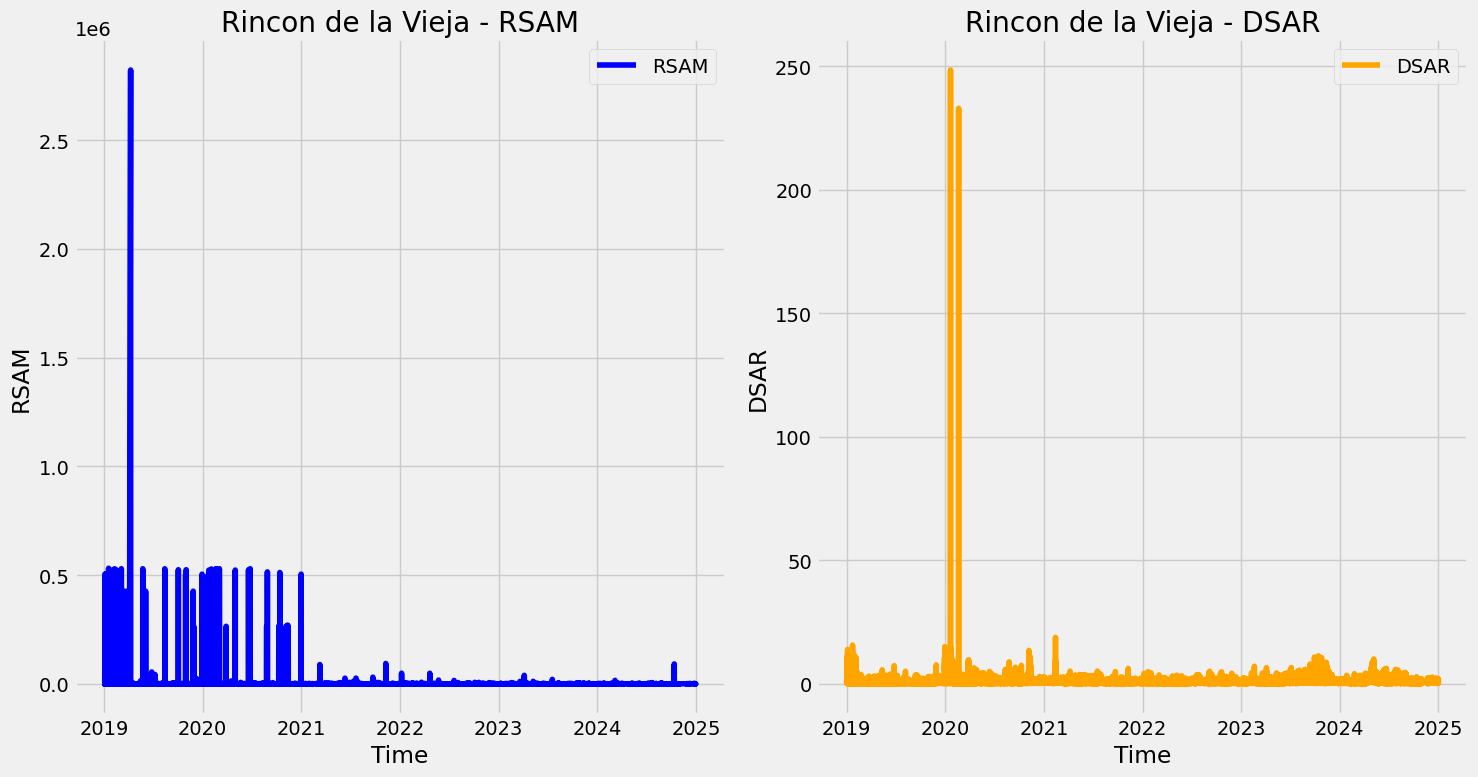

In [16]:
## Plot data
# [dsar , rsam, trigger  freq_bands_mean    freq_top_k    freq_index spectral_kurtosis      tonality]
plt.figure(figsize=(15, 8))
plt.subplot(1, 2, 1)
plt.plot(Rincon_de_la_Vieja_df.index, Rincon_de_la_Vieja_df['rsam'], label='RSAM', color='blue')
plt.title('Rincon de la Vieja - RSAM')
plt.xlabel('Time')
plt.ylabel('RSAM')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(Rincon_de_la_Vieja_df.index, Rincon_de_la_Vieja_df['dsar'], label='DSAR', color='orange')
plt.title('Rincon de la Vieja - DSAR')
plt.xlabel('Time')
plt.ylabel('DSAR')
plt.legend()
plt.tight_layout()
plt.show()

We see some outliers and some missing values in the data. For the Rsam value, we will apply a trheshod to get rid of the outliers and the noise in the data. 

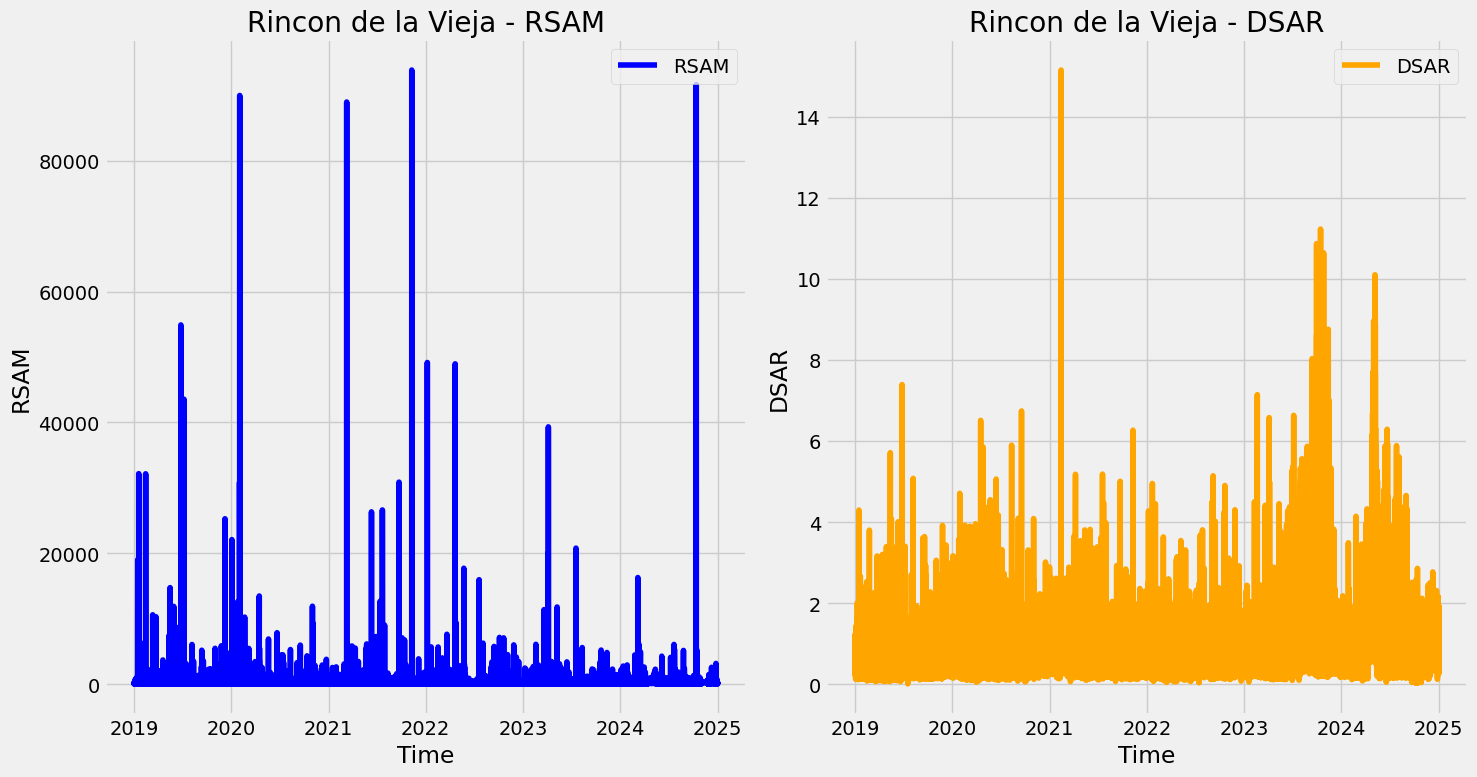

In [18]:
## Plot data with RSAM between 20 and 1e5

Rincon_de_la_Vieja_df = Rincon_de_la_Vieja_df[(20 < Rincon_de_la_Vieja_df['rsam']) & (Rincon_de_la_Vieja_df['rsam'] < 1e5)]

plt.figure(figsize=(15, 8))
plt.subplot(1, 2, 1)
plt.plot(Rincon_de_la_Vieja_df.index, Rincon_de_la_Vieja_df['rsam'], label='RSAM', color='blue')
plt.title('Rincon de la Vieja - RSAM')
plt.xlabel('Time')
plt.ylabel('RSAM')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(Rincon_de_la_Vieja_df.index, Rincon_de_la_Vieja_df['dsar'], label='DSAR', color='orange')
plt.title('Rincon de la Vieja - DSAR')
plt.xlabel('Time')
plt.ylabel('DSAR')
plt.legend()
plt.tight_layout()
plt.show()


We are going to see how much data is missing in the Rincon de la Vieja continuous dataframe.

In [19]:
## Assessing missing data in Rincon de la Vieja continuous dataset

# Store the first and last time of data being recorded
Rincon_first_time = Rincon_de_la_Vieja_df.index.min()
Rincon_last_time = Rincon_de_la_Vieja_df.index.max() 
print(f"\nRincon de la Vieja data recorded from {Rincon_first_time} to {Rincon_last_time}")
# Compute the difference between the two timestamps
difference = (Rincon_last_time - Rincon_first_time).total_seconds() # Duration in seconds
# Convert seconds to minutes
duration_minutes = difference / 60
print(f" Supposed total duration of Rincon de la Vieja data: {duration_minutes} minutes")
# Calculate the actual number of data points recorded
actual_data_points = Rincon_de_la_Vieja_df.shape[0]
print(f" Actual number of data points recorded: {actual_data_points}")# Calculate the expected number of data points for continuous recording every minute
# Compute the number of missing data points
expected_data_points = duration_minutes + 1  # Including both endpoints
missing_data_points = expected_data_points - actual_data_points
print(f" Missing data points: {missing_data_points}")# Calculate the percentage of missing data points
missing_percentage = (missing_data_points / expected_data_points) * 100
print(f" Percentage of missing data points: {missing_percentage:.2f}%")



Rincon de la Vieja data recorded from 2019-01-01 00:01:00 to 2025-01-01 00:00:00
 Supposed total duration of Rincon de la Vieja data: 3156479.0 minutes
 Actual number of data points recorded: 2323244
 Missing data points: 833236.0
 Percentage of missing data points: 26.40%


We see that 26.40% of the data is missing in the Rincon de la Vieja continuous dataframe. Let's see how the missing data points are spread over time.

In [ ]:
# # Take 14 minutes to compile  ---> see csv file below

# # Copy of the time column to analyze missing data
# time_df = Rincon_de_la_Vieja_df[['time']].copy()
# # Creation of a dictionary to store missing time intervals (as key) and their counts (as value)
# min_missing = {}
# # Iterate through the time DataFrame to identify missing data points and calculating the time difference
# for i in range(1, time_df.shape[0]):
#     current_time = time_df.iloc[i]
#     previous_time = time_df.iloc[i - 1]
#     time_diff = (current_time - previous_time).dt.total_seconds().values[0] / 60  # Convert to minutes
#     if time_diff > 1:
#         if time_diff not in min_missing:
#             min_missing[time_diff] = 0
#         min_missing[time_diff] += 1
# print("\nMissing time intervals (in minutes) and their counts:")
# for interval, count in sorted(min_missing.items()):
#     print(f" {interval} minutes: {count} occurrences")

# # Store dictionary keys and values in a csv file
# missing_intervals_df = pd.DataFrame(list(min_missing.items()), columns=['Missing Interval (minutes)', 'Count'])
# missing_intervals_df.to_csv("MSc_Bryan_Rincon/Rincon_missing_intervals.csv", index=False)

# print(sum(min_missing.values()))

Pas necessaire(We have a lot of gaps in the data. There are a lot of huge gaps where data is missing till at max 20 days. Those gaps are too big to be filled with interpolation. Specific treatment will be needed for those gaps. But for the smaller gaps, we can use interpolation to fill in the missing data points.)

In [ ]:
# # Filling the small gaps with interpolation

# Continuous_data_df = Rincon_de_la_Vieja_df.copy()
# # Identify gaps larger than 2 minutes
# Continuous_data_df['gap'] = Continuous_data_df['time'].diff() > pd.Timedelta(minutes=2)
# # Create a cumulative sum of the gaps to identify groups of continuous data
# Continuous_data_df['gap group'] = Continuous_data_df['gap'].cumsum()
# # Count the size of each gap group
# gap = Continuous_data_df['gap group'].value_counts().sort_index()
# print(f"Number of gap groups identified: {len(gap)}")
# # Identify correctable gaps
# correctable_gaps = gap[gap > 20]  # 20 minutes
# #print(correctable_gaps)
# print(f"Number of correctable gap groups (>{20} minutes): {len(correctable_gaps)}")


# # Continuous_data_df = Continuous_data_df.infer_objects()

# Continuous_group_data_df = Continuous_data_df[Continuous_data_df['gap group'].isin(correctable_gaps.index)]
# print(f"Data points in correctable gap groups: {Continuous_group_data_df.shape}")
# Continuous_group_data_df = Continuous_group_data_df.set_index('time')
# #print(Continuous_group_data_df.head())
# Continuous_group_data_df = Continuous_group_data_df.groupby('gap group', group_keys=False).apply(lambda g: g.asfreq('1min').interpolate())
# print(f"Data points after interpolation: {Continuous_group_data_df.shape}")
# Continuous_data_df = Continuous_data_df.set_index('time')
# df = Continuous_data_df.combine_first(Continuous_group_data_df)
# print(f"Total data points after filling small gaps: {df.shape}")
# print(f"Total data points before filling small gaps: {Continuous_data_df.shape}")

# print(df.describe())
# print(Rincon_de_la_Vieja_df.describe())


# # #Continuous_data_df = Continuous_data_df.reset_index(level=0, drop=True)
# # Continuous_data_df['time_diff'] = Continuous_data_df.index.diff()
# # print(Continuous_data_df['time_diff'].describe())



In [ ]:
# Continuous_data_df['time_diff'] = Continuous_data_df.index.diff()
# print(Continuous_data_df['time_diff'].describe())

In [ ]:
# Missing time intervals (in minutes) and their counts:
#  2.0 minutes: 148621 occurrences
#  3.0 minutes: 68946 occurrences
#  4.0 minutes: 33505 occurrences
#  5.0 minutes: 15593 occurrences
#  6.0 minutes: 7466 occurrences
#  7.0 minutes: 3834 occurrences
#  8.0 minutes: 1832 occurrences
#  9.0 minutes: 932 occurrences
#  10.0 minutes: 471 occurrences
#  11.0 minutes: 248 occurrences
#  12.0 minutes: 144 occurrences
#  13.0 minutes: 86 occurrences
#  14.0 minutes: 46 occurrences
#  15.0 minutes: 31 occurrences
#  16.0 minutes: 22 occurrences
#  17.0 minutes: 9 occurrences
#  18.0 minutes: 8 occurrences
#  19.0 minutes: 6 occurrences
#  20.0 minutes: 5 occurrences
#  21.0 minutes: 2 occurrences
#  22.0 minutes: 3 occurrences
#  23.0 minutes: 2 occurrences
#  24.0 minutes: 1 occurrences
#  25.0 minutes: 3 occurrences
#  26.0 minutes: 6 occurrences
#  27.0 minutes: 1 occurrences
#  28.0 minutes: 3 occurrences
#  29.0 minutes: 2 occurrences
#  30.0 minutes: 1 occurrences
#  31.0 minutes: 3 occurrences
#  32.0 minutes: 1 occurrences
#  33.0 minutes: 2 occurrences
#  35.0 minutes: 3 occurrences
#  37.0 minutes: 2 occurrences
#  38.0 minutes: 1 occurrences
#  39.0 minutes: 2 occurrences
#  40.0 minutes: 4 occurrences
#  41.0 minutes: 2 occurrences
#  42.0 minutes: 4 occurrences
#  43.0 minutes: 3 occurrences
#  44.0 minutes: 3 occurrences
#  46.0 minutes: 2 occurrences
#  47.0 minutes: 2 occurrences
#  48.0 minutes: 1 occurrences
#  49.0 minutes: 1 occurrences
#  50.0 minutes: 2 occurrences
#  51.0 minutes: 1 occurrences
#  52.0 minutes: 1 occurrences
#  53.0 minutes: 2 occurrences
#  55.0 minutes: 1 occurrences
#  56.0 minutes: 1 occurrences
#  57.0 minutes: 2 occurrences
#  58.0 minutes: 1 occurrences
#  60.0 minutes: 1 occurrences
#  61.0 minutes: 1 occurrences
#  63.0 minutes: 1 occurrences
#  65.0 minutes: 2 occurrences
#  67.0 minutes: 2 occurrences
#  70.0 minutes: 2 occurrences
#  71.0 minutes: 1 occurrences
#  79.0 minutes: 1 occurrences
#  80.0 minutes: 1 occurrences
#  82.0 minutes: 1 occurrences
#  84.0 minutes: 1 occurrences
#  86.0 minutes: 2 occurrences
#  87.0 minutes: 1 occurrences
#  89.0 minutes: 1 occurrences
#  92.0 minutes: 2 occurrences
#  93.0 minutes: 1 occurrences
#  95.0 minutes: 1 occurrences
#  96.0 minutes: 1 occurrences
#  101.0 minutes: 1 occurrences
#  103.0 minutes: 1 occurrences
#  106.0 minutes: 3 occurrences
#  107.0 minutes: 1 occurrences
#  108.0 minutes: 1 occurrences
#  109.0 minutes: 1 occurrences
#  111.0 minutes: 1 occurrences
#  114.0 minutes: 1 occurrences
#  117.0 minutes: 1 occurrences
#  125.0 minutes: 1 occurrences
#  126.0 minutes: 1 occurrences
#  132.0 minutes: 1 occurrences
#  137.0 minutes: 1 occurrences
#  138.0 minutes: 2 occurrences
#  141.0 minutes: 1 occurrences
#  142.0 minutes: 2 occurrences
#  145.0 minutes: 1 occurrences
#  148.0 minutes: 1 occurrences
#  153.0 minutes: 1 occurrences
#  156.0 minutes: 1 occurrences
#  159.0 minutes: 1 occurrences
#  163.0 minutes: 2 occurrences
#  170.0 minutes: 1 occurrences
#  173.0 minutes: 1 occurrences
#  175.0 minutes: 1 occurrences
#  176.0 minutes: 1 occurrences
#  186.0 minutes: 1 occurrences
#  187.0 minutes: 1 occurrences
#  190.0 minutes: 1 occurrences
#  192.0 minutes: 1 occurrences
#  199.0 minutes: 1 occurrences
#  211.0 minutes: 1 occurrences
#  213.0 minutes: 1 occurrences
#  217.0 minutes: 1 occurrences
#  218.0 minutes: 1 occurrences
#  229.0 minutes: 1 occurrences
#  238.0 minutes: 1 occurrences
#  239.0 minutes: 1 occurrences
#  247.0 minutes: 1 occurrences
#  249.0 minutes: 1 occurrences
#  265.0 minutes: 1 occurrences
#  266.0 minutes: 1 occurrences
#  275.0 minutes: 1 occurrences
#  276.0 minutes: 1 occurrences
#  283.0 minutes: 1 occurrences
#  285.0 minutes: 1 occurrences
#  290.0 minutes: 1 occurrences
#  296.0 minutes: 2 occurrences
#  301.0 minutes: 1 occurrences
#  304.0 minutes: 1 occurrences
#  322.0 minutes: 1 occurrences
#  324.0 minutes: 1 occurrences
#  331.0 minutes: 1 occurrences
#  333.0 minutes: 1 occurrences
#  337.0 minutes: 1 occurrences
#  338.0 minutes: 1 occurrences
#  339.0 minutes: 1 occurrences
#  343.0 minutes: 1 occurrences
#  346.0 minutes: 1 occurrences
#  356.0 minutes: 1 occurrences
#  358.0 minutes: 1 occurrences
#  370.0 minutes: 1 occurrences
#  381.0 minutes: 1 occurrences
#  384.0 minutes: 1 occurrences
#  390.0 minutes: 1 occurrences
#  392.0 minutes: 2 occurrences
#  410.0 minutes: 1 occurrences
#  440.0 minutes: 1 occurrences
#  450.0 minutes: 1 occurrences
#  454.0 minutes: 1 occurrences
#  459.0 minutes: 1 occurrences
#  461.0 minutes: 1 occurrences
#  518.0 minutes: 1 occurrences
#  574.0 minutes: 1 occurrences
#  584.0 minutes: 1 occurrences
#  592.0 minutes: 1 occurrences
#  625.0 minutes: 1 occurrences
#  626.0 minutes: 1 occurrences
#  635.0 minutes: 1 occurrences
#  636.0 minutes: 1 occurrences
#  644.0 minutes: 1 occurrences
#  659.0 minutes: 1 occurrences
#  760.0 minutes: 1 occurrences
#  788.0 minutes: 1 occurrences
#  812.0 minutes: 1 occurrences
#  827.0 minutes: 1 occurrences
#  837.0 minutes: 1 occurrences
#  847.0 minutes: 1 occurrences
#  864.0 minutes: 1 occurrences
#  935.0 minutes: 1 occurrences
#  1007.0 minutes: 1 occurrences
#  1012.0 minutes: 1 occurrences
#  1029.0 minutes: 1 occurrences
#  1053.0 minutes: 1 occurrences
#  1061.0 minutes: 1 occurrences
#  1212.0 minutes: 1 occurrences
#  1442.0 minutes: 2 occurrences
#  1796.0 minutes: 1 occurrences
#  2340.0 minutes: 1 occurrences
#  2575.0 minutes: 1 occurrences
#  2882.0 minutes: 1 occurrences
#  3404.0 minutes: 1 occurrences
#  4986.0 minutes: 1 occurrences
#  6122.0 minutes: 1 occurrences
#  6961.0 minutes: 1 occurrences
#  8813.0 minutes: 1 occurrences
#  28618.0 minutes: 1 occurrences

In [20]:
Rincon_df.columns

Index(['VT', 'LP', 'Tcorto', 'tornillo'], dtype='object')

#### Seismic and Geophysical Data

In [ ]:
# Rincon_df = Rincon_df.rename(columns={'Fecha':'time'})
# Rincon_df = Rincon_df[(Rincon_df['time'] >= pd.to_datetime('2019-01-01')) & (Rincon_df['time'] < pd.to_datetime('2025-01-01')) ]
# print("\nRincon DataFrame after filtering 2019-2024:")
# Rincon_df.info()

There is many features missing many values. I will take only features having at least 95% of data of the 2191 required (2024 - 2019 in days).

In [ ]:
## Keep only features having less than 5% missing data
# Rincon_df = Rincon_df[['time','VT', 'LP','Tcorto', 'tornillo']]
# Rincon_df.to_csv('MSc_Bryan_Rincon/Datasets/Rincon_2019_2024_filtered.csv', index=False)

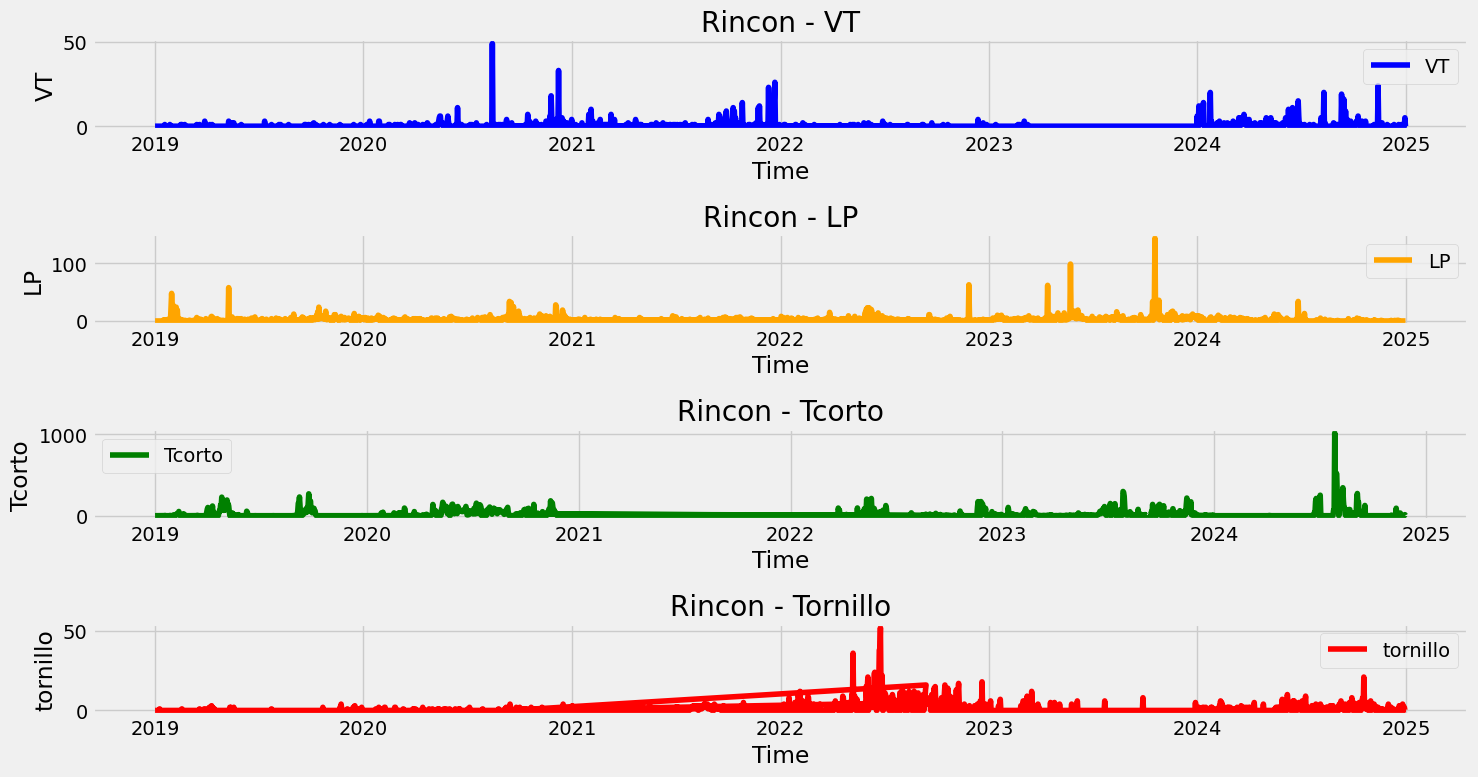

In [21]:
plt.figure(figsize=(15, 8))
plt.subplot(4, 1, 1)
plt.plot(Rincon_df.index, Rincon_df['VT'], label='VT', color='blue')
plt.title('Rincon - VT')
plt.xlabel('Time')
plt.ylabel('VT')
plt.legend()
plt.subplot(4, 1, 2)
plt.plot(Rincon_df.index, Rincon_df['LP'], label='LP', color='orange')
plt.title('Rincon - LP')
plt.xlabel('Time')
plt.ylabel('LP')
plt.legend()
plt.subplot(4, 1, 3)
plt.plot(Rincon_df.index, Rincon_df['Tcorto'], label='Tcorto', color='green')
plt.title('Rincon - Tcorto')
plt.xlabel('Time')
plt.ylabel('Tcorto')
plt.legend()
plt.subplot(4, 1, 4)
plt.plot(Rincon_df.index , Rincon_df['tornillo'], label='tornillo', color='red')
plt.title('Rincon - Tornillo')
plt.xlabel('Time')
plt.ylabel('tornillo')
plt.legend()
plt.tight_layout()
plt.show()

They doesnt seem to follow a specific pattern. There seems to be possible outliers . To handle them, I will apply a mean filtering technique to smooth the data and reduce their impact.

# Data preparation (features extraction,...)

## Datasets Merging

Lets connect the different datasets together to have a global dataset for the analysis. First, we start with the known eruption events. 

Because of the missing data in the Rincon continuous dataset, some eruptions will not have the exact corresponding continuous measurement; thus I will associate them with the closest previous available continuous data within a tolerance of 1 day.

In [22]:
## Connect VRBA eruptions with Rincon continuous data
# Rincon_de_la_Vieja_df = Rincon_de_la_Vieja_df.reset_index()
# merged_df = pd.merge_asof(VRBA_eruptions_df[['t1']].sort_values('t1'), Rincon_de_la_Vieja_df[['time']].sort_values('time'), left_on='t1', right_on='time', direction='backward', tolerance=pd.Timedelta('1d'))
# Rincon_de_la_Vieja_df = Rincon_de_la_Vieja_df.set_index('time')
# matched_time = merged_df[['t1', 'time']].copy()
# del merged_df
# matched_time['Gap before measurement (min)'] = ((matched_time['t1'] - matched_time['time']).dt.total_seconds() // 60).astype(int)
# matched_time['date'] = matched_time['t1'].dt.normalize()
# matched_time.to_csv("MSc_Bryan_Rincon/merged_Rincon.csv", index=False)


matched_time_path = "MSc_Bryan_Rincon/merged_Rincon.csv"
matched_time = pd.read_csv(matched_time_path)
matched_time[['t1', 'time', 'date']] = matched_time[['t1', 'time', 'date']].apply(pd.to_datetime, format='mixed')
print("\nMatched Time DataFrame:")
matched_time.info()



Matched Time DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 971 entries, 0 to 970
Data columns (total 4 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   t1                            971 non-null    datetime64[ns]
 1   time                          971 non-null    datetime64[ns]
 2   Gap before measurement (min)  971 non-null    int64         
 3   date                          971 non-null    datetime64[ns]
dtypes: datetime64[ns](3), int64(1)
memory usage: 30.5 KB


## Eruption data features extraction

### Energy Feature

Let's create a new feature in the VRBA eruptions dataframe that categorizes if the energy of the eruption is high or low based on a threshold value. We can use the mean energy of all eruptions as the threshold. 

In [23]:
LOW_ENERGY_THRESHOLD = np.percentile(VRBA_eruptions_df['energy'], 50)
MEDIUM_ENERGY_THRESHOLD = np.percentile(VRBA_eruptions_df['energy'], 90)
HIGH_ENERGY_THRESHOLD = np.percentile(VRBA_eruptions_df['energy'], 96)

# print(f"Low Energy Threshold: {LOW_ENERGY_THRESHOLD}")
# print(f"Medium Energy Threshold: {MEDIUM_ENERGY_THRESHOLD}")
# print(f"High Energy Threshold: {HIGH_ENERGY_THRESHOLD}")

def categorize_energy(energy):
    if energy < LOW_ENERGY_THRESHOLD:
        return 'Low'
    elif energy < MEDIUM_ENERGY_THRESHOLD:
        return 'Medium'
    elif energy < HIGH_ENERGY_THRESHOLD:
        return 'High'
    else:
        return 'Very High'

VRBA_eruptions_df['duration'] = (VRBA_eruptions_df['t2'] - VRBA_eruptions_df['t1']).dt.total_seconds() / 60  # Duration in minutes  

VRBA_with_energy_category_df = VRBA_eruptions_df.copy()

VRBA_with_energy_category_df['energy_category'] = VRBA_with_energy_category_df['energy'].apply(categorize_energy)

In [24]:
##
# VRBA_with_energy_category_df = VRBA_eruptions_df.copy()
# low = VRBA_with_energy_category_df['energy'].quantile(0.5)
# medium = VRBA_with_energy_category_df['energy'].quantile(0.75)
# high = VRBA_with_energy_category_df['energy'].quantile(0.96)
# VRBA_with_energy_category_df['energy_category'] = pd.cut( 
#     VRBA_with_energy_category_df['energy'], bins=[-float('inf'), low, medium, high, float('inf')], labels=['Low', 'Medium', 'High', 'Very High'])

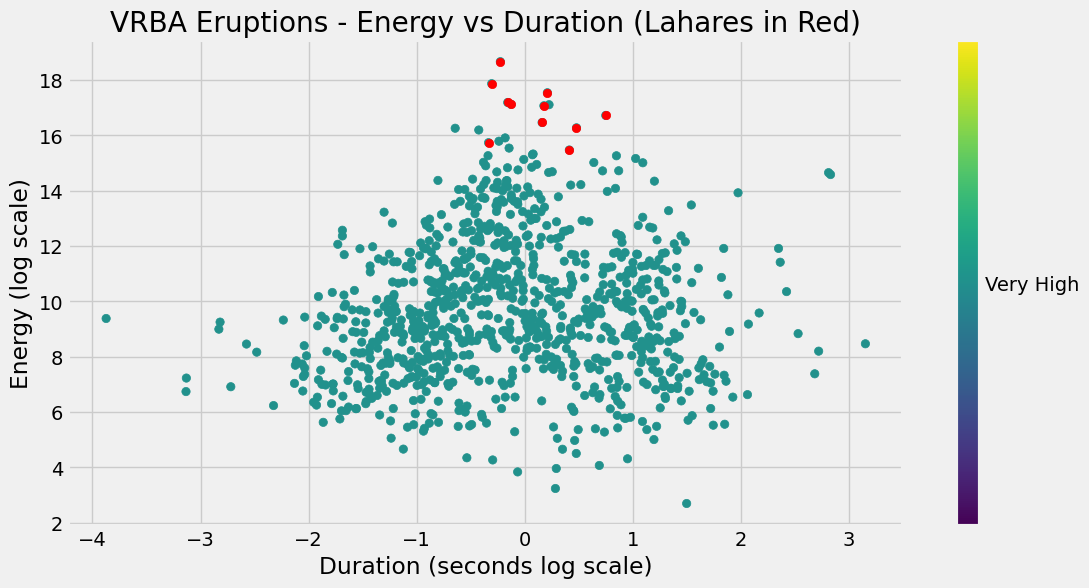

In [25]:
## Plot energy vs duration with lahar points highlighted

# Map text categories to numbers
category_map = {'Low': 0, 'Medium': 1, 'High': 2, 'Very High': 3}
color_values = VRBA_with_energy_category_df['energy_category'].map(category_map)

# Scatter plot
plt.figure(figsize=(12, 6))
scatter = plt.scatter(
    np.log(VRBA_with_energy_category_df['duration']),
    np.log(VRBA_with_energy_category_df['energy']),
    c=color_values,
    cmap='viridis'
)

# Overlay red points where potential_lahar == True
lahar_df = VRBA_with_energy_category_df[VRBA_with_energy_category_df["Lahares"] == True]
plt.scatter(
    np.log(lahar_df['duration']),
    np.log(lahar_df['energy']),
    color='red',
    label='Potential Lahar'
)

# Add colorbar with labels
cbar = plt.colorbar(scatter, ticks=[0, 1, 2, 3])
cbar.ax.set_yticklabels(['Low', 'Medium', 'High', 'Very High'])

plt.title('VRBA Eruptions - Energy vs Duration (Lahares in Red)')
plt.xlabel('Duration (seconds log scale)')
plt.ylabel('Energy (log scale)')
plt.show()


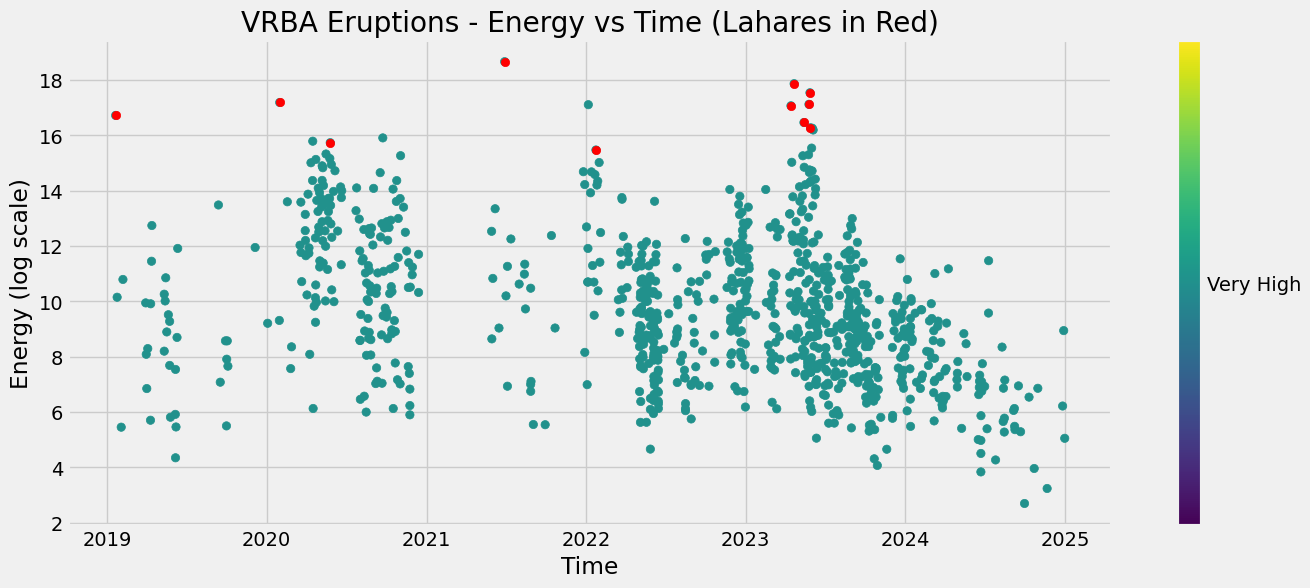

In [26]:
## Plot energy vs time with lahar points highlighted

# Map text categories to numbers
category_map = {'Low': 0, 'Medium': 1, 'High': 2, 'Very High': 3}
color_values = VRBA_with_energy_category_df['energy_category'].map(category_map)

# Scatter plot
plt.figure(figsize=(15, 6))
scatter = plt.scatter(
    VRBA_with_energy_category_df['t1'],
    np.log(VRBA_with_energy_category_df['energy']),
    c=color_values,
    cmap='viridis'
)

# Overlay red points where Lahares == True
lahar_df = VRBA_with_energy_category_df[VRBA_with_energy_category_df["Lahares"] == True]
plt.scatter(
    lahar_df['t1'],
    np.log(lahar_df['energy']),
    color='red',
    label='Potential Lahar'
)

# Add colorbar with labels
cbar = plt.colorbar(scatter, ticks=[0, 1, 2, 3])
cbar.ax.set_yticklabels(['Low', 'Medium', 'High', 'Very High'])

plt.title('VRBA Eruptions - Energy vs Time (Lahares in Red)')
plt.xlabel('Time')
plt.ylabel('Energy (log scale)')
plt.show()


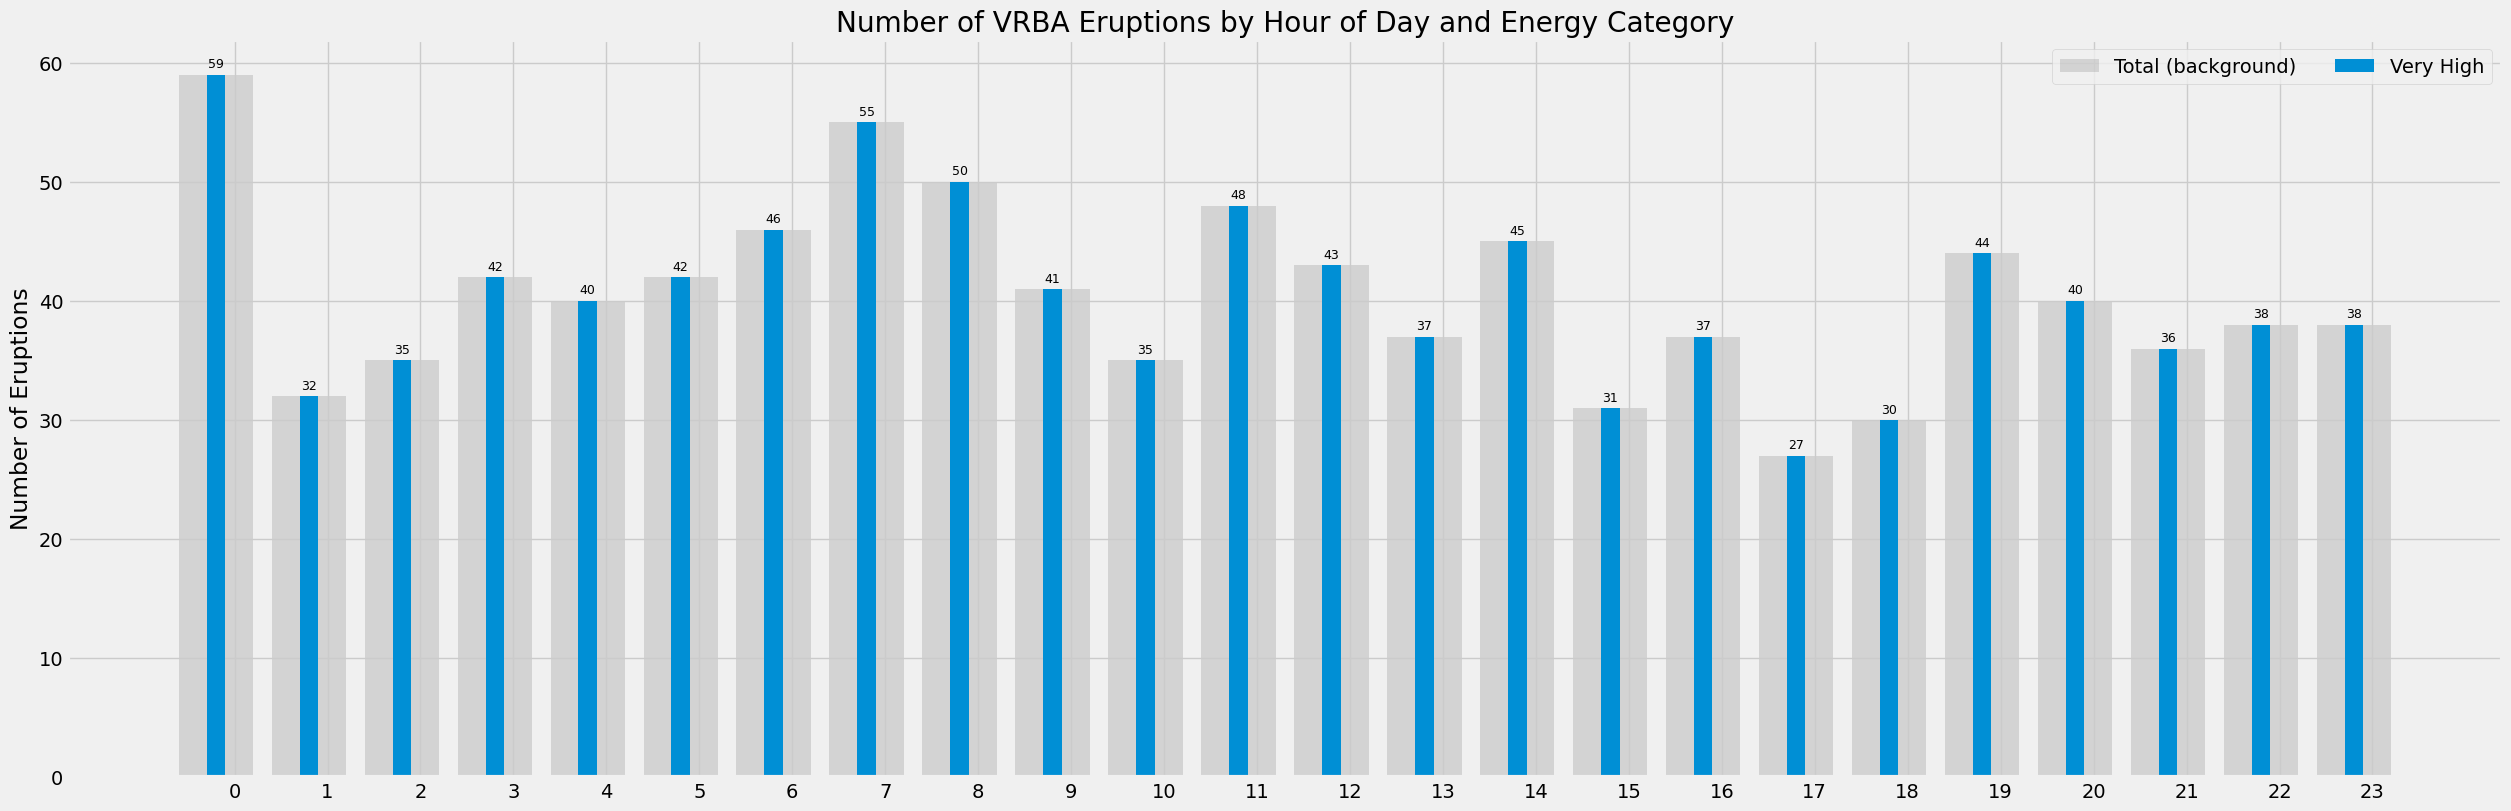

In [27]:
# Plot the the number of eruptions per category of energy in function of the time of the day (hour) VOIR SI A GARDER
energy_categories = {}
for energy in VRBA_with_energy_category_df['energy_category'].unique():
    counts = (
            VRBA_with_energy_category_df[VRBA_with_energy_category_df['energy_category'] == energy]['t1']
            .dt.hour.value_counts()
            .sort_index()
        )
    # S'assurer que toutes les heures (0-23) sont présentes
    counts = counts.reindex(np.arange(24), fill_value=0)
    energy_categories[energy] = counts

total_counts = sum(energy_categories.values())

# Plot the the number of eruptions per category of energy in function of the time of the day (hour)
hours = list(range(24))
x = np.arange(len(hours))
width = 0.2  # the width of the bars
multiplier = 0

fig, ax = plt.subplots(layout='constrained', figsize=(25, 8))

ax.bar(
    x,
    total_counts,
    width=0.8,
    color='gray',
    alpha=0.25,  # transparence
    label='Total (background)',
    zorder=0     # bien en arrière-plan
)

for energy, counts in energy_categories.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, counts, width, label=energy)
    ax.bar_label(rects, padding=3, fontsize=9)
    multiplier += 1

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Number of Eruptions')
ax.set_title('Number of VRBA Eruptions by Hour of Day and Energy Category')
ax.set_xticks(x + width, hours)
ax.legend(loc='upper right', ncols=2)
ax.autoscale_view()
plt.show()


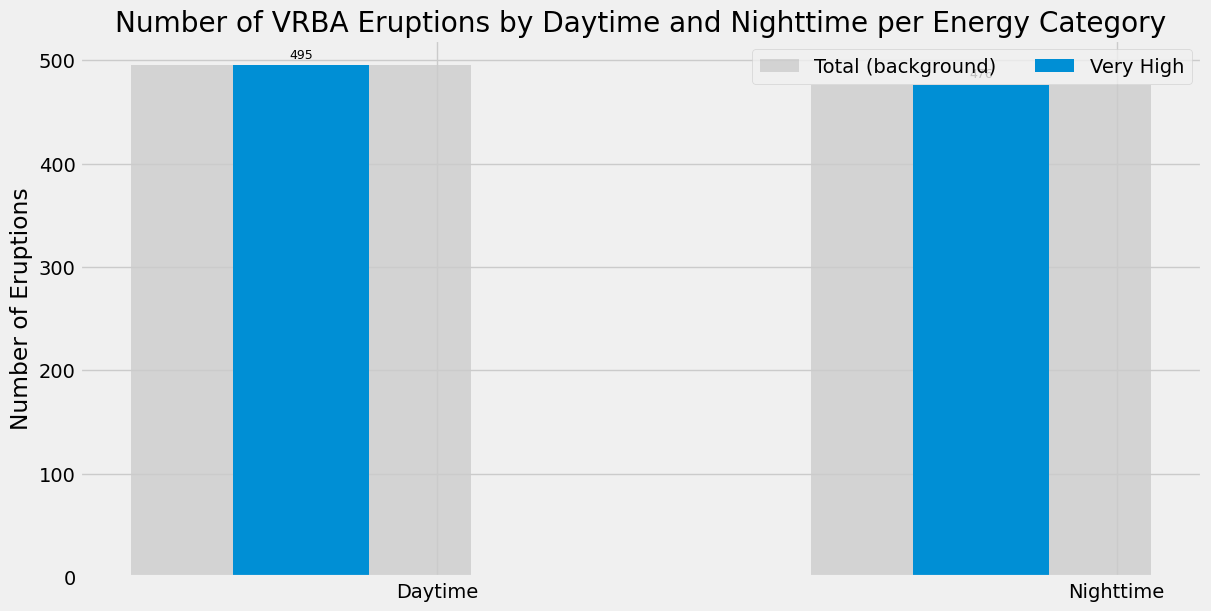

In [28]:
# Lets separate the day into night and daytime
energy_categories = {}
for energy in VRBA_with_energy_category_df['energy_category'].unique():
    energy_categories[energy] = {'daytime': [], 'nighttime': []}
    for hour, count in VRBA_with_energy_category_df[VRBA_with_energy_category_df['energy_category'] == energy]['t1'].dt.hour.value_counts().items():
        if 5.75 <= hour < 17.75:
            energy_categories[energy]['daytime'].append(count)
        else:
            energy_categories[energy]['nighttime'].append(count)

total_daytime = sum(sum(c['daytime']) for c in energy_categories.values())
total_nighttime = sum(sum(c['nighttime']) for c in energy_categories.values())
total_counts = [total_daytime, total_nighttime]

# Plot the number of eruptions during daytime and nighttime per energy category
labels = ['Daytime', 'Nighttime']
x = np.arange(len(labels))
width = 0.2  # the width of the bars
multiplier = 0
fig, ax = plt.subplots(layout='constrained', figsize=(12, 6))

ax.bar(
    x,
    total_counts,
    width=0.5,
    color='gray',
    alpha=0.25,  # transparence
    label='Total (background)',
    zorder=0     # bien en arrière-plan
)

for energy, counts in energy_categories.items():
    offset = width * multiplier
    values = [sum(counts['daytime']), sum(counts['nighttime'])]
    rects = ax.bar(x + offset, values, width, label=energy)
    ax.bar_label(rects, padding=3, fontsize=9)
    multiplier += 1
# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Number of Eruptions')
ax.set_title('Number of VRBA Eruptions by Daytime and Nighttime per Energy Category')
ax.set_xticks(x + width, labels)
ax.legend(loc='upper right', ncols=2)
ax.autoscale_view()
plt.show()


In [29]:
# ## Plot the the number of eruptions per category of energy vs season
# energy_categories = {}
# for energy in VRBA_with_energy_category_df['energy_category'].unique():
#     energy_categories[energy] = VRBA_with_energy_category_df[VRBA_with_energy_category_df['energy_category'] == energy]['season'].value_counts()
# # Plot the results
# seasons = ['Rainy','Dry' ]
# x = np.arange(len(seasons))
# width = 0.2  # the width of the bars
# multiplier = 0
# plt.style.use('default')
# fig, ax = plt.subplots(layout='constrained')

# for energy, counts in energy_categories.items():
#     offset = width * multiplier
#     rects = ax.bar(x + offset, counts, width, label=energy)
#     ax.bar_label(rects, padding=3, fontsize=9)
#     multiplier += 1

# # Add some text for labels, title and custom x-axis tick labels, etc.
# ax.set_ylabel('Number of Eruptions')
# ax.set_title('Number of VRBA Eruptions by Season and Energy Category')
# ax.set_xticks(x + width, seasons)
# ax.legend(loc='upper right', ncols=2)
# ax.autoscale_view()
# plt.show()


### Temporal Features

We can use the seasons in costa rica to categorize the eruptions in VRBA. The dry season is from December to April and the wet season is from May to November. We can create a new column in the VRBA eruptions dataframe that will tell us if the eruption happened in the dry or wet season.
https://costa-rica-guide.com/travel/weather/seasons-in-costa-rica/
Evenmore, we can extract the month and time of the day  of each eruption as new features.

In [30]:
def add_temporal_features(df):
    # 0 = Dry Season (Dec–Apr), 1 = Rainy Season (May–Nov)
    dry_months = {12, 1, 2, 3, 4}
    df = df.copy()
    df['season'] = np.where(df['t1'].dt.month.isin(dry_months), 0, 1).astype(int)

    # month feature
    df['month'] = df['t1'].dt.month
    # Cyclical month feature
    df['month norm'] = np.sin((df['t1'].dt.month - 1) * (2 * np.pi / 12))

    # time-of-day feature
    df['Time of the Day'] = df['t1'].dt.hour + df['t1'].dt.minute / 60
    # Cyclical time-of-day feature
    tod = df['t1'].dt.hour + df['t1'].dt.minute / 60
    df['Time of the Day norm'] = np.sin(tod * (2 * np.pi / 24))
    return df

# Apply to VRBA_eruptions_df and keep season synced
VRBA_eruptions_df = add_temporal_features(VRBA_eruptions_df)
VRBA_eruptions_df.info()
VRBA_with_energy_category_df['season'] = VRBA_eruptions_df['season'].values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 971 entries, 0 to 970
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   t1                       971 non-null    datetime64[ns]
 1   t2                       967 non-null    datetime64[ns]
 2   amplitude_max            967 non-null    float64       
 3   amplitude_rms            967 non-null    float64       
 4   amplitude_p2p            967 non-null    float64       
 5   energy                   967 non-null    float64       
 6   duration                 967 non-null    float64       
 7   magnitude                971 non-null    float64       
 8   Lahares                  971 non-null    bool          
 9   Time before Lahar (min)  15 non-null     float64       
 10  season                   971 non-null    int64         
 11  month                    971 non-null    int32         
 12  month norm               971 non-nul

### Analysis New features

Here, as we known that the energy, amplitude rms, amplitude max, amplitude p2p, duration and magnitude are computed after the eruption occured, these features cannot be used for prediction. Thus, we will analyze the correlation of the new features (season, month, time of the day) with the laahres to see if they can be useful for prediction. But they will be used as target variables for classification models.

In [31]:
# Prepare final DataFrames for features and target

# VRBA_all_features_df = VRBA_eruptions_scaled[['season', 'month', 'Time of the Day']].copy()
# VRBA_all_features_df.info()

# VRBA_target_df = VRBA_eruptions_scaled[['Lahares','duration','amplitude_max', 'amplitude_rms', 'amplitude_p2p', 'energy']].copy()
# VRBA_target_df.info()

# VRBA_eruptions_df.info()

DataFrame Head:


,amplitude_max,amplitude_rms,amplitude_p2p,energy,Lahares,season,month,Time of the Day,magnitude,duration
0,5.916,0.754,9.851,1.835937e+07,1,0,1,7.450000,4.866785,2.115000
1,0.146,0.052,0.299,2.566531e+04,0,0,1,18.500000,2.954262,0.630000
2,0.024,0.007,0.052,2.339980e+02,0,0,2,3.066667,1.587372,0.337733


DataFrame Tail:


,amplitude_max,amplitude_rms,amplitude_p2p,energy,Lahares,season,month,Time of the Day,magnitude,duration
968,0.047,0.007,0.082,502.734,0,0,12,7.516667,1.809897,0.585633
969,0.079,0.025,0.144,7680.762,0,0,12,19.233333,2.603221,0.828717
970,0.012,0.003,0.020,156.490,0,0,12,3.083333,1.470306,1.351000


----------------------------------------------------------------------------------------------------
Missing values:


,0
amplitude_max,4
amplitude_rms,4
amplitude_p2p,4
energy,4
duration,4


----------------------------------------------------------------------------------------------------
MSNO Matrix:



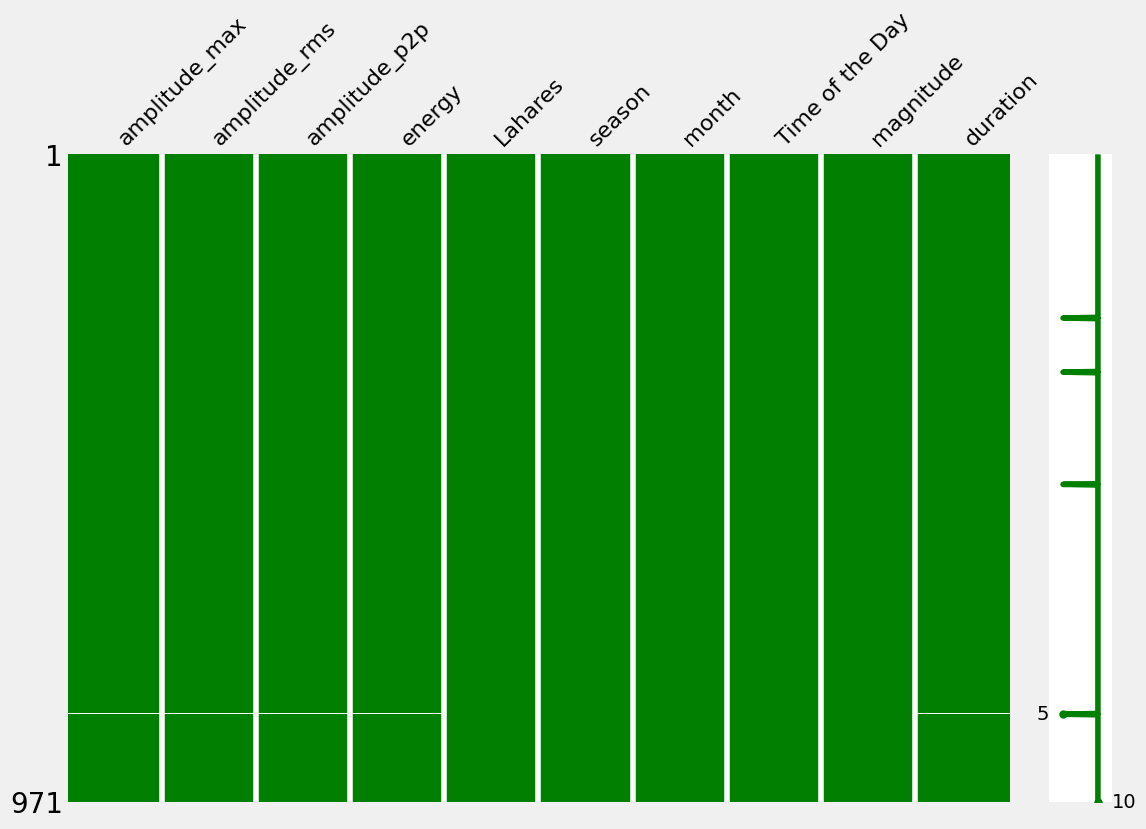

----------------------------------------------------------------------------------------------------
Shape of DataFrame:

(971, 10)

----------------------------------------------------------------------------------------------------
DataFrame Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 971 entries, 0 to 970
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   amplitude_max    967 non-null    float64
 1   amplitude_rms    967 non-null    float64
 2   amplitude_p2p    967 non-null    float64
 3   energy           967 non-null    float64
 4   Lahares          971 non-null    int64  
 5   season           971 non-null    int64  
 6   month            971 non-null    int32  
 7   Time of the Day  971 non-null    float64
 8   magnitude        971 non-null    float64
 9   duration         967 non-null    float64
dtypes: float64(7), int32(1), int64(2)
memory usage: 72.2 KB
-------------------------------

c:\Users\bryan\anaconda3\envs\MASTER_THESIS\Lib\site-packages\fasteda\__init__.py:86: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  full_info.iloc[:,:-2] = full_info.iloc[:,:-2].applymap(lambda x: format(x, '.3f') \
c:\Users\bryan\anaconda3\envs\MASTER_THESIS\Lib\site-packages\fasteda\__init__.py:86: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'amplitude_max      967
amplitude_rms      967
amplitude_p2p      967
energy             967
Lahares            971
season             971
month              971
Time of the Day    971
magnitude          971
duration           967
Name: count, dtype: object' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  full_info.iloc[:,:-2] = full_info.iloc[:,:-2].applymap(lambda x: format(x, '.3f') \
c:\Users\bryan\anaconda3\envs\MASTER_THESIS\Lib\site-packages\fasteda\__init__.py:86: FutureWarning: Setting 

,count,mean,median,std,min,25%,50%,75%,max,skewness,kurtosis
amplitude_max,967,0.309,0.103,0.868,0.003,0.05,0.103,0.247,17.436,11.223428,179.731518
amplitude_rms,967,0.087,0.032,0.195,0,0.015,0.032,0.082,3.242,8.117839,96.893082
amplitude_p2p,967,0.649,0.225,1.646,0.005,0.107,0.225,0.512,28.126,8.732068,107.659237
energy,967,625937.744,12181.763,5145144.809,14.828,2547.747,12181.763,80816.182,128067632.63,18.378450,410.436634
Lahares,971,0.015,0,0.123,0,0,0,0,1,9.215237,82.920597
season,971,0.685,1,0.465,0,0,1,1,1,-0.799652,-1.360557
month,971,6.667,6,3.045,1,5,6,9,12,0.054306,-0.806772
Time of the Day,971,11.515,11.2,6.916,0,5.742,11.2,17.458,23.967,0.116779,-1.138117
magnitude,971,2.824,2.743,0.744,0.785,2.284,2.743,3.294,5.432,0.430255,0.037455
duration,967,1.475,0.819,1.894,0.021,0.421,0.819,1.958,23.369,4.567969,34.180211


----------------------------------------------------------------------------------------------------
DataFrame Correlation:



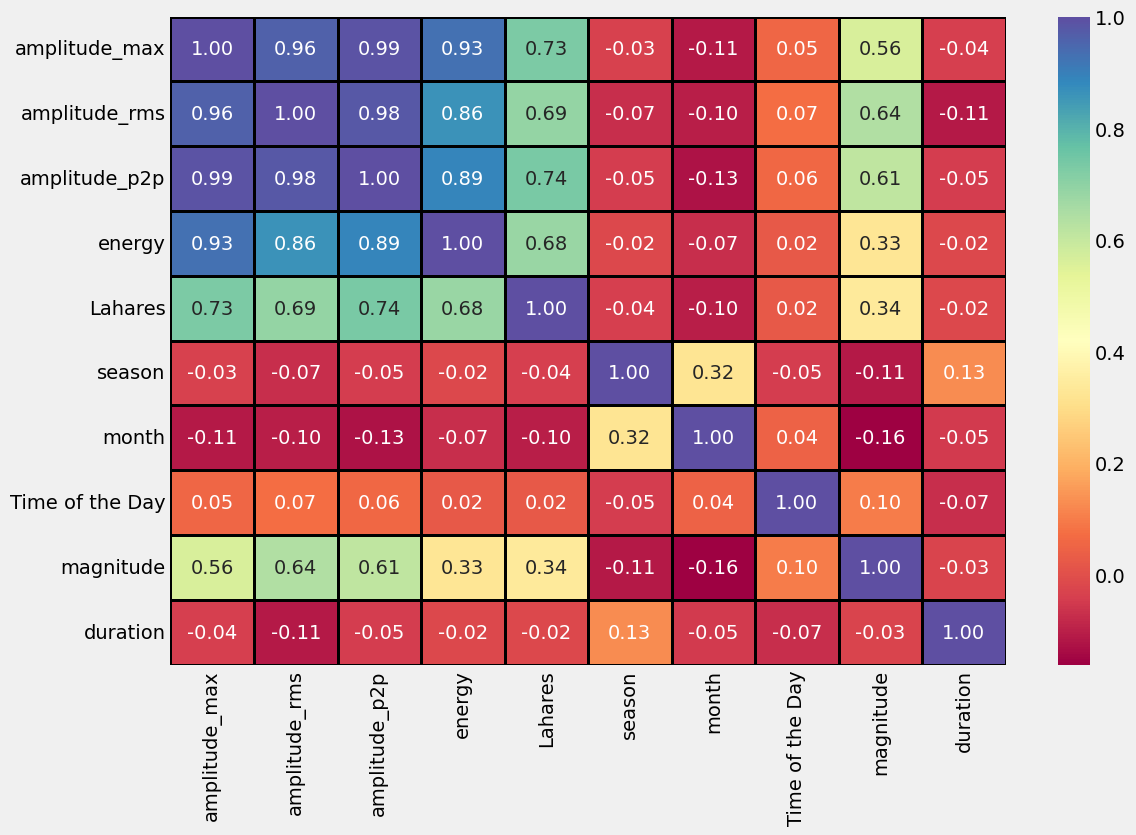

----------------------------------------------------------------------------------------------------
DataFrame Pairplot:



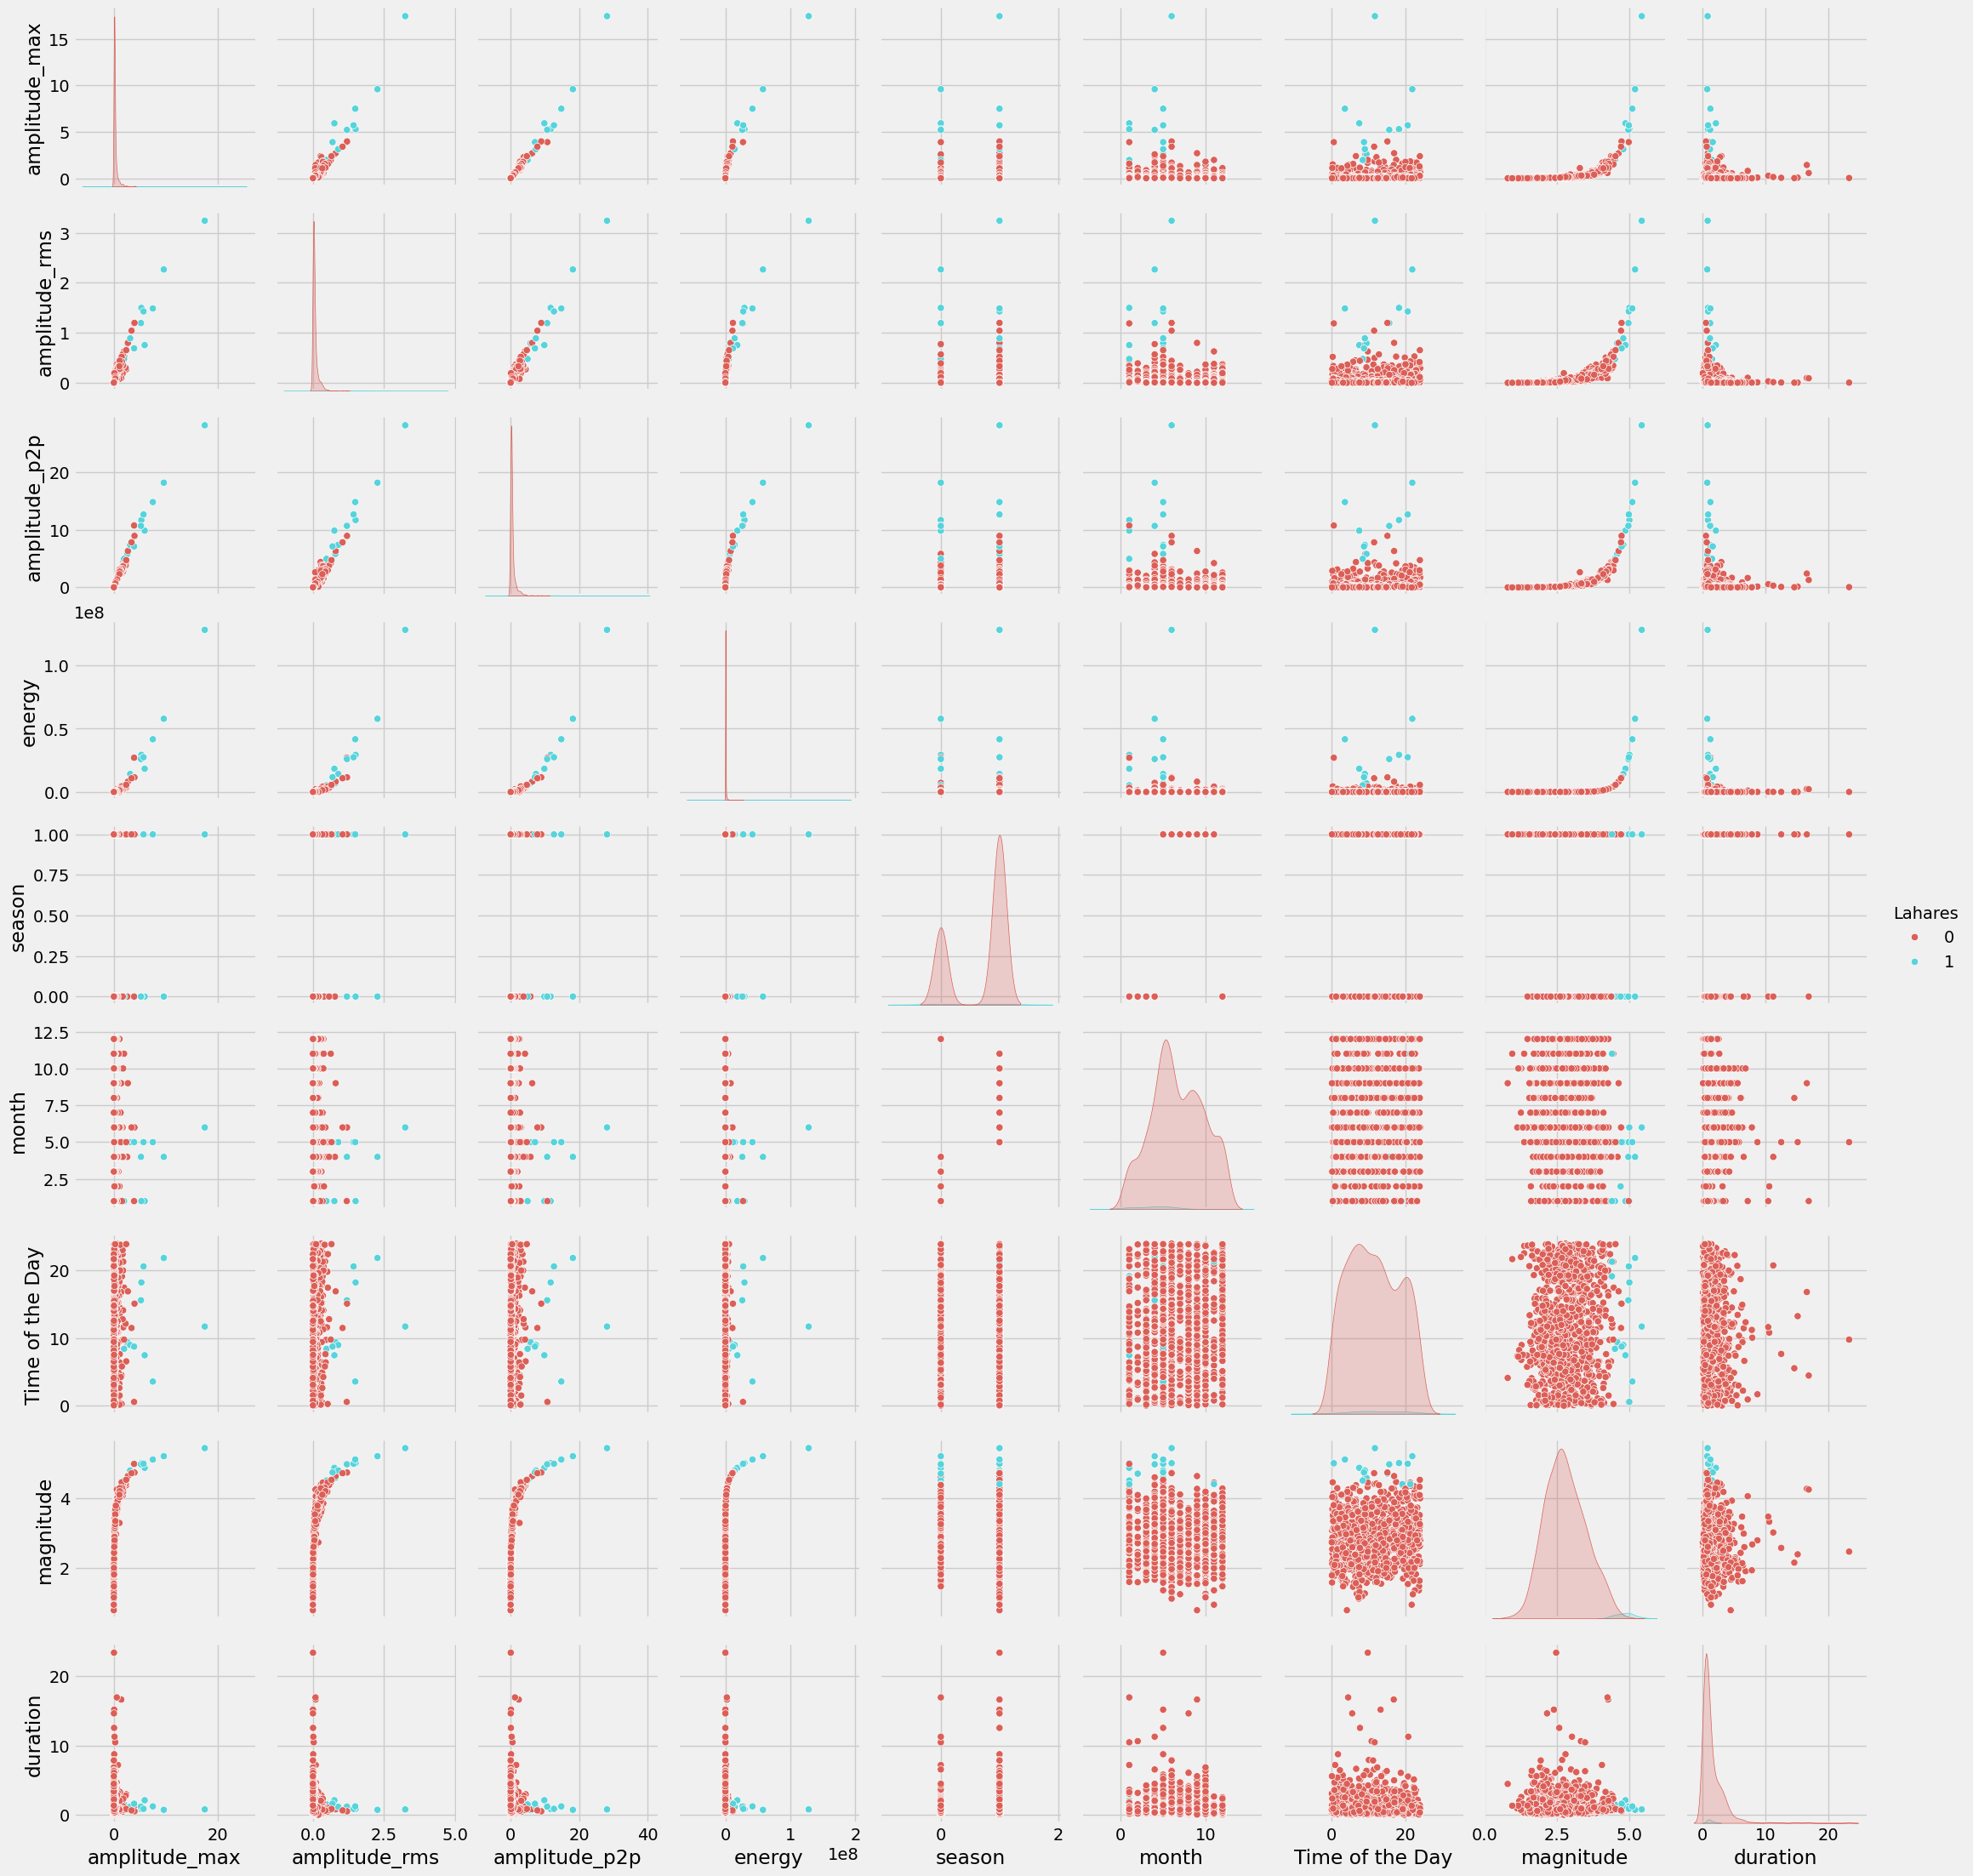

----------------------------------------------------------------------------------------------------
Histogram(s) & Boxplot(s):



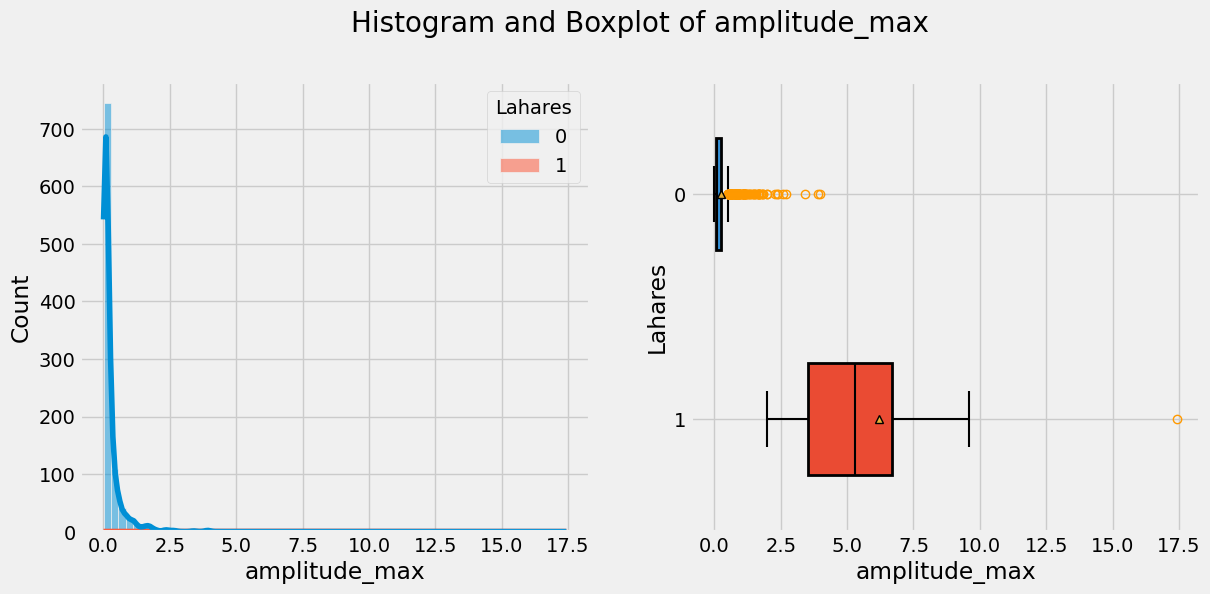

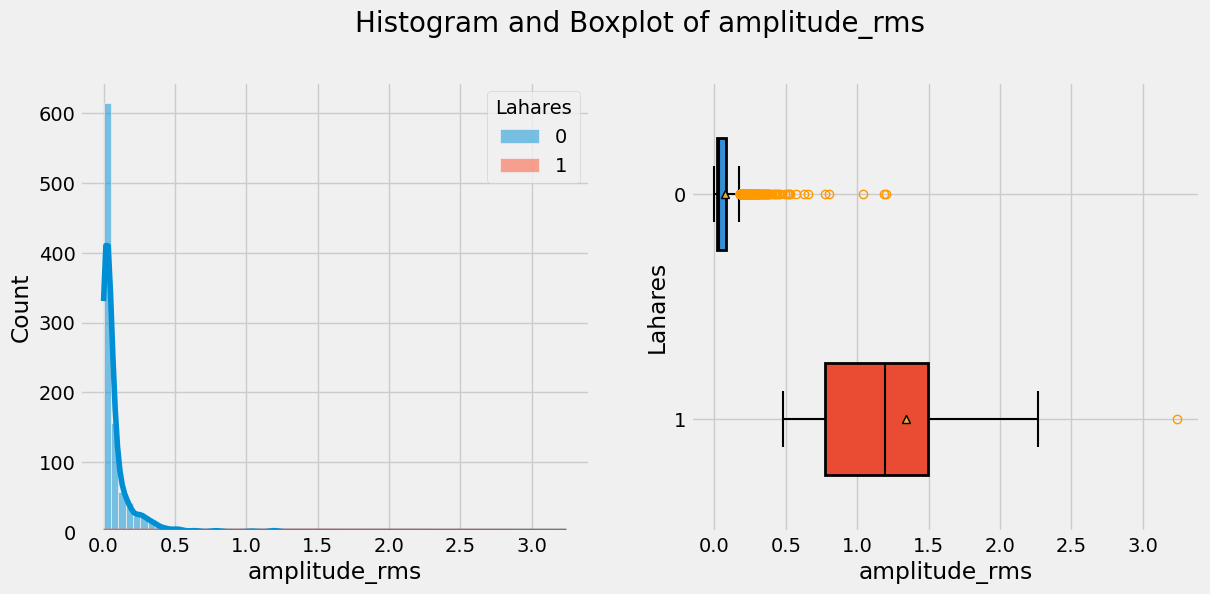

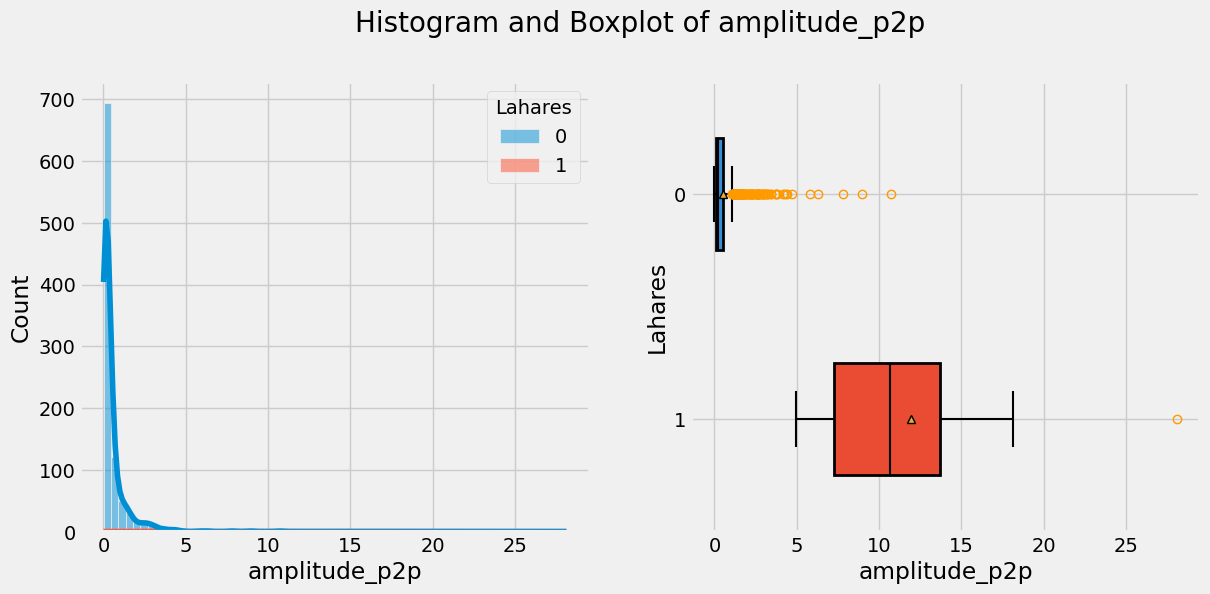

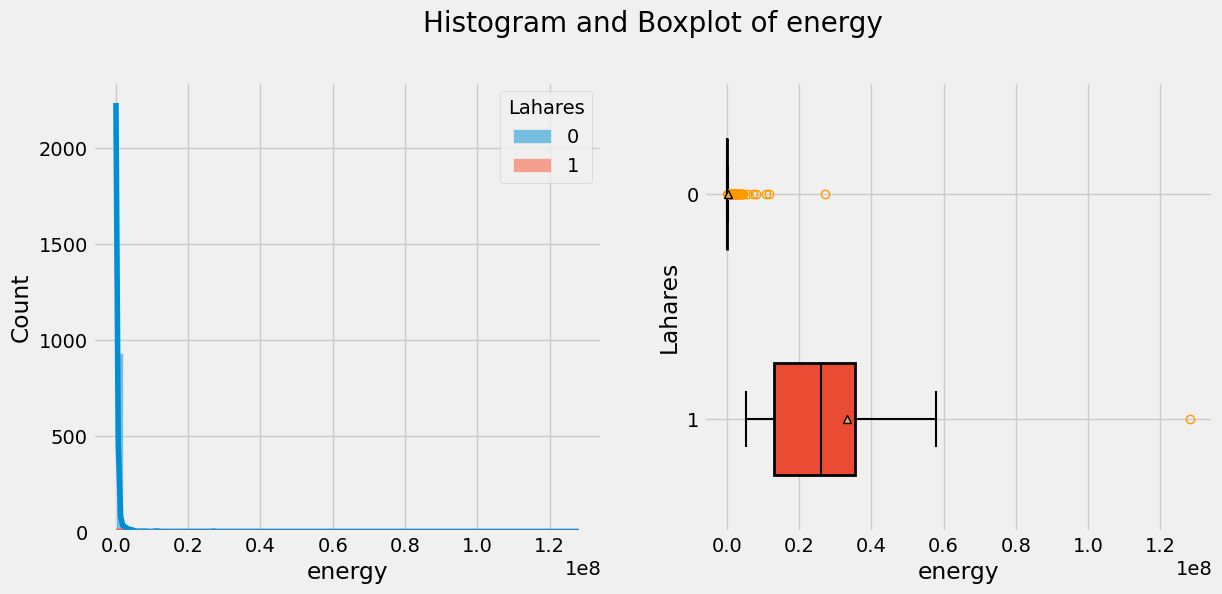

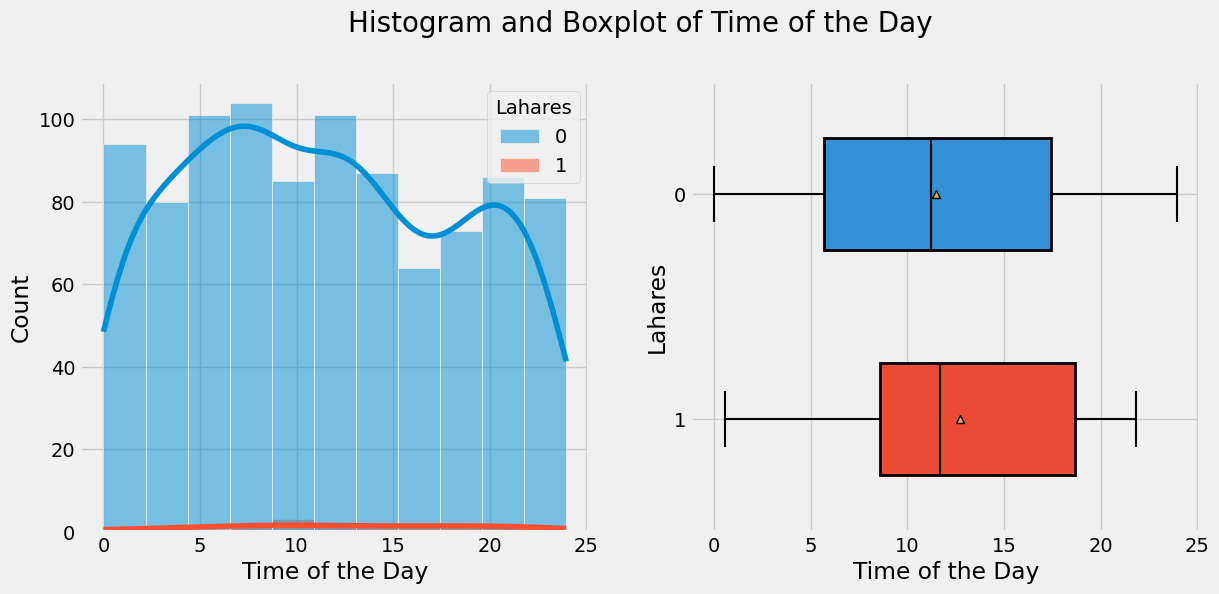

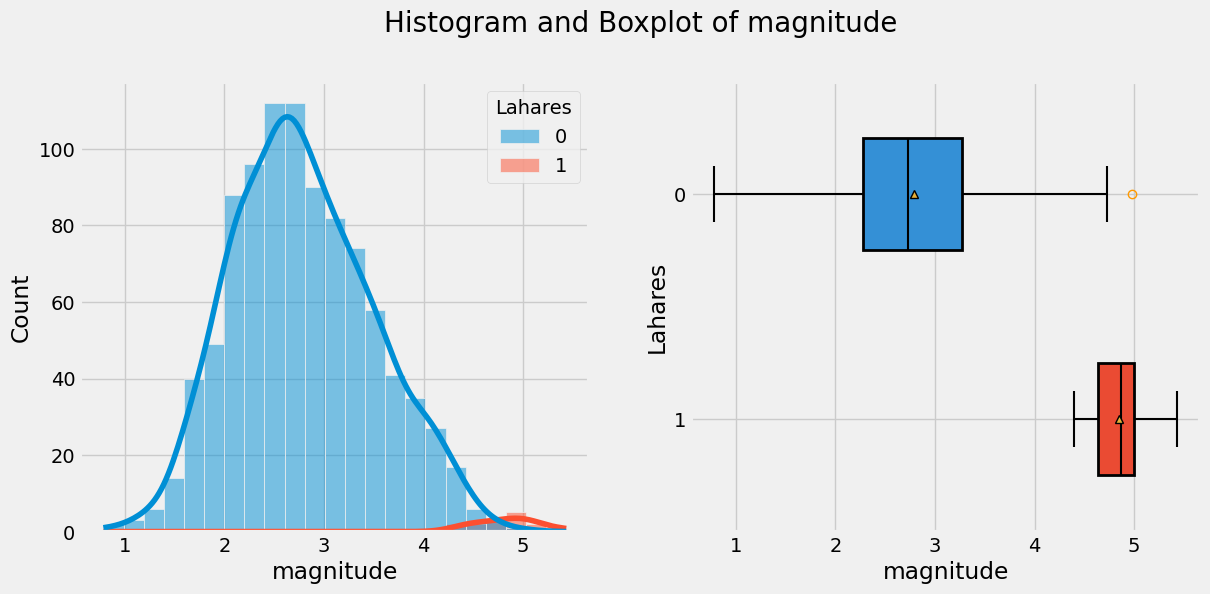

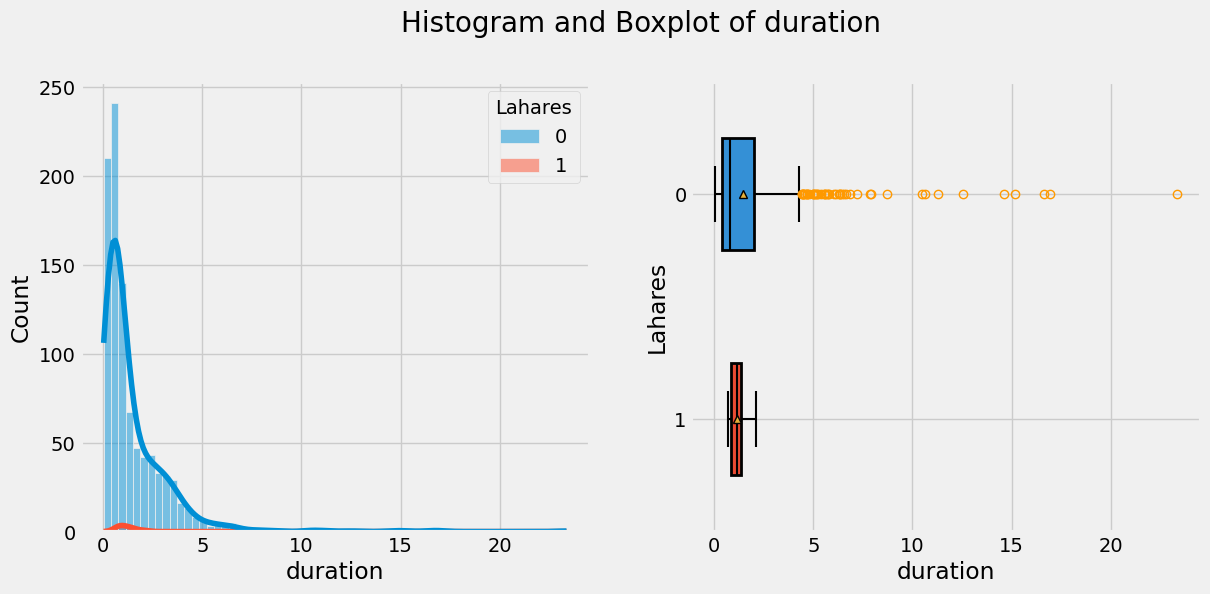

----------------------------------------------------------------------------------------------------
Countplot(s):



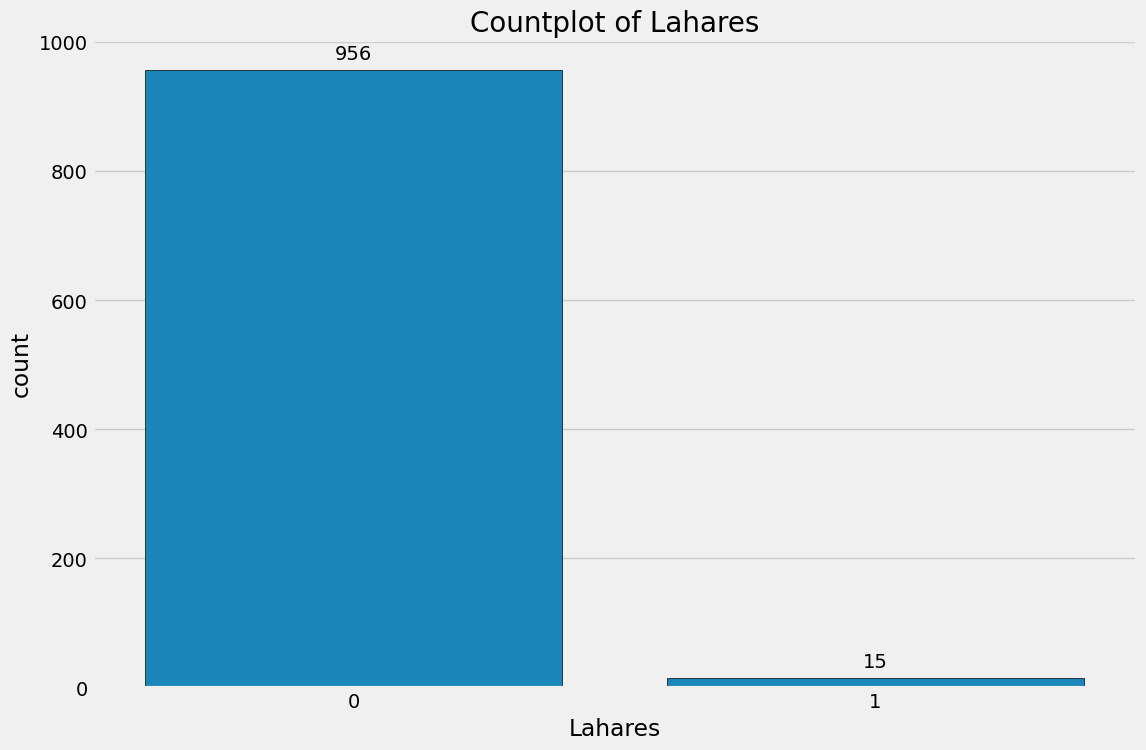

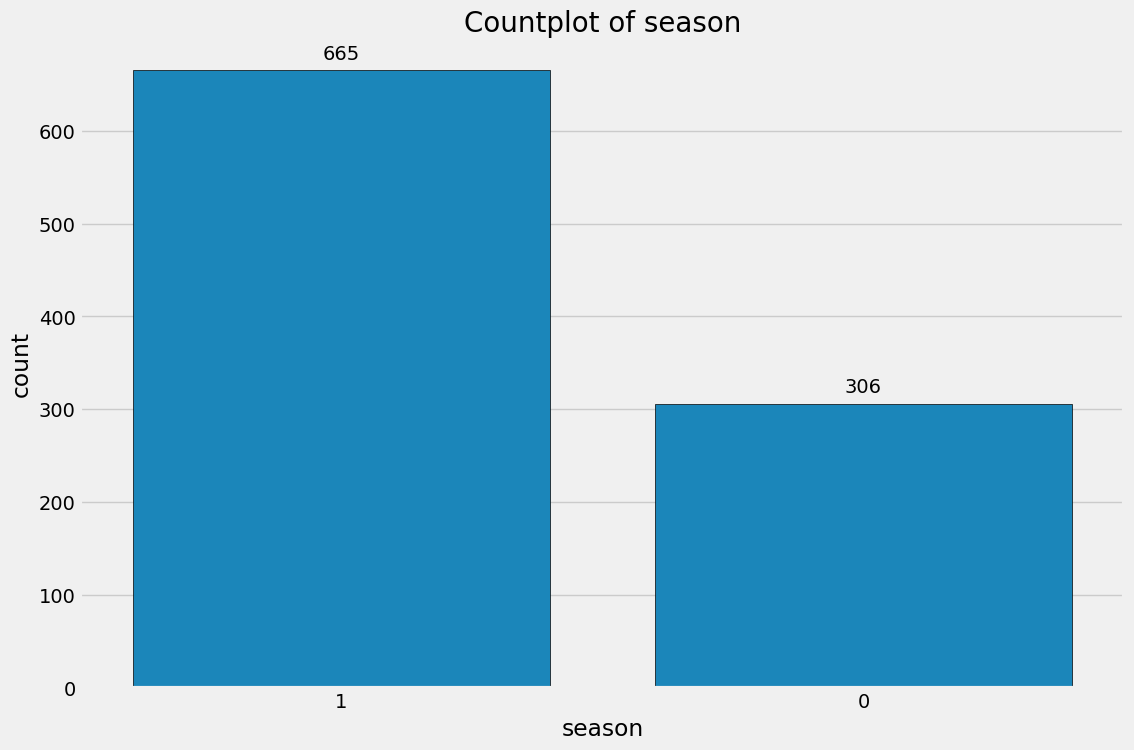

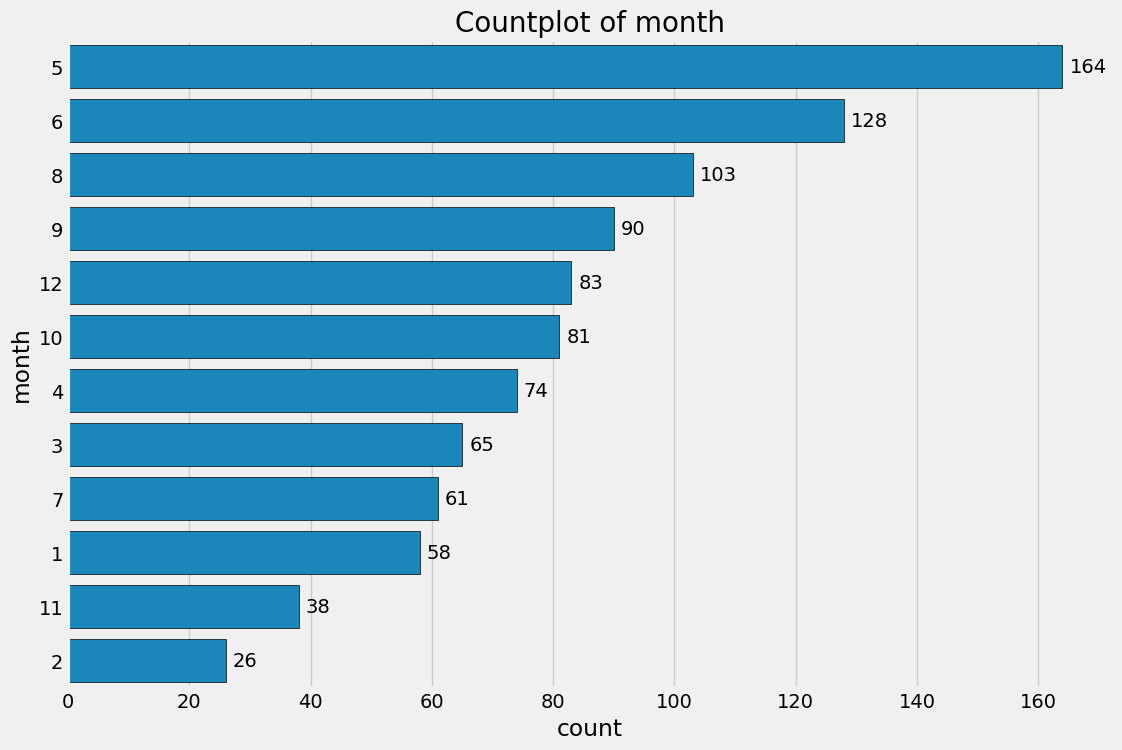

In [32]:
VRBA_eruptions_df['Lahares'] = VRBA_eruptions_df['Lahares'].astype(int)
fast_eda(VRBA_eruptions_df[['amplitude_max', 'amplitude_rms', 'amplitude_p2p', 'energy', 'Lahares', 'season', 'month', 'Time of the Day','magnitude', 'duration']], target= 'Lahares')

In [33]:
# Scale the energy column
VRBA_eruptions_scaled = VRBA_eruptions_df.copy()
scaler = StandardScaler()
VRBA_eruptions_scaled['energy'] = scaler.fit_transform(VRBA_eruptions_df[['energy']])

In [34]:
VRBA_df = VRBA_eruptions_scaled[['amplitude_max', 'amplitude_rms', 'amplitude_p2p', 'energy', 'Lahares', 'season', 'month norm', 'Time of the Day norm','magnitude', 'duration']].copy()

VRBA_df['Lahares'] = VRBA_df['Lahares'].astype(int)


As we can see, the energy, amplitude rms, amplitude max, amplitude p2p are higly correlated with each other. Thus, we will keep only one of the feature to estimate the others and reduce the dimensionality of the dataset.

In [35]:
TSNE_FEATURES = list(VRBA_df.drop(columns=['Lahares','amplitude_max', 'amplitude_rms', 'amplitude_p2p', 'energy', 'duration', 'magnitude']).columns)
print(TSNE_FEATURES)
train_tsne = VRBA_df[TSNE_FEATURES].values
y_tsne = VRBA_df['Lahares'].values

['season', 'month norm', 'Time of the Day norm']


In [36]:

%%time
plot_tsne = TSNE().fit(train_tsne)


CPU times: total: 2.27 s
Wall time: 2.3 s


C:\Users\bryan\AppData\Local\Temp\ipykernel_19544\4224289989.py:6: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  ax = sns.scatterplot(x = plot_tsne[:,0], y = plot_tsne[:,1], s = marker_sizes, hue = y_tsne,


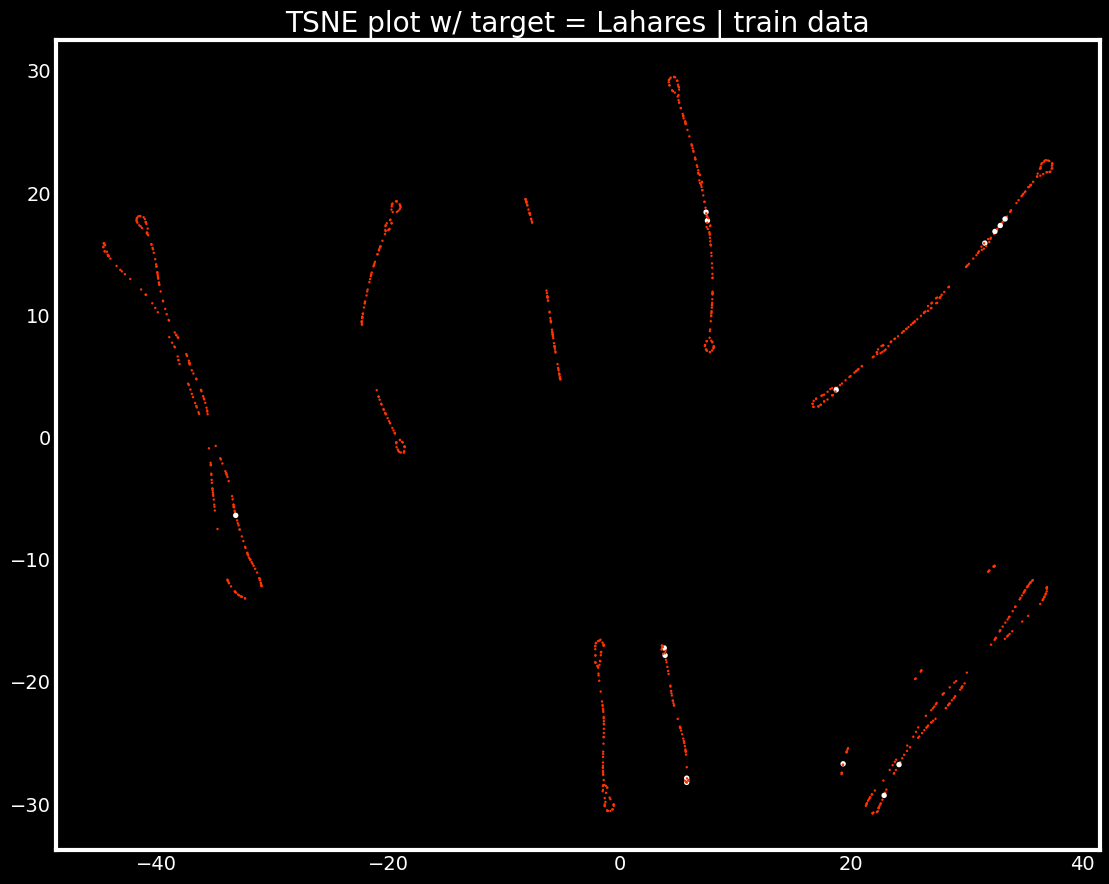

In [37]:
plt.style.use("dark_background")
plt.figure(figsize = (12, 10))

marker_sizes = [15 if hue == 1 else 3 for hue in y_tsne]

ax = sns.scatterplot(x = plot_tsne[:,0], y = plot_tsne[:,1], s = marker_sizes, hue = y_tsne,
                     linewidth = 0, palette = ["#ff3300", "#ffffff", "#33cc33"],
                     legend=False)
plt.grid(False)
plt.title(f"TSNE plot w/ target = Lahares | train data")
plt.show()

In [38]:
# TSNE_FEATURES = list(VRBA_df.drop(columns=['Lahares', 'season', 'month norm', 'Time of the Day norm']).columns)
# print(TSNE_FEATURES)
# train_tsne = VRBA_df[TSNE_FEATURES].values
# y_tsne = VRBA_df['Lahares'].values

In [39]:
# %%time
# plot_tsne = TSNE().fit(train_tsne)

In [40]:
# plt.style.use("dark_background")
# plt.figure(figsize = (12, 10))

# marker_sizes = [15 if hue == 1 else 3 for hue in y_tsne]

# ax = sns.scatterplot(x = plot_tsne[:,0], y = plot_tsne[:,1], s = marker_sizes, hue = y_tsne,
#                      linewidth = 0, palette = ["#ff3300", "#ffffff", "#33cc33"],
#                      legend=False)
# plt.grid(False)
# plt.title(f"TSNE plot w/ target = Lahares | train data")
# plt.show()

### Continuous Measurements Features Extraction

Lets analyze the Rsam values from Rincon de la Vieja just before the eruptions in VRBA. We want to prevent populutation of an eruption at least 7 minutes before it happens. We will thus take an averge value and standard deviation of Rsam values from Rincon de la Vieja in the time window of 7 to 60 minutes before each eruption in VRBA. (POSSIBLE DE REDUIRE LINTERVALLE POUR PLUS DE PRECISION)

It has been established that signals of eruptions could append till 5 days  before the actual eruption. We will thus analyze the Rsam values from Rincon de la Vieja in the time window of 5 days to 7 minutes before each eruption in VRBA. We make sure to take care of the gaps in the countinuous data in order to avoid bias in the calculations. 

In [41]:
# Store the assoicated data lines per eruptions

WINDOW_SIZE = pd.Timedelta(days=5)

In [95]:
# Get the dates associated with the data window
def get_window_dates(indices):
    print(indices)
    dates = []
    for idx in indices:
        date = Rincon_de_la_Vieja_df.loc[idx].index
        #print(date)
        dates.append(date)
    return dates

In [94]:
Rincon_de_la_Vieja_df.loc['2020-01-01']

DatetimeIndex(['2019-01-01 00:01:00', '2019-01-01 00:02:00',
               '2019-01-01 00:03:00', '2019-01-01 00:04:00',
               '2019-01-01 00:05:00'],
              dtype='datetime64[ns]', name='time', freq=None)

In [49]:
type(Rincon_de_la_Vieja_df.index)

pandas.core.indexes.datetimes.DatetimeIndex

In [68]:
def get_eruptions_windows_data(continuous_df, reference_df, window_size, maximum_observation_time_before_eruption=7, matched_time_column='time'):
    # Security check
    increasing_index = continuous_df.index.is_monotonic_increasing
    datetime_index = isinstance(continuous_df.index, pd.DatetimeIndex)
    if not datetime_index :
        raise ValueError("The continuous DataFrame index must be a DatetimeIndex.")
    if not increasing_index:
        print("Sorting continuous DataFrame by index...")
        continuous_df = continuous_df.sort_index()
     
    # Dictionaries to store results
    eruptions_windows_indices = {}
    eruptions_windows_dates = {} 

    max_obs_bfr_eruption = pd.Timedelta(minutes=maximum_observation_time_before_eruption)
    
    # Check if the gap column exists
    gap_col = "Gap before measurement (min)"
    if matched_time_column =='time':
        has_gap = True
    else:
        has_gap = False

    for index, row in reference_df.iterrows():
        measurement_time = row[matched_time_column]
        
        # Check if the eruption has a corresponding continuous data point within the tolerance
        if pd.isna(measurement_time):
            print(f"Missing Continuous Data or NaT time for eruption {index}. Skipping.")
            print(f"Missing Continuous Data of at at least 1 day for eruption at {row['t1']}.\n  Adapt the matching tolerance or remove this eruption from the analysis.")
            continue

        # Adjust the end time based on the gap before measurement (if column exists, else 0)
        gap = row[gap_col] if has_gap else 0
        
        eruption_time = measurement_time + pd.Timedelta(minutes=gap)
        security = eruption_time - max_obs_bfr_eruption
        
        if measurement_time > security:
            end_time = security
        else:
            end_time = measurement_time
            
        # start time is window_size before the eruption time while taking into account the gap before measurement
        start_time = eruption_time - window_size

        # Create a mask for the time window
        mask = (continuous_df.index >= start_time) & (continuous_df.index <= end_time)
        
        # Extract the subset of data once
        window_data = continuous_df.loc[mask]
        
        # Store indices (as requested originally)
        eruptions_windows_indices[index + 1] = window_data.index.tolist()
        
        # Store dates (integrated logic from get_window_dates, but faster)
        eruptions_windows_dates[index + 1] = window_data.index.tolist()

    # Return both dictionaries
    return eruptions_windows_indices, eruptions_windows_dates

In [69]:
# # Store the eruptions windows data in numpy files for different continuous datasets
# eruptions_windows_indices , eruptions_windows_dates = get_eruptions_windows_data(Rincon_de_la_Vieja_df, matched_time, WINDOW_SIZE, maximum_observation_time_before_eruption=7)
# sei_geo_eruptions_windows_indices, sei_geo_eruptions_windows_dates = get_eruptions_windows_data(Rincon_df, matched_time, WINDOW_SIZE, maximum_observation_time_before_eruption=7, matched_time_column='date')

# # Save to numpy files
# np.save('MSc_Bryan_Rincon/Eruptions indices/eruptions_windows_indices.npy', eruptions_windows_indices)
# np.save('MSc_Bryan_Rincon/Eruptions indices/eruptions_windows_dates.npy', eruptions_windows_dates)
# np.save('MSc_Bryan_Rincon/Eruptions indices/sei_geo_eruptions_windows_indices.npy', sei_geo_eruptions_windows_indices)
# np.save('MSc_Bryan_Rincon/Eruptions indices/sei_geo_eruptions_windows_dates.npy', sei_geo_eruptions_windows_dates)

eruptions_windows_indices, eruptions_windows_dates = np.load('MSc_Bryan_Rincon/Eruptions indices/eruptions_windows_indices.npy', allow_pickle=True).item(), np.load('MSc_Bryan_Rincon/Eruptions indices/eruptions_windows_dates.npy', allow_pickle=True).item()
sei_geo_eruptions_windows_indices, sei_geo_eruptions_windows_dates = np.load('MSc_Bryan_Rincon/Eruptions indices/sei_geo_eruptions_windows_indices.npy', allow_pickle=True).item(), np.load('MSc_Bryan_Rincon/Eruptions indices/sei_geo_eruptions_windows_dates.npy', allow_pickle=True).item()

Sorting continuous DataFrame by index...


In [71]:
## Find sequences of following eruptions
def find_eruption_chains(df, window_size):
    chains = []
    # Check if dataframe is empty
    if df.empty:
        return chains
    # Ensure data is sorted by time 
    df_sorted = df.sort_values('t1')
    # Initialize the first chain with the first eruption
    # current_chain stores the indices of the eruptions
    first_id = df_sorted.index[0] 
    current_chain = [int(first_id)]
    # Keep track of the 'last seen' time to compare against
    last_time = df_sorted.loc[first_id, 't1']
    # Iterate through the rest of the eruptions
    for i in range(1, len(df_sorted)):
        curr_id = df_sorted.index[i]
        curr_time = df_sorted.loc[curr_id, 't1']
        # Current Time vs. LAST ADDED Time 
        if curr_time - last_time <= window_size:
            # In the window of the previous eruption, add to chain
            current_chain.append(int(curr_id))
            last_time = curr_time 
        else:
            # Time gap is too big
            # Store the finished chain
            chains.append(current_chain)
            # Start a new chain with the current eruption
            current_chain = [int(curr_id)]
            last_time = curr_time
    # Append the final chain after the loop finishes
    chains.append(current_chain)
    return chains


In [72]:
## Store the eruption chains and their heads with some stats printed
eruption_chains = find_eruption_chains(VRBA_eruptions_df, WINDOW_SIZE)
# Store the head of each chain
head_chains = [chain[0] for chain in eruption_chains]

print(f"Found {len(eruption_chains)} distinct eruption sequences.")
for y, chain in enumerate(eruption_chains):
        print(f"Sequence {y+1}: ({len(chain)}) eruptions {chain}")

print("\n")

# Calculate the time differences between each chains
chain_time_differences = []
chain_gaps = []
for i, chain in enumerate(eruption_chains):
    first_erup_id = chain[0]
    last_erup_id = chain[-1]
    first_time = VRBA_eruptions_df.loc[first_erup_id, 't1']
    last_time = VRBA_eruptions_df.loc[last_erup_id, 't1']
    time_diff = last_time - first_time
    if i+1 < len(eruption_chains):
        next_chain = eruption_chains[i+1]
        next_first_erup_id = next_chain[0]
        next_first_time = VRBA_eruptions_df.loc[next_first_erup_id, 't1']
        gap = next_first_time - last_time
        chain_gaps.append(gap)

        chain_time_differences.append(time_diff)
        print(f"Sequence {i+1} duration: {time_diff} ")

print("\n")
print("Gaps between sequence:")
for i, gap in enumerate(chain_gaps):
    print(f"Gap after sequence {i+1}: {gap}")

Found 79 distinct eruption sequences.
Sequence 1: (2) eruptions [0, 1]
Sequence 2: (2) eruptions [2, 3]
Sequence 3: (4) eruptions [4, 5, 6, 7]
Sequence 4: (4) eruptions [8, 9, 10, 11]
Sequence 5: (9) eruptions [12, 13, 14, 15, 16, 17, 18, 19, 20]
Sequence 6: (6) eruptions [21, 22, 23, 24, 25, 26]
Sequence 7: (2) eruptions [27, 28]
Sequence 8: (5) eruptions [29, 30, 31, 32, 33]
Sequence 9: (1) eruptions [34]
Sequence 10: (1) eruptions [35]
Sequence 11: (2) eruptions [36, 37]
Sequence 12: (1) eruptions [38]
Sequence 13: (2) eruptions [39, 40]
Sequence 14: (4) eruptions [41, 42, 43, 44]
Sequence 15: (58) eruptions [45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102]
Sequence 16: (1) eruptions [103]
Sequence 17: (4) eruptions [104, 105, 106, 107]
Sequence 18: (2) eruptions [108, 109]
Sequence 19: (40) eruption

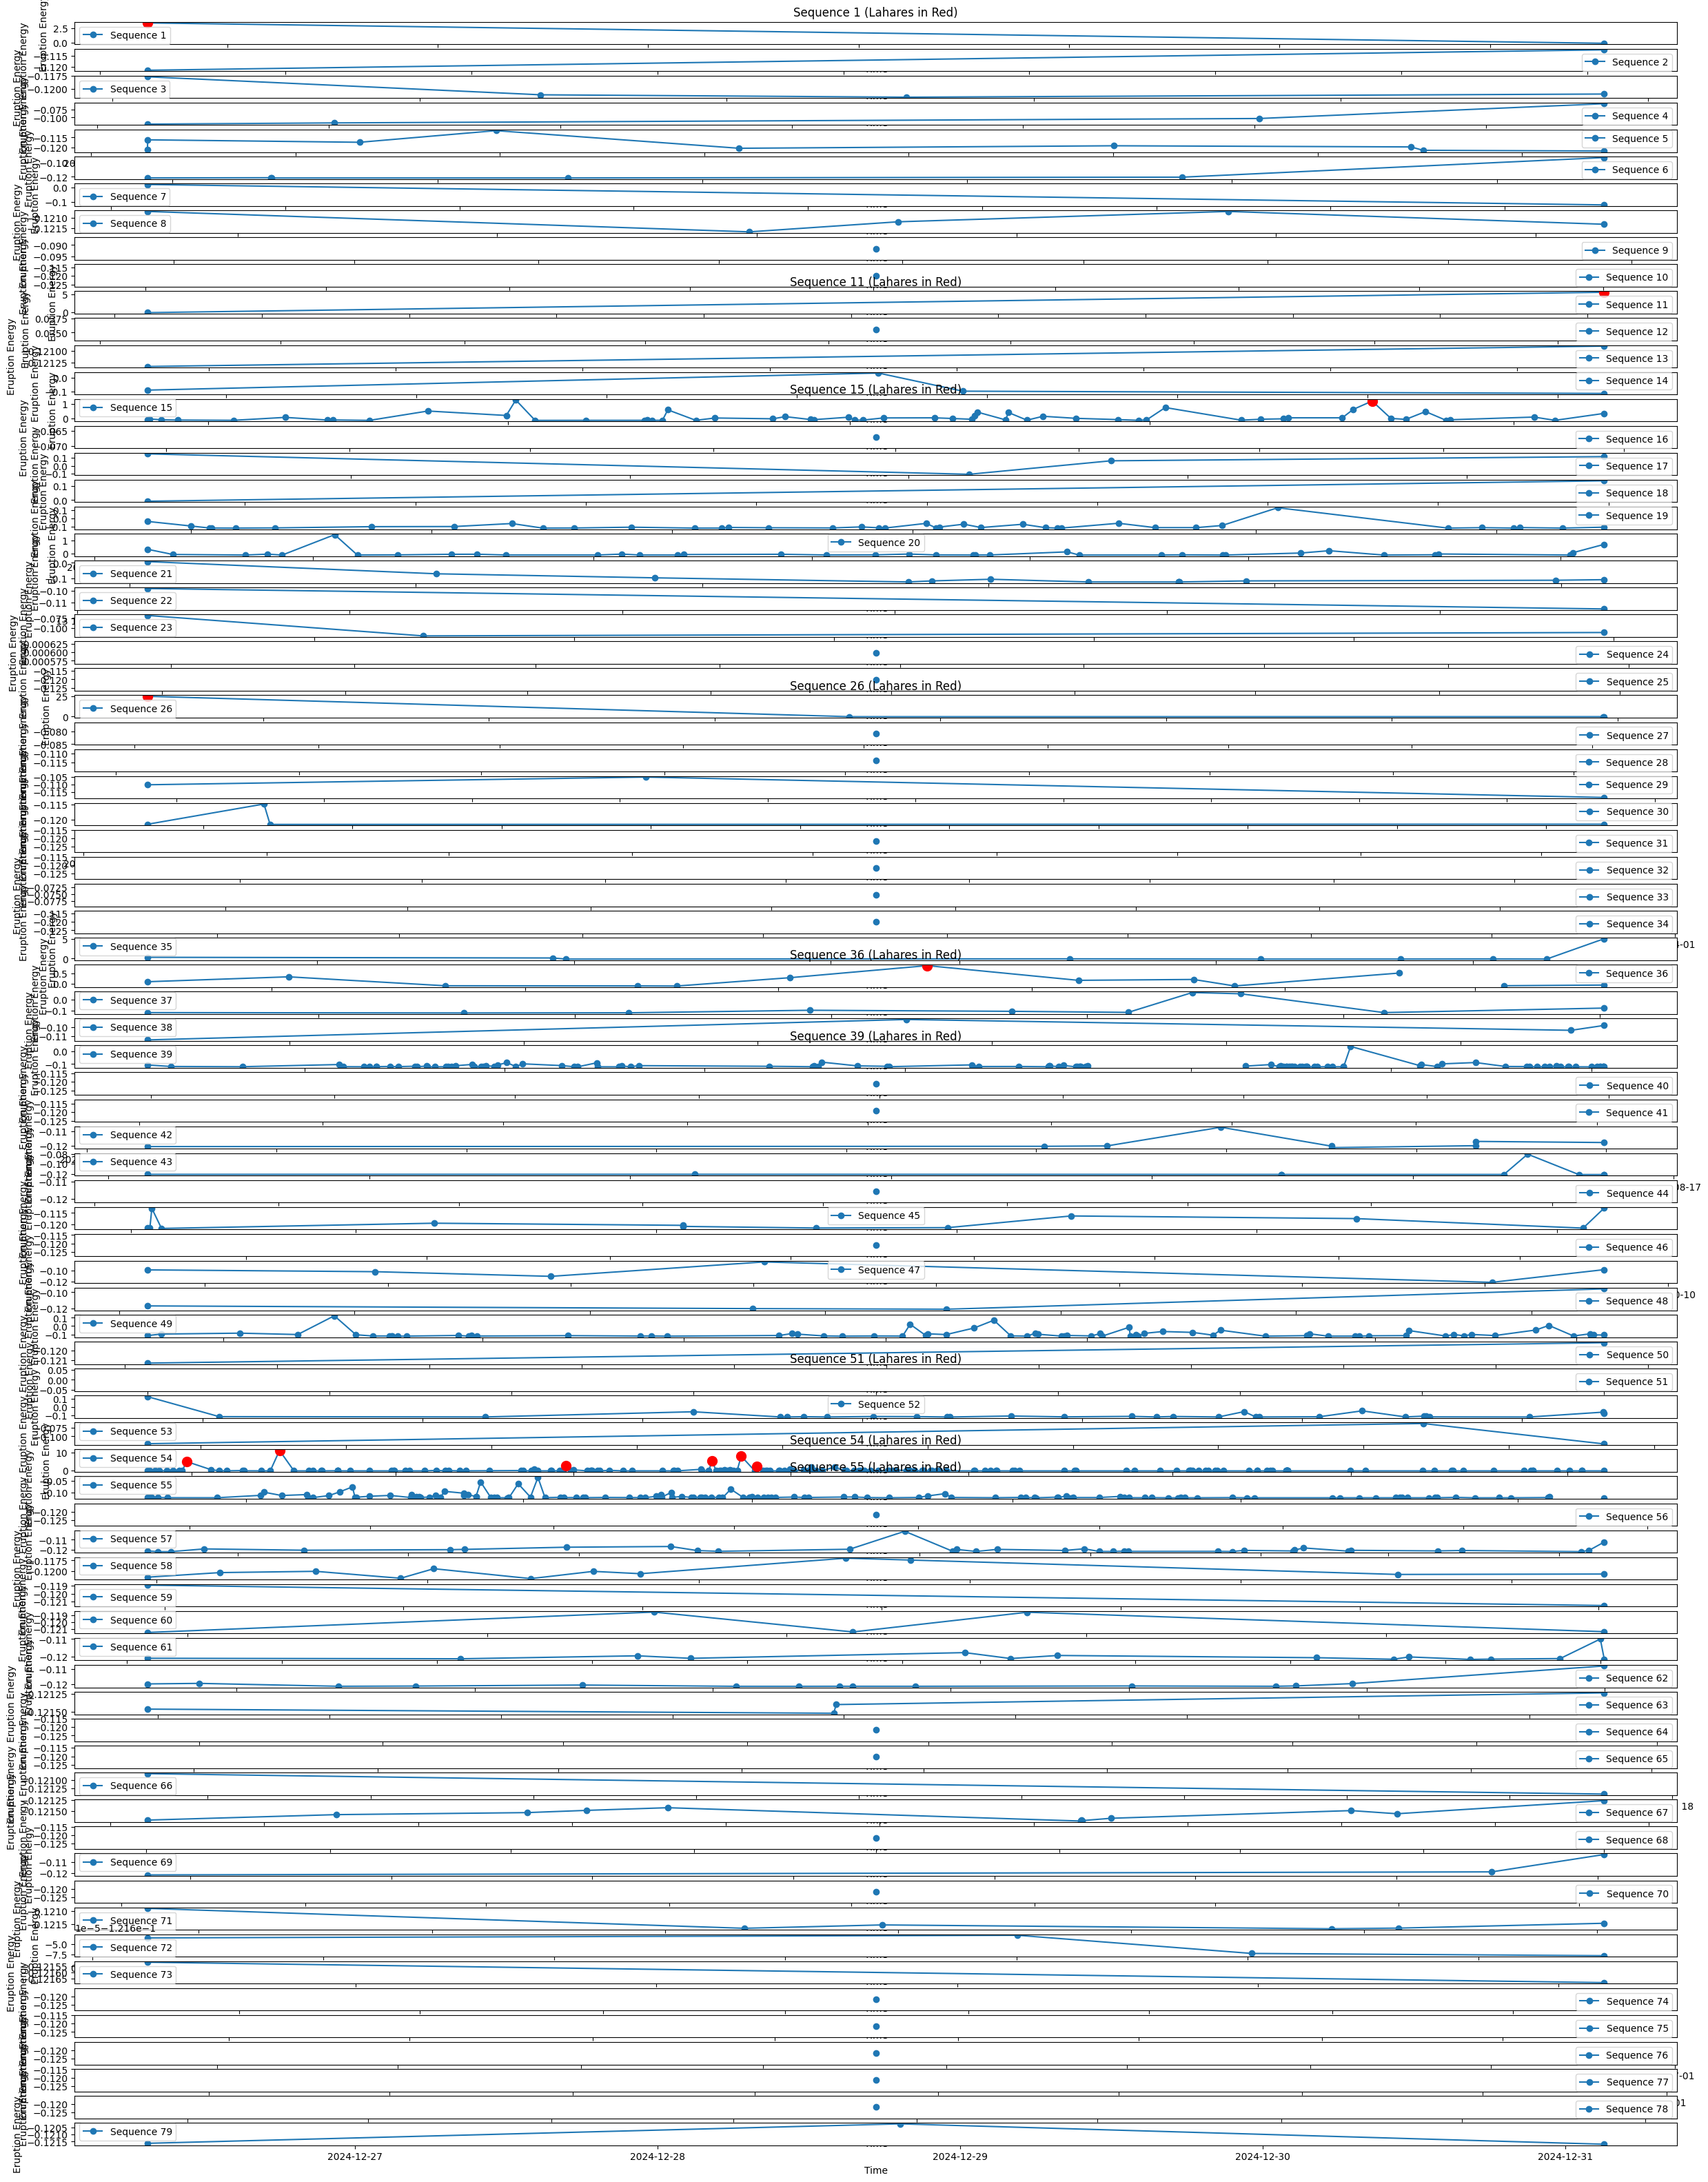

In [73]:
# Plot the chains in different colors over time with y being the energy of the eruptions and point out the lahar eruptions
plt.style.use("default")
plt.figure(figsize=(30, 40))
for i, chain in enumerate(eruption_chains):
    plt.subplot(len(eruption_chains), 1, i+1)
    times = [VRBA_eruptions_scaled.loc[erup_id, 't1'] for erup_id in chain]
    energies = [VRBA_eruptions_scaled.loc[erup_id, 'energy'] for erup_id in chain]
    plt.plot(times, energies, marker='o', label=f'Sequence {i+1}')
    # Highlight lahar eruptions in the chain
    for erup_id in chain:
        if VRBA_eruptions_scaled.loc[erup_id, 'Lahares']:
            plt.plot(VRBA_eruptions_scaled.loc[erup_id, 't1'], VRBA_eruptions_scaled.loc[erup_id, 'energy'], marker='o', color='red', markersize=10)
            plt.title(f'Sequence {i+1} (Lahares in Red)')
    plt.xlabel('Time')
    plt.ylabel('Eruption Energy')
    plt.legend()

plt.show()


In [74]:
# Eruptions that had lahar events
lahar_eruptions = VRBA_eruptions_df[VRBA_eruptions_df["Lahares"] == True].index.tolist()
print(f"Eruptions with Lahares: {lahar_eruptions}")

Eruptions with Lahares: [0, 37, 94, 208, 240, 245, 326, 494, 536, 544, 576, 595, 606, 608, 838]


In [75]:
for y, chain in enumerate(eruption_chains):
    for lahar in lahar_eruptions:
        if lahar in chain:
            print(f"Sequence {y+1} contains lahar eruption ID: {lahar}")
            idx = chain.index(lahar)
            if idx > 0:
                print(f"  Previous eruptions in sequence: {len(chain[:idx])}")
            else:
                print("  This lahar eruption is the first in the sequence")
            

Sequence 1 contains lahar eruption ID: 0
  This lahar eruption is the first in the sequence
Sequence 11 contains lahar eruption ID: 37
  Previous eruptions in sequence: 1
Sequence 15 contains lahar eruption ID: 94
  Previous eruptions in sequence: 49
Sequence 26 contains lahar eruption ID: 208
  This lahar eruption is the first in the sequence
Sequence 36 contains lahar eruption ID: 240
  Previous eruptions in sequence: 6
Sequence 36 contains lahar eruption ID: 245
  Previous eruptions in sequence: 11
Sequence 39 contains lahar eruption ID: 326
  Previous eruptions in sequence: 64
Sequence 51 contains lahar eruption ID: 494
  This lahar eruption is the first in the sequence
Sequence 54 contains lahar eruption ID: 536
  Previous eruptions in sequence: 8
Sequence 54 contains lahar eruption ID: 544
  Previous eruptions in sequence: 16
Sequence 54 contains lahar eruption ID: 576
  Previous eruptions in sequence: 48
Sequence 54 contains lahar eruption ID: 595
  Previous eruptions in sequenc

    We see that two Lahares are starting the sequence of eruptions. Those eruptions will particularly interesting when comparing with the others eruptions starting sequences.

In [76]:
## Accumulation of potential ash because of following eruptions
def calculate_ash_potential(df, decay_rate=0.98):
    """
    Calculate ash accumulation potential over time.
    decay_rate: fraction of ash remaining from previous day (0.98 = 98% retention)
    """
    df = df.sort_values('t1')
    
    ash_potential = []
    current_ash = 0
    last_time = df.iloc[0]['t1']
    
    for index, row in df.iterrows():
        current_time = row['t1']
        
        days_passed = (current_time - last_time)
        
        if days_passed > pd.Timedelta(0):
            days_passed = days_passed.total_seconds() / (24 * 3600)
            current_ash = current_ash * (decay_rate ** days_passed)
        
        ash_potential.append(current_ash)
        
        current_ash += 1 
        
        last_time = current_time
        
    df['ash_history_score'] = ash_potential
    return df


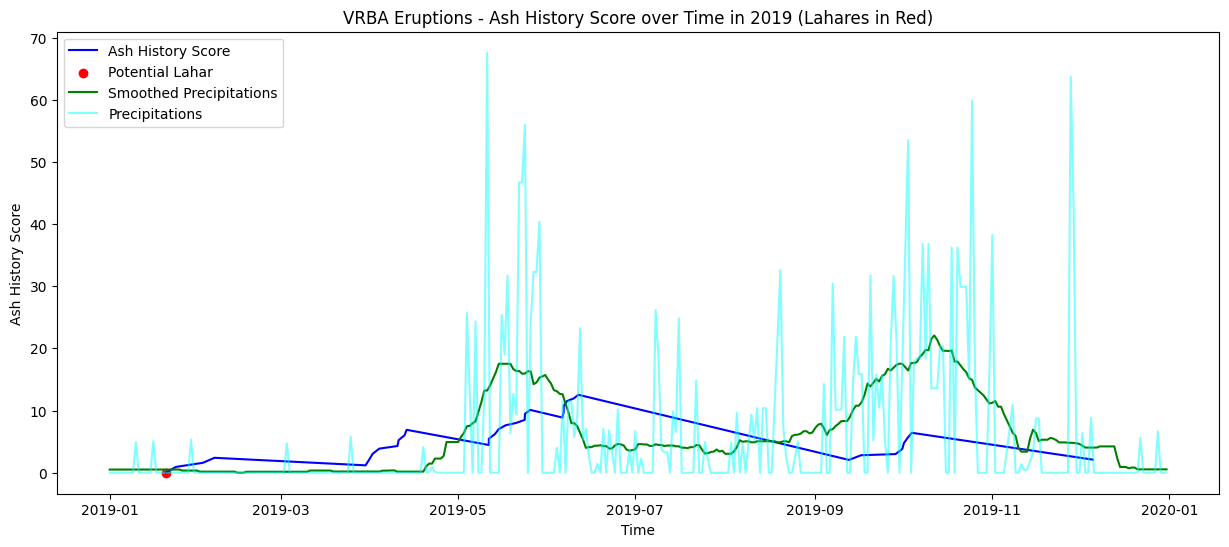

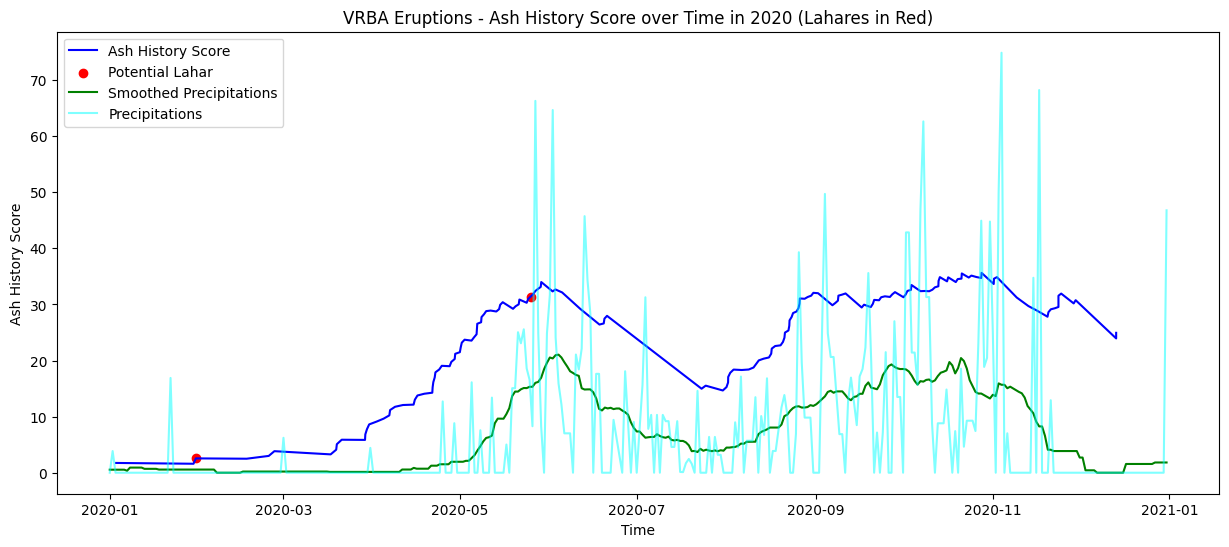

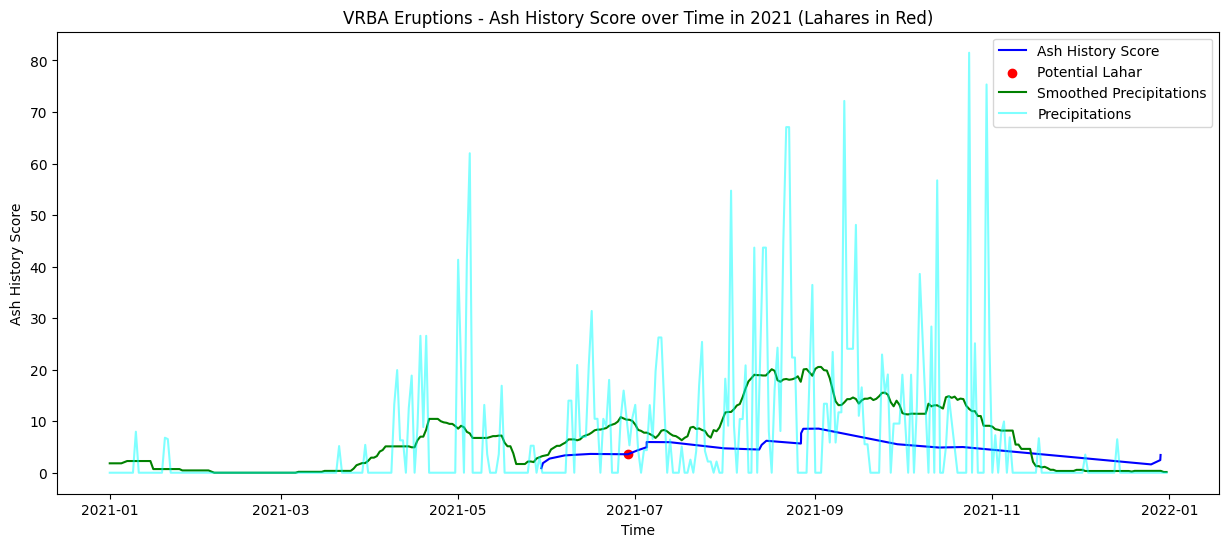

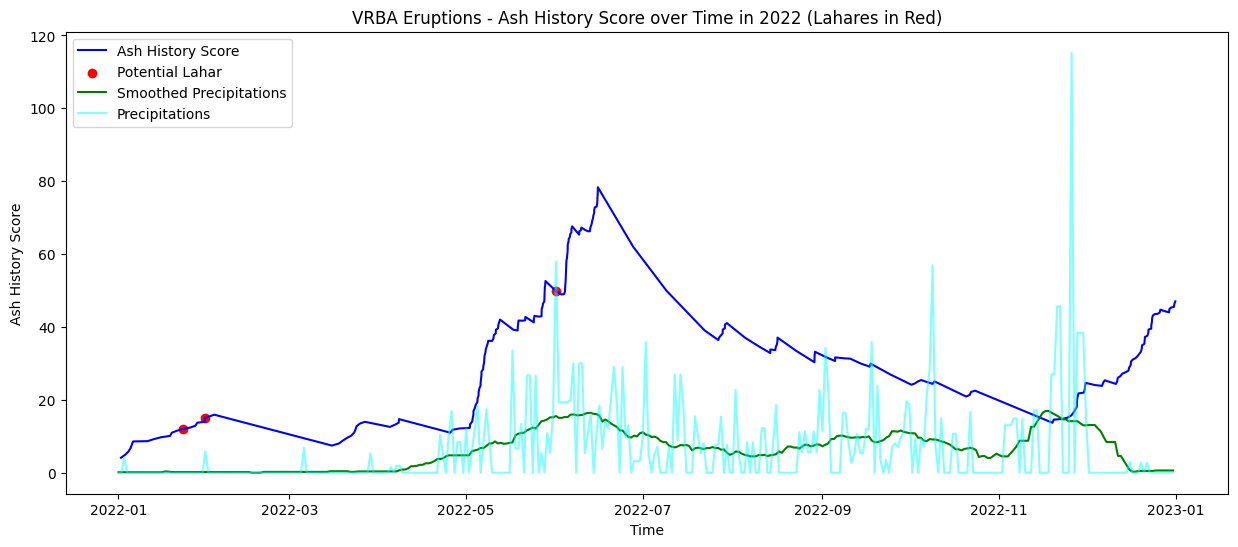

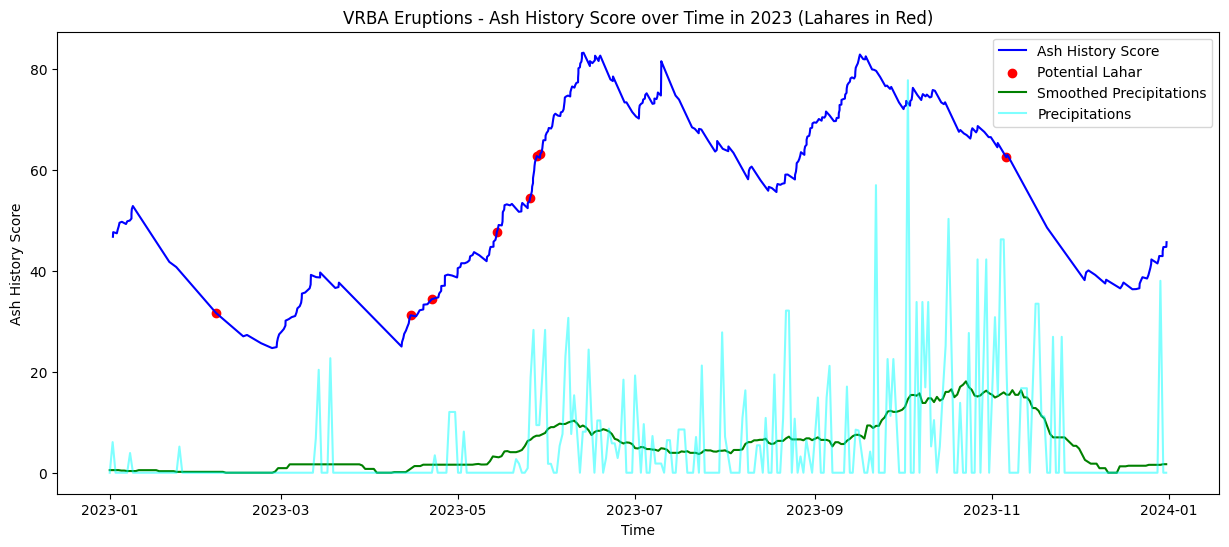

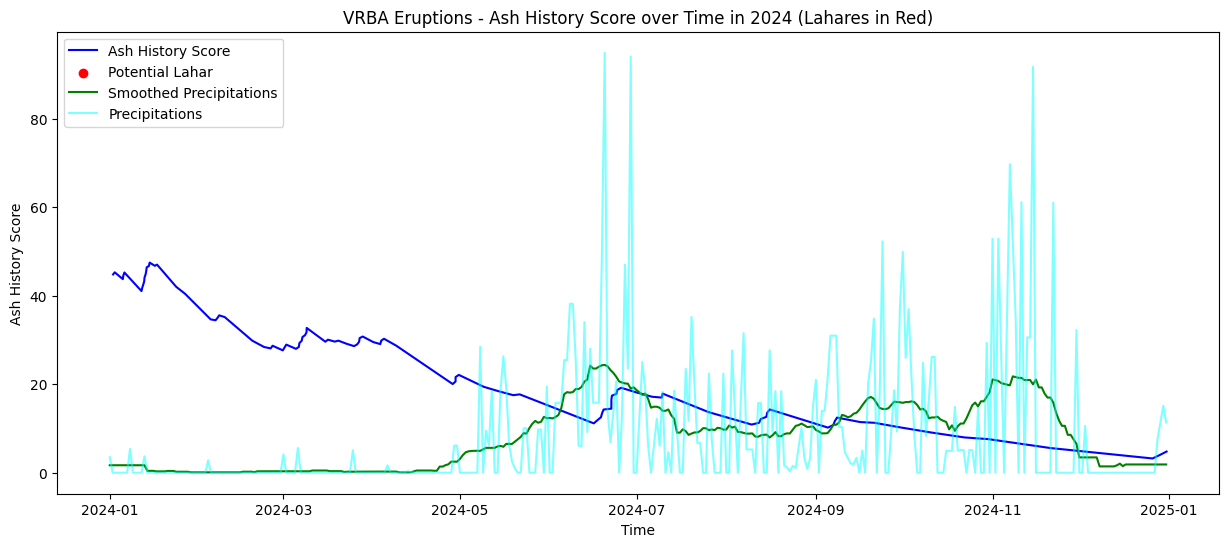

In [82]:
# Plot per years
years = reduce_VRBA_df['t1'].dt.year.unique()
for year in years:
    yearly_df = reduce_VRBA_df[reduce_VRBA_df['t1'].dt.year == year]
    plt.figure(figsize=(15, 6))
    plt.plot(yearly_df['t1'], yearly_df['ash_history_score'], label='Ash History Score', color='blue')
    # Overlay red points where Lahares == True
    lahar_df = yearly_df[yearly_df["Lahares"] == True]
    plt.scatter(
        lahar_df['t1'],
        lahar_df['ash_history_score'],
        color='red',
        label='Potential Lahar'
    )
# --- FIX STARTS HERE ---
    # Create a simple True/False array (ignores index labels)
    mask = (Rain2019_2024_df.index.year == year)
    
    # Apply the mask using position
    times = Rain2019_2024_df.loc[mask].index
    smoothed_precipitations_year = smoothed_precipitations[mask]
    
    # Note: Using 'values' helps here too if 'precipitations' has a different index
    precipitations_year = precipitations[mask] 
    # --- FIX ENDS HERE ---

    plt.plot(times, smoothed_precipitations_year, label='Smoothed Precipitations', color='green')
    plt.plot(times, precipitations_year, label='Precipitations', color='cyan', alpha=0.5)

    plt.title(f'VRBA Eruptions - Ash History Score over Time in {year} (Lahares in Red)')
    plt.xlabel('Time')
    plt.ylabel('Ash History Score')
    plt.legend()
    plt.show()

#### Accoustic Data 

##### Eruption Window 

In [ ]:
# Get an overview of the data present in each eruption window
window_size =  WINDOW_SIZE// pd.Timedelta(minutes=1)  # in minutes
for y in range(1, len(eruptions_windows_indices) + 1):
    print(f"Eruption {y} window indices: {len(eruptions_windows_indices[y])} percentage data present: {len(eruptions_windows_indices[y]) / window_size * 100:.2f}% ")
    if len(eruptions_windows_indices[y]) / window_size * 100 == 0:
        print(f"eruption {y} has no data in the window")

Eruption 1 window indices: 6614 percentage data present: 91.86% 
Eruption 2 window indices: 7070 percentage data present: 98.19% 
Eruption 3 window indices: 7143 percentage data present: 99.21% 
Eruption 4 window indices: 6586 percentage data present: 91.47% 
Eruption 5 window indices: 6582 percentage data present: 91.42% 
Eruption 6 window indices: 6458 percentage data present: 89.69% 
Eruption 7 window indices: 6351 percentage data present: 88.21% 
Eruption 8 window indices: 6162 percentage data present: 85.58% 
Eruption 9 window indices: 1370 percentage data present: 19.03% 
Eruption 10 window indices: 1702 percentage data present: 23.64% 
Eruption 11 window indices: 4435 percentage data present: 61.60% 
Eruption 12 window indices: 4909 percentage data present: 68.18% 
Eruption 13 window indices: 5186 percentage data present: 72.03% 
Eruption 14 window indices: 5188 percentage data present: 72.06% 
Eruption 15 window indices: 2723 percentage data present: 37.82% 
Eruption 16 window 

 We can see that a lot of eruptions are poorly covered during the 5 days preceding the eruption. The eruptions that are less covered will be less reliable for the analysis. 

#### No eruption Window

We need to evaluate also window where nothing is happening to have a better idea of the difference between eruption and non-eruption windows. We will thus create random windows of 5 days duration in the Rincon de la Vieja continuous dataframe where no eruption is happening in VRBA. We will then apply the same feature extraction process on those windows.

In [137]:
# Find point of data not belonging to any eruption window
def get_unused_data_indices(df, eruptions_windows_indices):
    # Collect all indices currently used in eruption windows
    all_used_indices = set()
    for indices in eruptions_windows_indices.values():
        all_used_indices.update(indices)
    
    # Get all available indices from the DataFrame
    all_data_indices = set(df.index.tolist())
    
    # Find the difference (available - used) and sort them
    unused_indices = sorted(list(all_data_indices - all_used_indices))
    
    print(f"Number of unused data points: {len(unused_indices)}")
    
    return unused_indices

unused_indices = get_unused_data_indices(Rincon_de_la_Vieja_df, eruptions_windows_indices)


Number of unused data points: 1075168
Number of valid unused data segments: 280
length of segment n°0 : 3373
length of segment n°1 : 611
length of segment n°2 : 784
length of segment n°3 : 987
length of segment n°4 : 845
length of segment n°5 : 10981
length of segment n°6 : 3981
length of segment n°7 : 915
length of segment n°8 : 823
length of segment n°9 : 9636
length of segment n°10 : 40
length of segment n°11 : 1813
length of segment n°12 : 474
length of segment n°13 : 34
length of segment n°14 : 99
length of segment n°15 : 18949
length of segment n°16 : 17063
length of segment n°17 : 440
length of segment n°18 : 4509
length of segment n°19 : 33
length of segment n°20 : 6521
length of segment n°21 : 1485
length of segment n°22 : 30113
length of segment n°23 : 141
length of segment n°24 : 42
length of segment n°25 : 460
length of segment n°26 : 419
length of segment n°27 : 910
length of segment n°28 : 399
length of segment n°29 : 126
length of segment n°30 : 203
length of segment n°3

In [177]:
# Group close non eruptions points together

def create_group_non_eruption_points(unused_indices, window_duration):

    if len(unused_indices) == 0:
        print("No unused data points to group.")
        return []

    sorted_indices = sorted(unused_indices)

    groups = []
    current_group = [sorted_indices[0]]


    for i in range(1, len(sorted_indices)):
        time_diff = sorted_indices[i] - sorted_indices[i-1]

        if time_diff > window_duration:
            groups.append(current_group)
            current_group = [sorted_indices[i]]
        else:
            current_group.append(sorted_indices[i])

    if current_group:
        groups.append(current_group)

    return groups
    
non_eruption_groups = create_group_non_eruption_points(unused_indices, WINDOW_SIZE)
print(f"Number of non-eruption data point groups: {len(non_eruption_groups)}")

Number of non-eruption data point groups: 57


In [193]:
## Create Window of maximum 5 days of no-eruption data
def create_no_eruption_windows(groups, window_duration, offset):

    no_eruptions_windows_indices = {}
    
    # id for each window
    window_id = 0 

    for group in groups:
        # Skip empty groups
        if not group:
            continue 

        start_time = group[0]
        max_time = group[-1]

        current_start = start_time

        while current_start + window_duration <= max_time:
            current_end = current_start + window_duration
            
            # Get indices within the current window
            window_indices = [t for t in group if current_start <= t < current_end]

            number_of_points = len(window_indices)

            # Skip empty windows
            if number_of_points == 0:
                current_start += offset
                continue

            # Store in dictionary with its window id
            no_eruptions_windows_indices[window_id] = window_indices
            
            # Increment for next window
            window_id += 1
            current_start += offset

    return no_eruptions_windows_indices

OFFSET = WINDOW_SIZE / 6.5

no_eruption_windows_indices = create_no_eruption_windows(non_eruption_groups, WINDOW_SIZE, OFFSET)
     
print(f"Number of no-eruption windows created: {len(no_eruption_windows_indices)}")


Number of no-eruption windows created: 1155


##### Eruption and Non Eruption Windows Features Extraction

Here we are going to write functions that will help select the useful informations in the windows.

First we create a function that will for each eruptions seperate continuous data stream with a tolerance of missing data points. For example if we have a window with data points [1,2,3,10,11,12] and a tolerance of 2, the function will return [[1,2,3],[10,11,12]] because the gap between 3 and 10 is more than 2. If the tolerance was 7, the function would return [[1,2,3,10,11,12]] because the gap is less than 7. It will help us for the next function where we are going to pass those groups trough a median filter to get a signal with less fluctuations.

In [119]:
## Median filter the RSAM data in each valid list of continuous data points per eruption window

MEDIAN_NUMBER = int(pd.Timedelta(hours=1)/pd.Timedelta(minutes=1)) 


def median_filter(valid_lists):# Need a list of lists as input
    n = len(valid_lists)
    filtered = []
    for i in range(n):
        Rincon_RSAM = Rincon_de_la_Vieja_df['rsam'][Rincon_de_la_Vieja_df.index.isin(valid_lists[i])].copy()
        #print(Rincon_RSAM)
        Rincon_RSAM = Rincon_RSAM.rolling(window=MEDIAN_NUMBER,min_periods=int(MEDIAN_NUMBER / 2), center=True).median()
        filtered.append(Rincon_RSAM)
    return filtered


In [153]:
# Separate window on subset of continuous data with a certain limit of missing data allowed
LIMIT_HOLE = pd.Timedelta(hours=1)  # Maximum allowed gap between data points
          
def select_valid_lists(indices_list):
    # Check if the list is empty
    if not indices_list:
        return []
    
    # Initiate lists
    valid_lists =[]
    current_group = [indices_list[0]]

    for i in range(1, len(indices_list)):
        current = indices_list[i]
        prev = current_group[-1]

        #  Check the gap
        if (current - prev) <= LIMIT_HOLE: 
            # Gap is within limit: add to current group
            current_group.append(current)
        else :
            # Gap is too big: group is finished.
            if len(current_group)>0.5*MEDIAN_NUMBER :
                valid_lists.append(current_group)
            # Start a new group with the current number
            current_group = [current]
            
    # Handle the last group remaining after the loop
    if len(current_group)> 0.5*MEDIAN_NUMBER :
        valid_lists.append(current_group)
    return valid_lists

In [ ]:
# Overview of the number of valid groups of continuous data points per eruption and no-eruption window
def analyze_data_fragmentation(indices_dict):
    # Initialize storage dictionaries
    segment_count_frequency = {} 
    segment_lengths_by_count = {} 

    # Iterate through each eruption window
    for indices in indices_dict.values():
        
        # Get valid continuous segments
        valid_segments = select_valid_lists(indices)
        num_segments = len(valid_segments)
        
        # Update the frequency of this segment count
        if num_segments not in segment_count_frequency:
            segment_count_frequency[num_segments] = 0
        segment_count_frequency[num_segments] += 1
        
        # Store lengths of these segments
        if num_segments not in segment_lengths_by_count:
            segment_lengths_by_count[num_segments] = []
            
        for segment in valid_segments:
            segment_lengths_by_count[num_segments].append(len(segment))
            
    # Display results
    print("Data continuity fragment analysis")
    for n_segments, occurrence in sorted(segment_count_frequency.items()):
        s = "s" if n_segments > 1 else ""
        print(f"Windows with {n_segments} continuous segment{s}: {occurrence} occurrences")

    return segment_count_frequency, segment_lengths_by_count

eruption_segment_count_freq, eruption_segment_lengths_by_count = analyze_data_fragmentation(eruptions_windows_indices)

no_eruption_segment_count_freq, no_eruption_segment_lengths_by_count = analyze_data_fragmentation(no_eruption_windows_indices)


Data continuity fragment analysis
Windows with 1 continuous segment: 699 occurrences
Windows with 2 continuous segments: 186 occurrences
Windows with 3 continuous segments: 52 occurrences
Windows with 4 continuous segments: 11 occurrences
Windows with 5 continuous segments: 9 occurrences
Windows with 6 continuous segments: 5 occurrences
Windows with 7 continuous segments: 2 occurrences
Windows with 9 continuous segments: 5 occurrences
Windows with 10 continuous segments: 2 occurrences
Data continuity fragment analysis
Windows with 0 continuous segment: 4 occurrences
Windows with 1 continuous segment: 789 occurrences
Windows with 2 continuous segments: 139 occurrences
Windows with 3 continuous segments: 58 occurrences
Windows with 4 continuous segments: 47 occurrences
Windows with 5 continuous segments: 35 occurrences
Windows with 6 continuous segments: 45 occurrences
Windows with 7 continuous segments: 21 occurrences
Windows with 8 continuous segments: 9 occurrences
Windows with 9 cont

We can see there is a majoritiy of one unified group of data points per window. It means that most of the eruptions have almost a good coverage of data points in the 5 days preceding the eruption.Few eruptions have multiple groups of data points meaning that there several non negligible gaps in the data points coverage.  

In [196]:
def filter_windows_by_coverage(indices_dict, window_duration, measure_frequency, coverage_threshold=50):
    """
    Filters eruption windows to keep only those exceeding a minimum data coverage percentage.
    
    Parameters:
    - indices_dict: Dictionary of raw indices for each window {id: [indices]}.
    - window_duration: Duration of the window (e.g., 5 days).
    - measure_frequency: Frequency of measurements (e.g., 1 minute).
    - coverage_threshold: Minimum percentage of data required (default 50).
    
    Returns:
    - coverage_filtered_indices: Dictionary containing only the valid windows.
    """
    coverage_filtered_indices = {}

    # Iterate through the dictionary items (ID, indices) directly
    for eruption_id, window_indices in indices_dict.items():
        
        # Get valid continuous segments using your existing function
        valid_segments = select_valid_lists(window_indices)
        
        # Calculate total present data points
        total_data_points = sum(len(group) for group in valid_segments)
        
        # Calculate coverage percentage
        coverage_percentage = (total_data_points / (window_duration / measure_frequency)) * 100
        
        # Filter based on threshold
        if coverage_percentage >= coverage_threshold:
            coverage_filtered_indices[eruption_id] = window_indices
            
    # Summary print
    print(f"Coverage Filter ({coverage_threshold}%): Kept {len(coverage_filtered_indices)} "
          f"out of {len(indices_dict)} windows.")
          
    return coverage_filtered_indices

MEASURE_FREQUENCY = pd.Timedelta(minutes=1)  
print("Filtering eruption windows by data coverage...")
valid_eruption_windows = filter_windows_by_coverage(eruptions_windows_indices, WINDOW_SIZE, MEASURE_FREQUENCY, coverage_threshold=50)
print("Filtering no-eruption windows by data coverage...")
valid_no_eruption_windows = filter_windows_by_coverage(no_eruption_windows_indices, WINDOW_SIZE, MEASURE_FREQUENCY, coverage_threshold=50)

Filtering eruption windows by data coverage...
Coverage Filter (50%): Kept 900 out of 971 windows.
Filtering no-eruption windows by data coverage...
Coverage Filter (50%): Kept 902 out of 1155 windows.


number of valid lists of continuous data points for eruption 226: 1


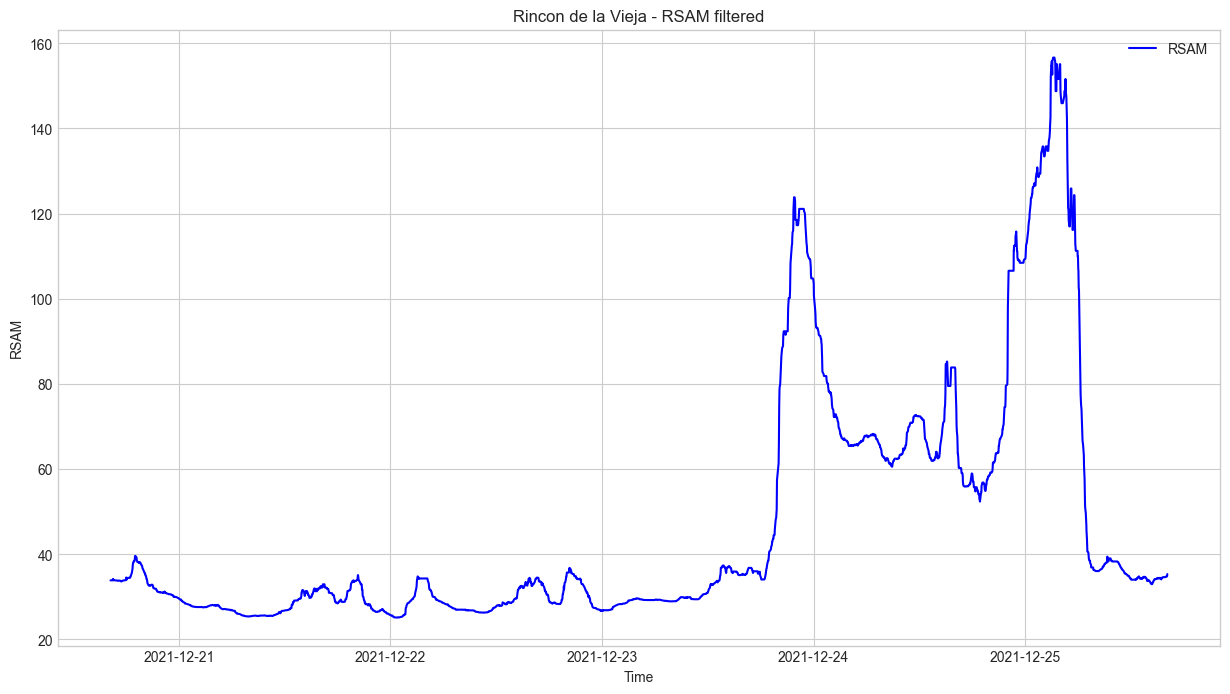

In [197]:
plt.style.use("seaborn-v0_8-whitegrid")
# Plot example of filtered (median) RSAM data for eruption window X=226
data = eruptions_windows_indices[226]
result = select_valid_lists(data)
print(f"number of valid lists of continuous data points for eruption 226: {len(result)}")
rsam_filtered = median_filter(result)
n = len(rsam_filtered)
dates  = []
plt.figure(figsize=(15,8))
for y in range(n):
    plt.subplot(n, 1, y+1)
    #plt.plot(range(len(rsam_filtered[i])+1, 1,-1 ), rsam_filtered[i], label='RSAM', color='blue')
    #plt.plot(range(1, len(rsam_filtered[i])+1), rsam_filtered[i], label='RSAM', color='blue')
    dates.append(result[y])
    plt.plot(dates[y], rsam_filtered[y], label='RSAM', color='blue')
    plt.title('Rincon de la Vieja - RSAM filtered')
    plt.xlabel('Time')
    plt.ylabel('RSAM')
    plt.legend()
#plt.tight_layout()
plt.show()


    

In [122]:
# Function to plot RSAM signal with peaks and troughs 
    
def plot_Rsam_Sig(plot, rsam_clean, dates_clean, high_peaks, h_results_full, h_prominences, low_peaks, l_results_full, l_prominences):
    if plot:
        for key in high_peaks.keys():
            # Plot
            plt.figure(figsize=(12, 4))
            plt.plot(dates_clean[key], rsam_clean[key], label='RSAM (filtered)')

            # Plot Highs
            if len(high_peaks[key]) > 0:
                plt.plot(dates_clean[key][high_peaks[key]], rsam_clean[key][high_peaks[key]], "x", color='red', label='Peaks')
                plt.hlines(h_results_full[key][1], dates_clean[key][h_results_full[key][2].astype(int)], dates_clean[key][h_results_full[key][3].astype(int)], color="C3")

                # Annotate Peak Prominence
                for i, peak_idx in enumerate(high_peaks[key]):
                    prominence = h_prominences[key][i]
                    peak_date = dates_clean[key][peak_idx]
                    peak_val = rsam_clean[key][peak_idx]
                    
                    # Draw line showing the prominence
                    plt.vlines(x=peak_date, ymin=peak_val - prominence, ymax=peak_val, color='orange', linestyle='--', alpha=0.7)
                    
                    # Add text label for the prominence
                    plt.text(peak_date, peak_val + (peak_val*0.05), f'Prominence: {prominence:.1f}', color='orange', ha='center')

            # Plot Lows
            if len(low_peaks[key]) > 0:
                # Plot markers at positive rsam_clean values (remove the negative sign)
                plt.plot(dates_clean[key][low_peaks[key]], rsam_clean[key][low_peaks[key]], "x", color='green', label='Troughs')
                
                # Height lines must be inverted back to positive for plotting
                # l_results[1] contains the height (y-value). Since we calculated on inverted data,
                # these y-values are negative. We multiply by -1 to plot them on the positive chart.
                plt.hlines(-l_results_full[key][1], dates_clean[key][l_results_full[key][2].astype(int)], dates_clean[key][l_results_full[key][3].astype(int)], color="C5")

                # Annotate Drop Depth
                for i, peak_idx in enumerate(low_peaks[key]):
                    depth = l_prominences[key][i]
                    trough_date = dates_clean[key][peak_idx]
                    trough_val = rsam_clean[key][peak_idx]
                    
                    # Draw line showing the drop magnitude
                    plt.vlines(x=trough_date, ymin=trough_val, ymax=trough_val + depth, color='purple', linestyle='--', alpha=0.7)
                    
                    # Add text label for the depth
                    plt.text(trough_date, trough_val - (trough_val*0.05), f'Drop: {depth:.1f}', color='purple', ha='center')

            plt.xlabel('Time')
            plt.ylabel('RSAM')
            plt.legend()
            plt.show()

In [131]:
# Function to extract peak and trough information from RSAM data

def extract_rsam_info(rsam_clean, rsam_inverted, h_selected, l_selected):
    high_peaks = {}
    high_peak_widths = {}
    h_prominences = {}
    high_peak_heights = {}

    low_trough = {}
    low_trough_widths = {}
    l_prominences = {}
    low_trough_heights = {}

    for (key, index) in h_selected:
        if key not in high_peaks:
            high_peaks[key] = []
            high_peak_widths[key] = []
            h_prominences[key] = []
            high_peak_heights[key] = []
        high_peaks[key].append(index)

        high_peak_widths[key] = signal.peak_widths(rsam_clean[key], high_peaks[key], rel_height=1.0)
        # Find the prominence of the high peaks
        h_prominences[key] = signal.peak_prominences(rsam_clean[key], high_peaks[key])[0]
        # Find the heights of the peaks
        high_peak_heights[key] = rsam_clean[key][high_peaks[key]]

        
    for (key, index) in l_selected:
        if key not in low_trough:
            low_trough[key] = []
            low_trough_widths[key] = []
            l_prominences[key] = []
            low_trough_heights[key] = []
        low_trough[key].append(index)

        low_trough_widths[key] = signal.peak_widths(rsam_inverted[key], low_trough[key], rel_height=1.0)
        # Find the depth of the drops
        l_prominences[key] = signal.peak_prominences(rsam_inverted[key], low_trough[key])[0]
        # Find the heights of the troughs (negative values)
        low_trough_heights[key] = rsam_clean[key][low_trough[key]]

    return high_peaks, high_peak_widths,h_prominences, high_peak_heights, low_trough,low_trough_widths,l_prominences, low_trough_heights

In [133]:
## Analyze RSAM data to find peaks and troughs

# Parameters for peak detection

DISTANCE_PEAKS = 360  # Minimum distance between peaks in number of samples (e.g., 360 samples = 6 hours if data is at 1 min intervals)
HEIGHT_THRESHOLD = 80

def analyze_and_plot_Rsam(rsam_signals, dates, plot= False):
    high_peaks_index = []
    low_trough_index = []
    high_peaks_values = []
    low_trough_values = []
    rsam_clean = {}
    rsam_inverted = {}
    dates_clean = {}

    
    for index, rsam_signal in enumerate(rsam_signals):

        # Remove NaNs
        mask = rsam_signal.notna().values
        rsam_clean[index] = rsam_signal.values[mask]
        dates_clean[index] = np.array(dates[index])[mask]

        # Create an inverted copy for minima detection
        rsam_inverted[index] = -rsam_clean[index]

        # Check if rsam_clean is empty
        if len(rsam_clean[index]) == 0:
            print("No valid RSAM data to analyze in this window.")
            continue
        else:
            # Find the peaks 
            peaks= signal.find_peaks(rsam_clean[index], distance=DISTANCE_PEAKS)[0]
            # Strore information per peak
            for peak in peaks:
                high_peaks_index.append((index, peak))
                high_peaks_values.append(rsam_clean[index][peak])

            # Find the troughs
            troughs = signal.find_peaks(rsam_inverted[index], distance=DISTANCE_PEAKS)[0]
            # Store information per trough
            for trough in troughs:
                low_trough_index.append((index, trough))
                low_trough_values.append(rsam_inverted[index][trough])

    # Stop if no peaks or troughs found
    if len(high_peaks_index) == 0 and len(low_trough_index) == 0:
        print("No peaks or troughs found in the RSAM data.")
        return {}, {}, {}, {}

    # Select 10% highest peaks end lowest troughs
    if len(high_peaks_values) > 0:
        h_p = np.percentile(high_peaks_values, HEIGHT_THRESHOLD)
        h_mask = np.array(high_peaks_values) >= h_p
    else:
        h_mask = [] # Empty mask if no peaks

    if len(low_trough_values) > 0:
        l_p = np.percentile(low_trough_values, HEIGHT_THRESHOLD)
        l_mask = np.array(low_trough_values) >= l_p
    else:
        l_mask = [] # Empty mask if no troughs

    h_selected = [(segment,index) for (segment, index), m in zip(high_peaks_index, h_mask) if m]
    l_selected = [(segment,index) for (segment, index), m in zip(low_trough_index, l_mask) if m]

    high_peaks, high_peak_widths, h_prominences,  high_peak_heights, low_troughs, low_trough_widths, l_prominences, low_trough_heights = extract_rsam_info(rsam_clean, rsam_inverted, h_selected, l_selected) 
        
    plot_Rsam_Sig(plot, rsam_clean, dates_clean, high_peaks, high_peak_widths, h_prominences, low_troughs, low_trough_widths, l_prominences)


    return high_peak_widths, h_prominences, high_peak_heights, low_trough_widths, l_prominences, low_trough_heights

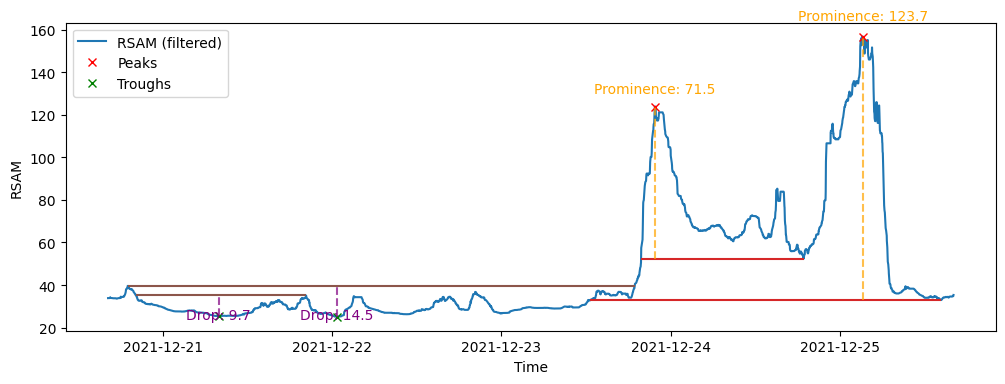

In [134]:
plt.style.use('default')
info = analyze_and_plot_Rsam(rsam_filtered, dates, True)

In [136]:
# Function to join all part data into a single array
def join_data(part_data):
    if len(part_data) > 0:
        join_data = np.concatenate(list(part_data.values()))
    else:
        join_data = np.array([])
    return join_data

In [ ]:
def extract_rsam_features_global(info):

    high_peak_widths, h_prominences,  high_peak_heights, low_trough_widths, l_prominences, low_trough_heights = info
    
    all_h_widths = join_data(high_peak_widths)
    all_l_widths = join_data(low_trough_widths)
    all_h_prominences = join_data(h_prominences)
    all_l_prominences = join_data(l_prominences)
    all_high_peak_heights = join_data(high_peak_heights)
    all_low_trough_heights = join_data(low_trough_heights)

    data = {}

    # Peaks data
    if len(all_h_prominences) > 0:
        data['Number of peaks'] = len(all_h_prominences)
        data['Avg Prominence'] = np.mean(all_h_prominences)
        data['Max Prominence'] = np.max(all_h_prominences)
        data['Std Prominence'] = np.std(all_h_prominences)
        data['Avg h Width'] = np.mean(all_h_widths[0])  # all_h_widths[0] contains the widths
        data['Max h Width'] = np.max(all_h_widths[0])
        data['Std h Width'] = np.std(all_h_widths[0])
        data['Avg RSAM peak'] = np.mean(all_high_peak_heights)
        data['Max RSAM peak'] = np.max(all_high_peak_heights)
        data['Std RSAM peak'] = np.std(all_high_peak_heights)
    else:
        data['Number of peaks'] = 0
        data['Avg Prominence'] = 0
        data['Max Prominence'] = 0
        data['Std Prominence'] = 0
        data['Avg h Width'] = 0
        data['Max h Width'] = 0
        data['Std h Width'] = 0
        data['Avg RSAM peak'] = 0
        data['Max RSAM peak'] = 0
        data['Std RSAM peak'] = 0

    # Troughs data
    if len(all_l_prominences) > 0:
        data['Number of drops'] = len(all_l_prominences)
        data['Avg Drop Depth'] = np.mean(all_l_prominences)
        data['Max Drop Depth'] = np.max(all_l_prominences)
        data['Std Drop Depth'] = np.std(all_l_prominences)
        data['Avg l Width'] = np.mean(all_l_widths[0])  # all_l_widths[0] contains the widths
        data['Max l Width'] = np.max(all_l_widths[0])
        data['Std l Width'] = np.std(all_l_widths[0])
        data['Avg RSAM drop'] = np.mean(all_low_trough_heights)
        data['Max RSAM drop'] = np.min(all_low_trough_heights)
        data['Std RSAM drop'] = np.std(all_low_trough_heights)
    else:
        data['Number of drops'] = 0
        data['Avg Drop Depth'] = 0
        data['Max Drop Depth'] = 0
        data['Std Drop Depth'] = 0
        data['Avg l Width'] = 0
        data['Max l Width'] = 0
        data['Std l Width'] = 0
        data['Avg RSAM drop'] = 0
        data['Max RSAM drop'] = 0
        data['Std RSAM drop'] = 0
    features = pd.DataFrame([data])
    
    return features


In [168]:
# Separate unused indices into valid lists
groups = select_valid_lists(unused_indices)
print(f"Number of valid unused data segments: {len(groups)}")

for y in range(len(groups)):
    print(f"length of segment n°{y} : {len(groups[y])}")

Number of valid unused data segments: 280
length of segment n°0 : 3373
length of segment n°1 : 611
length of segment n°2 : 784
length of segment n°3 : 987
length of segment n°4 : 845
length of segment n°5 : 10981
length of segment n°6 : 3981
length of segment n°7 : 915
length of segment n°8 : 823
length of segment n°9 : 9636
length of segment n°10 : 40
length of segment n°11 : 1813
length of segment n°12 : 474
length of segment n°13 : 34
length of segment n°14 : 99
length of segment n°15 : 18949
length of segment n°16 : 17063
length of segment n°17 : 440
length of segment n°18 : 4509
length of segment n°19 : 33
length of segment n°20 : 6521
length of segment n°21 : 1485
length of segment n°22 : 30113
length of segment n°23 : 141
length of segment n°24 : 42
length of segment n°25 : 460
length of segment n°26 : 419
length of segment n°27 : 910
length of segment n°28 : 399
length of segment n°29 : 126
length of segment n°30 : 203
length of segment n°31 : 267
length of segment n°32 : 629
l

Some no eruptions windos are pretty small. If bad results are obtained, we can try to select only the no-eruption windows with a minimum size.

[Timestamp('2019-01-01 00:01:00'), Timestamp('2019-01-01 00:02:00'), Timestamp('2019-01-01 00:03:00'), Timestamp('2019-01-01 00:04:00'), Timestamp('2019-01-01 00:05:00'), Timestamp('2019-01-01 00:06:00'), Timestamp('2019-01-01 00:07:00'), Timestamp('2019-01-01 00:08:00'), Timestamp('2019-01-01 00:09:00'), Timestamp('2019-01-01 00:10:00'), Timestamp('2019-01-01 00:11:00'), Timestamp('2019-01-01 00:12:00'), Timestamp('2019-01-01 00:13:00'), Timestamp('2019-01-01 00:14:00'), Timestamp('2019-01-01 00:15:00'), Timestamp('2019-01-01 00:16:00'), Timestamp('2019-01-01 00:17:00'), Timestamp('2019-01-01 00:18:00'), Timestamp('2019-01-01 00:19:00'), Timestamp('2019-01-01 00:20:00'), Timestamp('2019-01-01 00:21:00'), Timestamp('2019-01-01 00:22:00'), Timestamp('2019-01-01 00:23:00'), Timestamp('2019-01-01 00:24:00'), Timestamp('2019-01-01 00:25:00'), Timestamp('2019-01-01 00:26:00'), Timestamp('2019-01-01 00:27:00'), Timestamp('2019-01-01 00:28:00'), Timestamp('2019-01-01 00:29:00'), Timestamp('20

TypeError: unhashable type: 'numpy.ndarray'

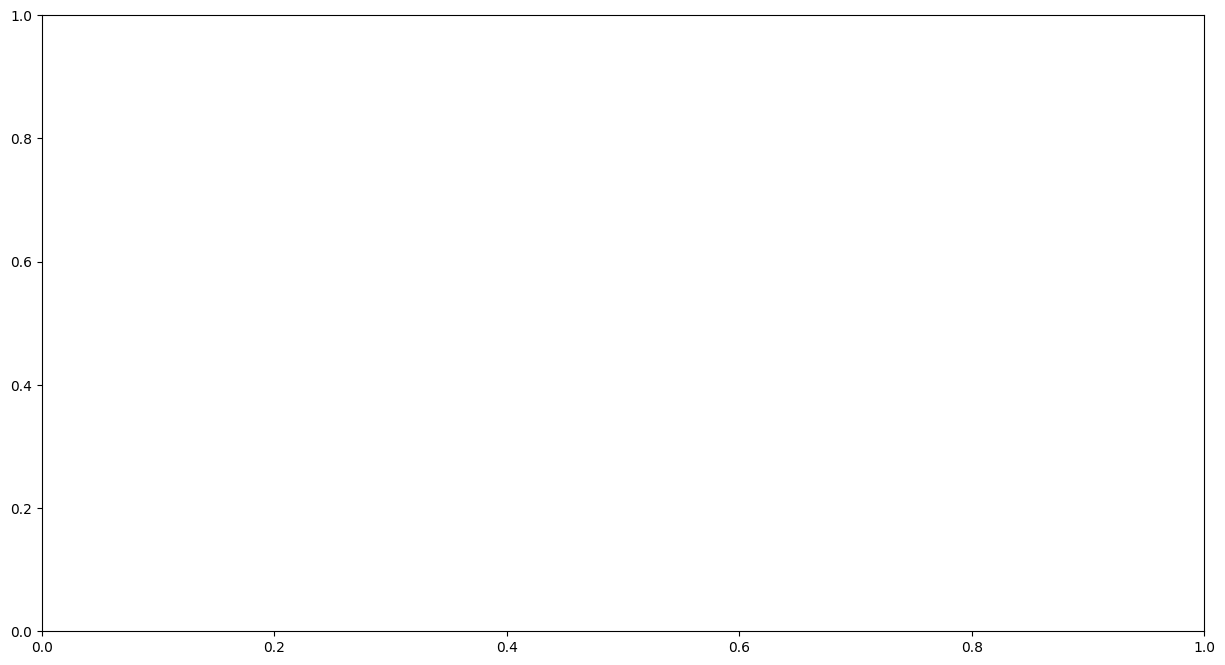

In [146]:
## (!Launch) Plot the no-eruption windows RSAM data filtered
no_eruptions_dates = []
for i in range(10):  # Limit to first 10 windows for brevity
    rsam_filtered = median_filter(no_eruptions_windows[i])
    n = len(rsam_filtered)
    dates  = []
    plt.figure(figsize=(15,8))
    for y in range(n):
        plt.subplot(n, 1, y+1)
        dates.append(get_window_dates(no_eruptions_windows[i][y]))
        plt.plot(dates[y], rsam_filtered[y], label='RSAM', color='blue')
        plt.title('Rincon de la Vieja - RSAM filtered')
        plt.xlabel('Time')
        plt.ylabel('RSAM')
        plt.legend()
    no_eruptions_dates.append(dates[0]) # Only one window per no-eruption window
plt.tight_layout()
plt.show()


In [ ]:
# For balanced dataset, we take the same number of no-eruption windows as head eruption windows 
random.seed(42)
selected_no_eruption_windows = random.sample(no_eruptions_windows, len(head_chains))
print(f"Selected {len(selected_no_eruption_windows)} no-eruption windows for balanced dataset.")

In [ ]:
head_chains

##### Features Extraction Function

In [ ]:
def get_rsam_features_per_eruption(windows_indices, no_eruptions_windows=False, head=False, plot= False):
    all_features = []
    for i in range(1, len(windows_indices) + 1):
        if (i%100)==0:
            print(f"Processing eruption {i} / {len(windows_indices)}") 
        if head==True:
            data = windows_indices[head_chains[i-1]+1]
            
            result = select_valid_lists(data)
            rsam_filtered = median_filter(result)
        elif no_eruptions_windows==False:
            data = windows_indices[i]
            result = select_valid_lists(data)
            rsam_filtered = median_filter(result)
        else:
            result = windows_indices[i-1]
            rsam_filtered = median_filter(result)
        dates = []
        for j in range(len(rsam_filtered)):
            dates.append(get_window_dates(result[j]))
        info = analyze_and_plot_Rsam(rsam_filtered, dates, plot)
        features = extract_rsam_features_global(info)
        all_features.append(features)
    all_features_df = pd.concat(all_features, ignore_index=True)
    return all_features_df

#Rsam_eruption_features_df = get_rsam_features_per_eruption(eruptions_windows_indices, plot= False)
head_eruptions_windows_indices = {erup_id+1: eruptions_windows_indices[erup_id+1] for erup_id in head_chains}
Rsam_head_eruption_features_df = get_rsam_features_per_eruption(head_eruptions_windows_indices, head=True, plot= False)
Rsam_no_eruption_features_df = get_rsam_features_per_eruption(no_eruptions_windows, no_eruptions_windows=True ,plot= False)
Rsam_no_eruption_shorten_features_df = get_rsam_features_per_eruption(selected_no_eruption_windows, no_eruptions_windows=True ,plot= False)
# Store the features to a CSV file
#Rsam_eruption_features_df.to_csv("MSc_Bryan_Rincon/Rsam_features_per_eruption.csv", index=False)
Rsam_no_eruption_features_df.to_csv("MSc_Bryan_Rincon/Rsam_no_eruption_features.csv", index=False)
Rsam_head_eruption_features_df.to_csv("MSc_Bryan_Rincon/Rsam_features_per_head_eruption.csv", index=False)
Rsam_no_eruption_shorten_features_df.to_csv("MSc_Bryan_Rincon/Rsam_no_eruption_shorten_features.csv", index=False)

In [ ]:
# Read the eruption features from CSV file
# Rsam_features_df = pd.read_csv("MSc_Bryan_Rincon/Rsam_features_per_head_eruption.csv")
# Rsam_features_df['Type'] = 1
# Rsam_features_df.head()

In [ ]:
# # Read the eruption features from CSV file
Rsam_features_df = pd.read_csv("MSc_Bryan_Rincon/Rsam_features_per_eruption.csv")
Rsam_features_df['Type'] = 1  # 1 for eruption windows
Rsam_features_df.head()

In [ ]:
# Read the no-eruption features from CSV file
Rsam_no_eruption_features_df = pd.read_csv("MSc_Bryan_Rincon/Rsam_no_eruption_features.csv")
Rsam_no_eruption_features_df['Type'] = 0  # 0 for no-eruption windows
Rsam_no_eruption_features_df['Lahares'] = '0'  # No Lahares in no-eruption windows
Rsam_no_eruption_features_df['t1'] = pd.NaT  # Initialize t1 column with NaT
for i, date in  enumerate(no_eruptions_dates):
    Rsam_no_eruption_features_df.at[i, 't1'] = date[-1]  # Assign a representative date for the no-eruption window
Rsam_no_eruption_features_df = add_temporal_features(Rsam_no_eruption_features_df)
# Rsam_no_eruption_features_df['t2'] = pd.NaT  # Initialize t2 column with NaT
Rsam_no_eruption_features_df.head() 

In [ ]:
# Remove column 't1'
no_eruption_columns = Rsam_no_eruption_features_df.columns.tolist()
no_eruption_columns.remove('t1')


In [ ]:
# !Merge the RSAM features of eruptions with the VRBA eruptions DataFrame CHANGE IF HEAD

VRBA_features_df = VRBA_df.merge(Rsam_features_df, left_index=True, right_index=True)

# IF HEAD CHAINS
# vrba_subset = VRBA_df.loc[head_chains]
# Rsam_features_df.index = vrba_subset.index
# VRBA_features_df = vrba_subset.merge(Rsam_features_df, left_index=True, right_index=True)

# Scale the features
scaler = StandardScaler()
features_columns = ['Number of peaks','Avg Prominence', 'Max Prominence', 'Std Prominence',
                    'Avg h Width', 'Max h Width', 'Std h Width', 'Number of drops', 'Avg Drop Depth', 'Max Drop Depth', 'Std Drop Depth', 'Avg l Width', 'Max l Width', 'Std l Width'   ]
VRBA_features_df[features_columns] = scaler.fit_transform(VRBA_features_df[features_columns])

VRBA_features_df.head()

In [ ]:
# Add the RSAM features of no-eruptions with the VRBA eruptions DataFrame

VRBA_features_df = pd.concat(
    [VRBA_features_df, Rsam_no_eruption_features_df[no_eruption_columns]],
    ignore_index=True
)


VRBA_features_df.head()

In [ ]:
# Scale the features
scaler = StandardScaler()
features_columns = ['Number of peaks','Avg Prominence', 'Max Prominence', 'Std Prominence',
                    'Avg h Width', 'Max h Width', 'Std h Width', 'Number of drops', 'Avg Drop Depth', 'Max Drop Depth', 'Std Drop Depth', 'Avg l Width', 'Max l Width', 'Std l Width']
VRBA_features_df[features_columns] = scaler.fit_transform(VRBA_features_df[features_columns])

VRBA_features_df.head()

In [ ]:
# Lahares to int + mark Type = -1 for eruptions with Lahares
VRBA_features_df['Lahares'] = VRBA_features_df['Lahares'].astype(int)
VRBA_features_df.loc[VRBA_features_df['Lahares'] == 1, 'Type'] = -1
print(VRBA_features_df['Type'][VRBA_features_df['Type'] == -1]) 
all_features_columns = VRBA_features_df.columns.tolist()
all_features_columns.remove('Lahares')

In [ ]:
Eruptions_df = VRBA_features_df[all_features_columns].copy()
plt.style.use('bmh')
fast_eda(Eruptions_df, target= 'Type')

In [ ]:
TSNE_FEATURES = list(Eruptions_df.drop(columns=['Type','amplitude_max','amplitude_rms','amplitude_p2p','energy', 'season', 'month', 'Time of the Day', 'magnitude', 'duration']).columns)
print(TSNE_FEATURES)
train_tsne = Eruptions_df[TSNE_FEATURES].values
y_tsne = Eruptions_df['Type'].values

In [ ]:

%%time
plot_tsne = TSNE().fit(train_tsne)

In [ ]:

plt.style.use("dark_background")
plt.figure(figsize = (12, 10))

marker_sizes = [15 if hue == 1 else 3 for hue in y_tsne]

ax = sns.scatterplot(x = plot_tsne[:,0], y = plot_tsne[:,1], s = marker_sizes, hue = y_tsne,
                     linewidth = 0, palette = ["#ff3300", "#ffffff", "#33cc33"],
                     legend=False)
plt.grid(False)
plt.title(f"TSNE plot w/ target = Lahares | train data")
plt.show()

#### Geophysical and Seismic Data Features Extraction

In [ ]:
Rincon_df.columns

In [ ]:
print(sei_geo_eruptions_windows_indices[1])
print(sei_geo_eruptions_windows_dates[1])

Rincon_df.describe() 

In [ ]:
Rincon_df.info()

##### No eruption Window Features Extraction

In [104]:
unused_indices = get_unused_data_indices(Rincon_df, sei_geo_eruptions_windows_indices)

no_geoseism_eruptions_windows = create_no_eruption_windows([unused_indices], WINDOW_SIZE, measure_frequency=pd.Timedelta(days=1),apply_median_check=False)

NameError: name 'get_unused_data_indices' is not defined

In [ ]:
# Function to extract geoseismic features from a given window of data
def extract_geoseismic_features(window_data_df):
    
    data = {}
    # List of seismic event types to process
    event_types = ['VT', 'LP', 'Tcorto', 'tornillo']
    
    for event in event_types:
        # Get the series for the specific event type
        series = window_data_df[event]
        
        # Total accumulation of events
        data[f"Sum_{event}"] = series.sum(skipna=True)
        
        # Current state of the volcano (ignoring missing data)
        # Drop NaNs and take the last one. If all are NaN, default to 0.
        valid_values = series.dropna()
        data[f"Last_{event}"] = valid_values.iloc[-1] if not valid_values.empty else 0
        
        # Peak intensity 
        data[f"Max_{event}"] = series.max(skipna=True)
        

    return data  

In [ ]:
def extract_geoseismic_features_per_event(windows_indices):
    all_features = []
    for i in range(1, len(windows_indices) + 1):
        if (i%100)==0:
            print(f"Processing event {i} / {len(windows_indices)}") 
        data = windows_indices[i]
        window_data_df = Rincon_df.loc[data]
        features = extract_geoseismic_features(window_data_df)
        all_features.append(features)
    all_features_df = pd.DataFrame(all_features)
    return all_features_df

In [ ]:
geoseis_eruption_features_df = extract_geoseismic_features_per_event(sei_geo_eruptions_windows_indices)
geoseis_eruption_features_df.head()

Lets try to see if clusters can be identified out of the features available at the team.

In [ ]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=3, min_samples=161)

Erup_cluster_df = Eruptions_df.copy()
clusters = dbscan.fit_predict(Erup_cluster_df)

cluster_labels = dbscan.labels_

Erup_cluster_df['Cluster'] = cluster_labels

#Erup_cluster_df.head()

cluster_stats_lahares = Erup_cluster_df.groupby('Cluster')['Lahares'].agg(['count', 'sum'])
cluster_stats_lahares['Lahar Percentage'] = (cluster_stats_lahares['sum'] / cluster_stats_lahares['count']) * 100
print(cluster_stats_lahares)


In [ ]:
cluster_stats = (Erup_cluster_df.groupby('Cluster').mean())

cluster_stats


In [ ]:
fast_eda(Erup_cluster_df, target= 'Lahares')